First need to load the data in.

In [1]:
from pathlib import Path
import sys

from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "analyses" else Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data.loading import DEFAULT_CSV_PATH, URL, download_spf_data, save_csv

# --- Read directly from the web ---
df = download_spf_data(URL)

# --- Optional: inspect columns ---
print(df.columns)
print(df.head())

# --- Save as CSV ---
csv_path = save_csv(df, DEFAULT_CSV_PATH)

print(f"CSV saved as {csv_path}")


Index(['YEAR', 'QUARTER', 'ID', 'INDUSTRY', 'CPI1', 'CPI2', 'CPI3', 'CPI4',
       'CPI5', 'CPI6', 'CPIA', 'CPIB', 'CPIC'],
      dtype='str')
   YEAR  QUARTER  ID  INDUSTRY  CPI1  CPI2  CPI3  CPI4  CPI5  CPI6  CPIA  \
0  1968        4   1       NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   
1  1968        4   2       NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   
2  1968        4   3       NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   
3  1968        4   4       NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   
4  1968        4   5       NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   

   CPIB  CPIC  
0   NaN   NaN  
1   NaN   NaN  
2   NaN   NaN  
3   NaN   NaN  
4   NaN   NaN  
CSV saved as /home/clayt/Ensemble-Forecasting/data/SPF_Individual_CPI.csv


/home/clayt/miniconda3/envs/ensemble/lib/python3.11/site-packages/openpyxl/worksheet/header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")


## Exploratory Data Analysis

This section inspects missingness, coverage over time, and how consistently individual forecasters report.


In [2]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "analyses" else Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data.cleaning import (
    average_forecasts_by_period,
    long_forecast_frame,
    missingness_by_horizon,
    prepare_spf_data,
)
from src.data.loading import DEFAULT_CSV_PATH, URL, load_or_download_csv
from src.data.plots import (
    analyze_optimal_reporting_windows,
    plot_average_forecasts_over_time,
    plot_dispersion_scatter,
    plot_missingness_bar,
    plot_reporting_forecasters_over_time,
    plot_reporting_waterfall,
    summarize_and_plot_reporting_consistency,
)

data_path = DEFAULT_CSV_PATH
df_raw = load_or_download_csv(data_path, URL)
df, forecast_cols = prepare_spf_data(df_raw)

df


,YEAR,QUARTER,ID,INDUSTRY,CPI1,CPI2,CPI3,CPI4,CPI5,CPI6,CPIA,CPIB,CPIC,period
0,1981,3,4,NaN,9.1,8.9000,8.0000,7.6000,7.1000,6.9000,10.1000,7.9000,NaN,1981-09-30
1,1981,3,5,NaN,7.5,9.2000,8.2000,7.3000,7.6000,8.0000,4.9000,7.9000,NaN,1981-09-30
2,1981,3,16,NaN,7.5,9.2000,7.2000,6.5000,6.5000,6.5000,8.7000,6.5000,NaN,1981-09-30
3,1981,3,18,NaN,7.2,9.2000,6.9000,7.5000,8.2000,9.6000,7.4000,8.5000,NaN,1981-09-30
4,1981,3,19,NaN,7.5,11.2000,7.0000,6.5000,6.9000,6.2000,10.1000,7.2000,NaN,1981-09-30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6149,2025,4,602,1.0,3.1,3.2018,3.2514,2.6061,2.4334,2.2889,2.9477,2.6443,2.1828,2025-12-31
6150,2025,4,603,2.0,3.1,3.1381,2.4850,2.1465,2.0544,2.0792,2.9064,2.1911,1.9836,2025-12-31
6151,2025,4,607,2.0,3.1,2.9000,2.6000,2.4000,2.6000,2.7000,2.8500,2.5750,2.4000,2025-12-31
6152,2025,4,608,2.0,3.1,3.2000,3.1000,3.0000,2.9000,2.8000,2.9200,2.9500,2.8000,2025-12-31


In [3]:
# Missingness by horizon
missing_rate = missingness_by_horizon(df, forecast_cols)
missing_rate


CPIC    0.592460
CPIB    0.069061
CPI6    0.027299
CPIA    0.017712
CPI5    0.005850
CPI2    0.002437
CPI4    0.002112
CPI3    0.002112
CPI1    0.000000
dtype: float64

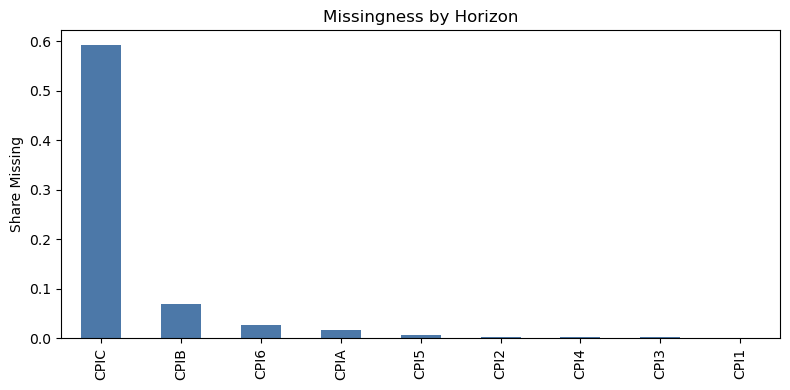

In [4]:
plot_missingness_bar(missing_rate)


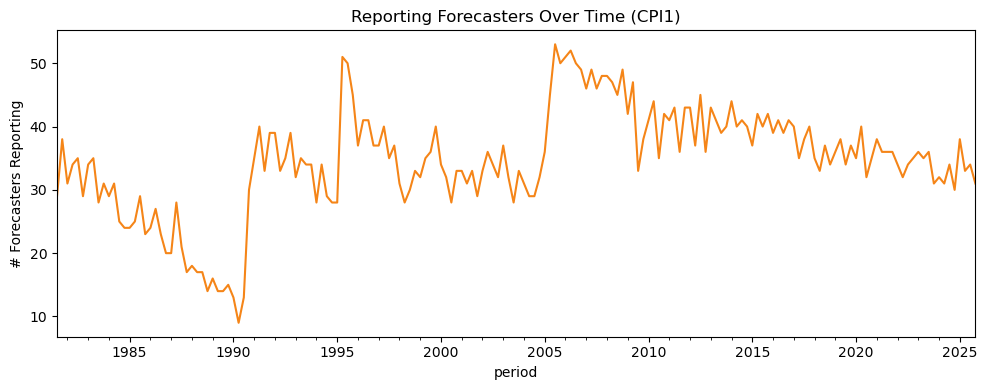

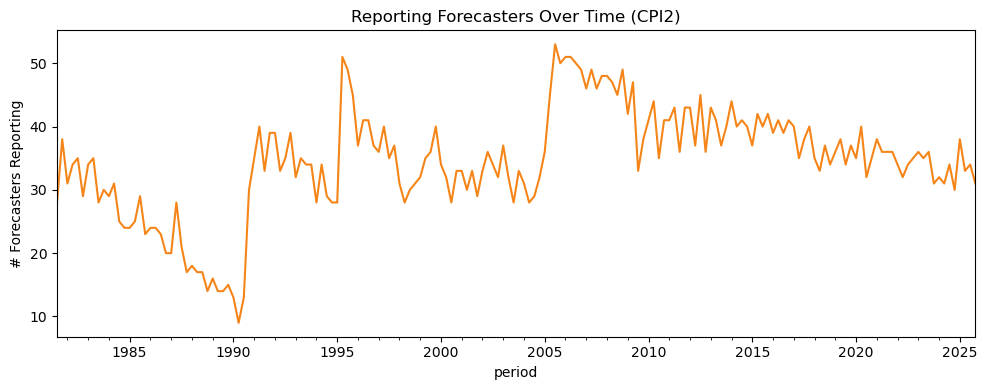

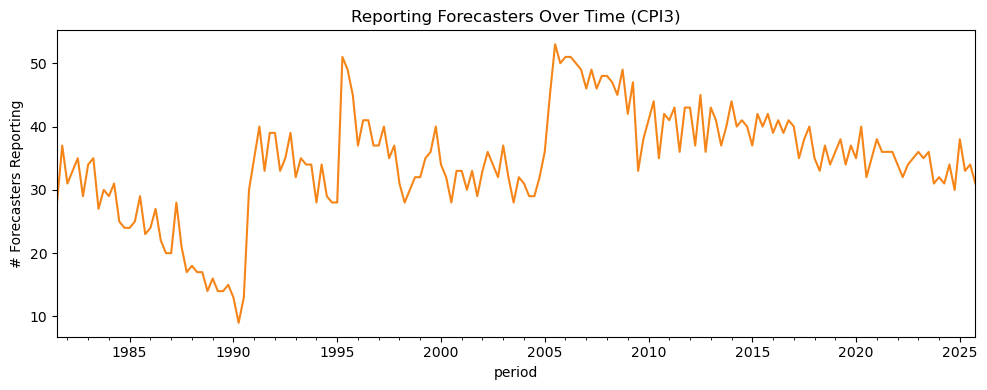

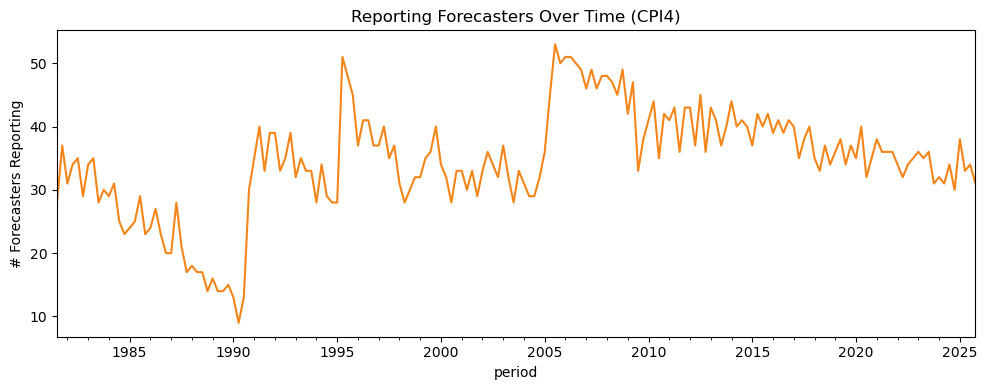

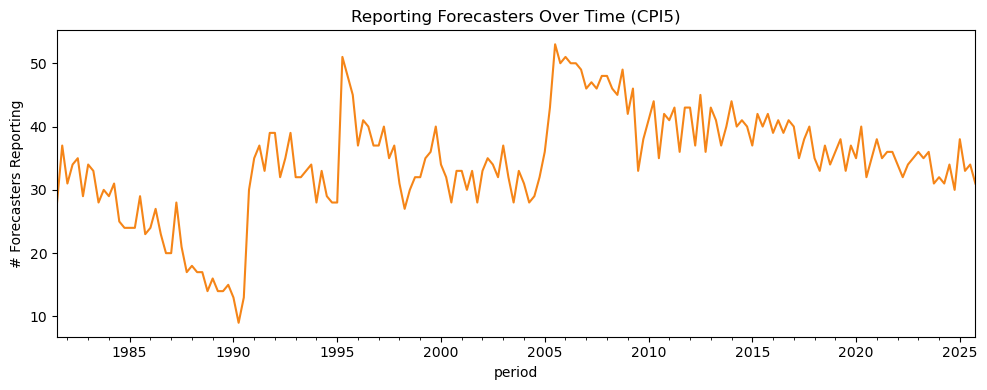

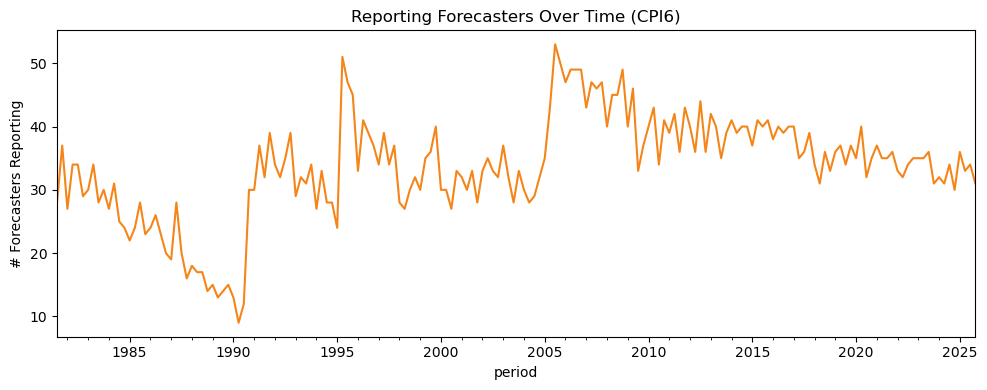

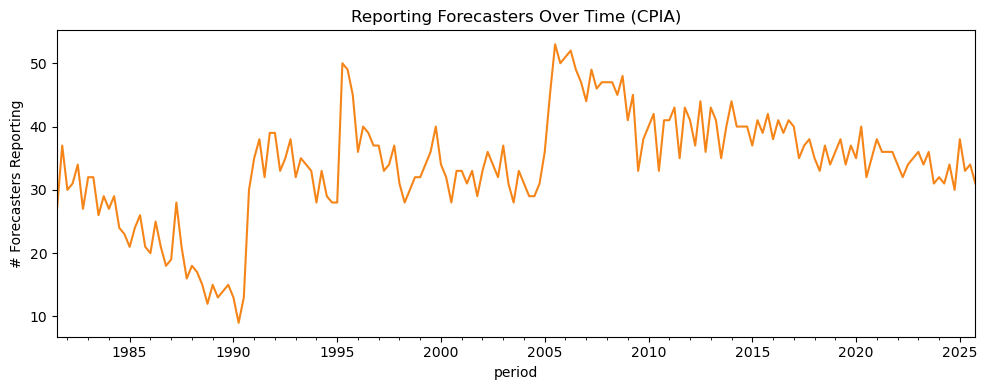

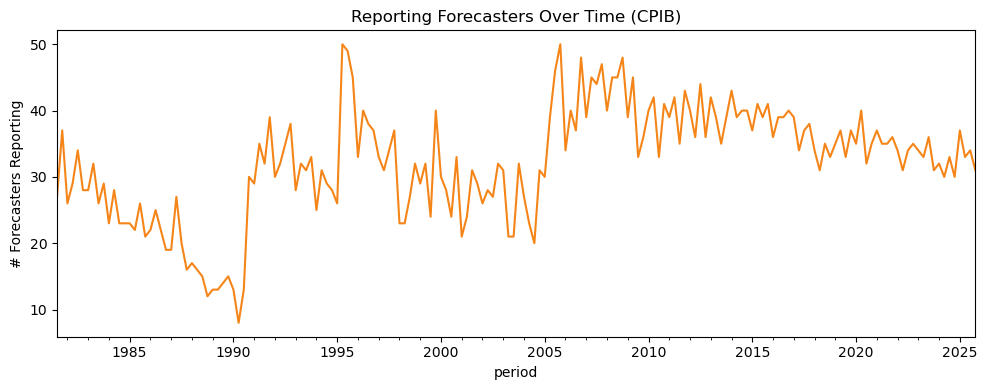

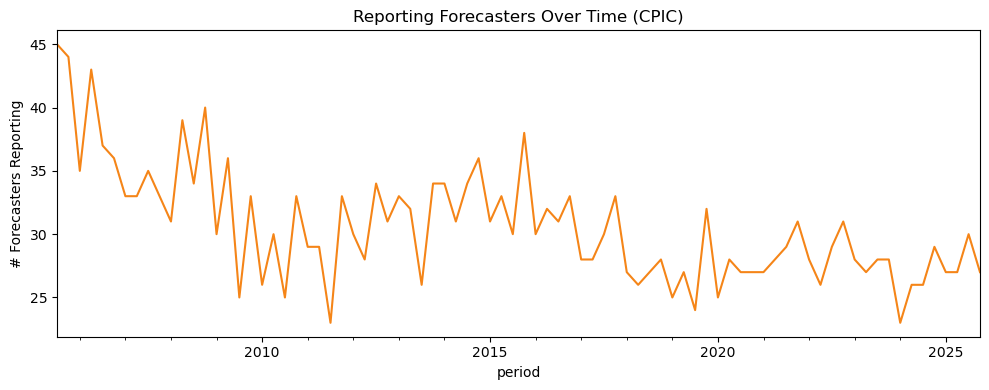

In [5]:
# Count of forecasters reporting per quarter, by horizon
plot_reporting_forecasters_over_time(df, forecast_cols)


Horizon: CPI1
  Total periods: 178
  Forecasters with 100% reporting: 0
  Forecasters with >=90% reporting: 0
  Forecasters with >=75% reporting: 0


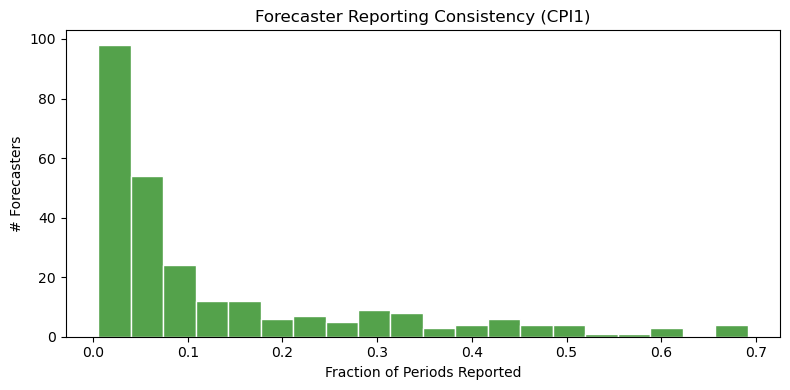

,report_fraction,report_count
ID,,
421,0.691011,123
433,0.691011,123
426,0.679775,121
411,0.668539,119
428,0.595506,106
463,0.595506,106
484,0.595506,106
510,0.578652,103
518,0.528090,94



Horizon: CPI2
  Total periods: 178
  Forecasters with 100% reporting: 0
  Forecasters with >=90% reporting: 0
  Forecasters with >=75% reporting: 0


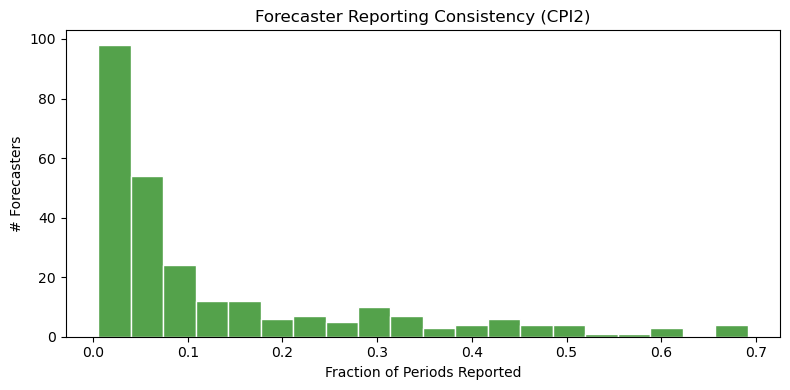

,report_fraction,report_count
ID,,
421,0.691011,123
433,0.691011,123
426,0.679775,121
411,0.668539,119
484,0.595506,106
463,0.595506,106
428,0.589888,105
510,0.573034,102
518,0.528090,94



Horizon: CPI3
  Total periods: 178
  Forecasters with 100% reporting: 0
  Forecasters with >=90% reporting: 0
  Forecasters with >=75% reporting: 0


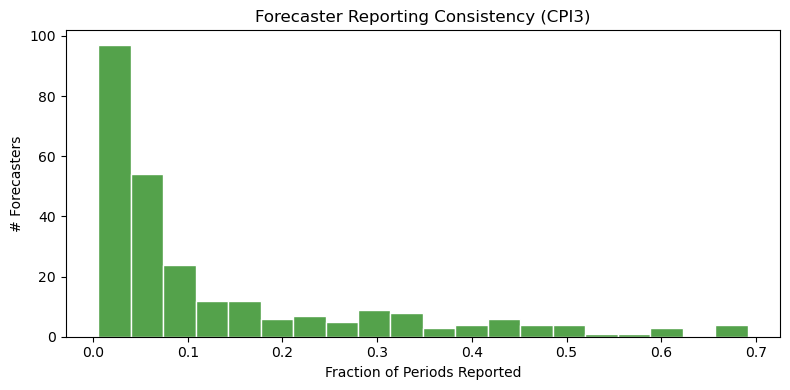

,report_fraction,report_count
ID,,
421,0.691011,123
433,0.691011,123
426,0.679775,121
411,0.668539,119
463,0.595506,106
484,0.595506,106
428,0.589888,105
510,0.573034,102
518,0.528090,94



Horizon: CPI4
  Total periods: 178
  Forecasters with 100% reporting: 0
  Forecasters with >=90% reporting: 0
  Forecasters with >=75% reporting: 0


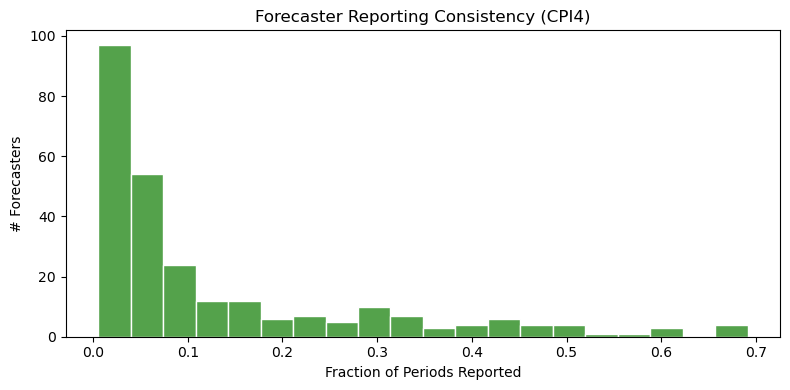

,report_fraction,report_count
ID,,
421,0.691011,123
433,0.691011,123
426,0.679775,121
411,0.668539,119
463,0.595506,106
484,0.595506,106
428,0.589888,105
510,0.573034,102
518,0.528090,94



Horizon: CPI5
  Total periods: 178
  Forecasters with 100% reporting: 0
  Forecasters with >=90% reporting: 0
  Forecasters with >=75% reporting: 0


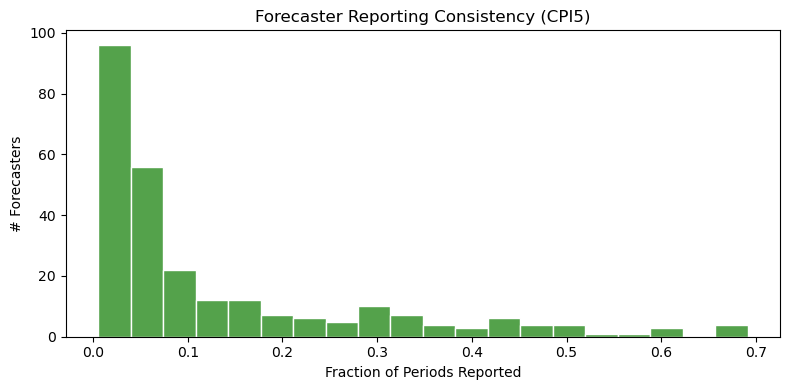

,report_fraction,report_count
ID,,
433,0.691011,123
421,0.691011,123
426,0.679775,121
411,0.668539,119
463,0.595506,106
484,0.595506,106
428,0.589888,105
510,0.573034,102
518,0.528090,94



Horizon: CPI6
  Total periods: 178
  Forecasters with 100% reporting: 0
  Forecasters with >=90% reporting: 0
  Forecasters with >=75% reporting: 0


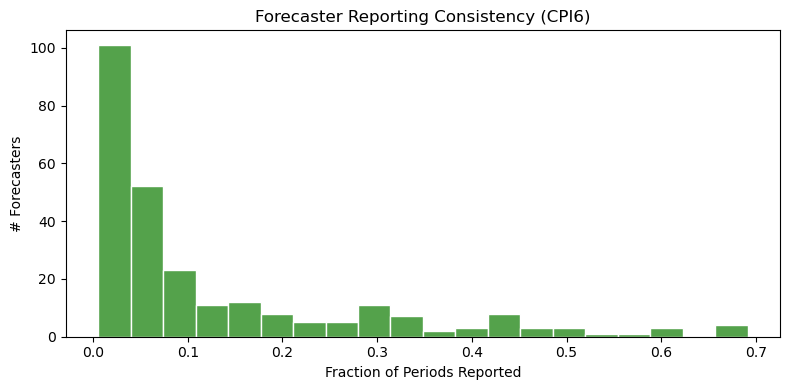

,report_fraction,report_count
ID,,
433,0.691011,123
421,0.691011,123
426,0.679775,121
411,0.668539,119
463,0.595506,106
428,0.589888,105
484,0.589888,105
510,0.573034,102
518,0.528090,94



Horizon: CPIA
  Total periods: 178
  Forecasters with 100% reporting: 0
  Forecasters with >=90% reporting: 0
  Forecasters with >=75% reporting: 0


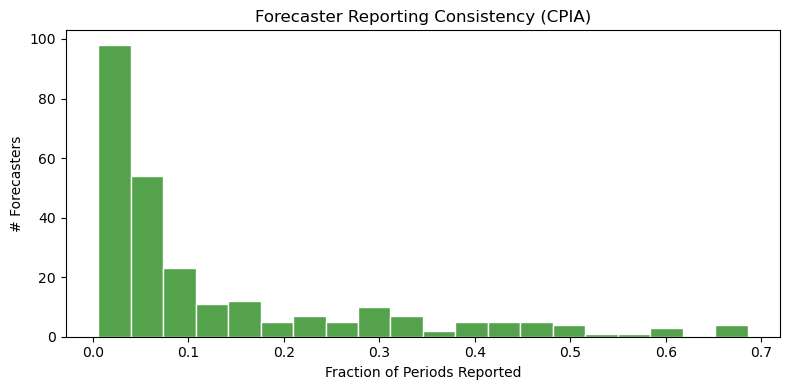

,report_fraction,report_count
ID,,
433,0.685393,122
421,0.685393,122
426,0.679775,121
411,0.662921,118
463,0.595506,106
484,0.589888,105
428,0.584270,104
510,0.578652,103
518,0.528090,94



Horizon: CPIB
  Total periods: 178
  Forecasters with 100% reporting: 0
  Forecasters with >=90% reporting: 0
  Forecasters with >=75% reporting: 0


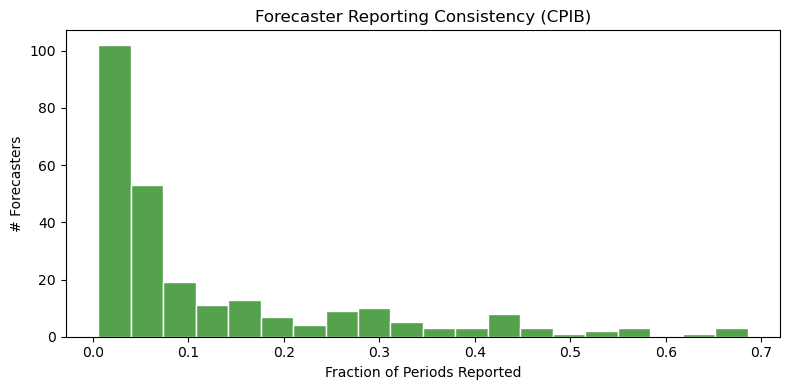

,report_fraction,report_count
ID,,
433,0.685393,122
426,0.662921,118
421,0.657303,117
411,0.646067,115
463,0.573034,102
428,0.561798,100
484,0.556180,99
510,0.533708,95
518,0.522472,93



Horizon: CPIC
  Total periods: 178
  Forecasters with 100% reporting: 0
  Forecasters with >=90% reporting: 0
  Forecasters with >=75% reporting: 0


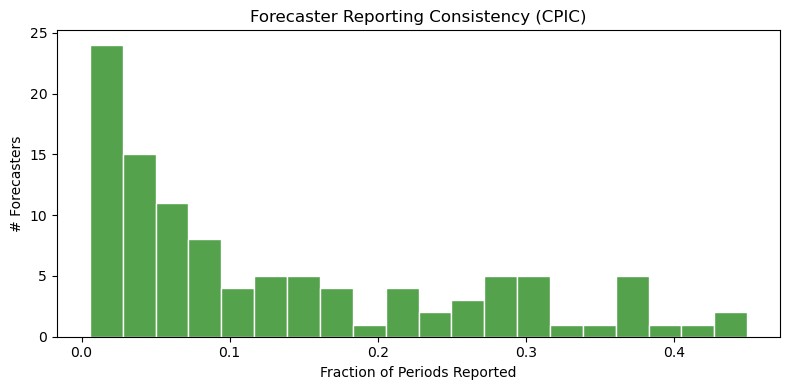

,report_fraction,report_count
ID,,
510,0.449438,80
518,0.443820,79
535,0.421348,75
411,0.387640,69
484,0.382022,68
504,0.370787,66
433,0.370787,66
463,0.370787,66
421,0.365169,65


In [6]:
# Consistency: fraction of periods in which each forecaster reports, by horizon
summarize_and_plot_reporting_consistency(df, forecast_cols, display_fn=display)


Horizon: CPI1
  Optimal window (max fully reporting forecasters):
    Window: 2014-06-30 00:00:00 to 2022-09-30 00:00:00 (len=34 quarters)
    Fully reporting forecasters: 12
    IDs (n=12): [433, 504, 510, 518, 546, 549, 555, 563, 568, 570, 572, 574]


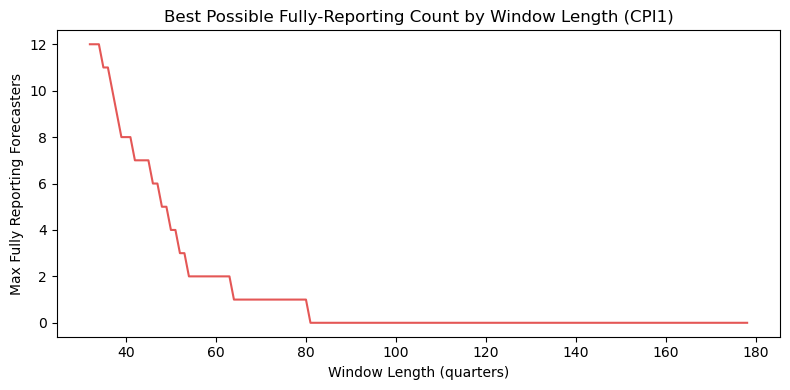


Horizon: CPI2
  Optimal window (max fully reporting forecasters):
    Window: 2014-06-30 00:00:00 to 2022-09-30 00:00:00 (len=34 quarters)
    Fully reporting forecasters: 12
    IDs (n=12): [433, 504, 510, 518, 546, 549, 555, 563, 568, 570, 572, 574]


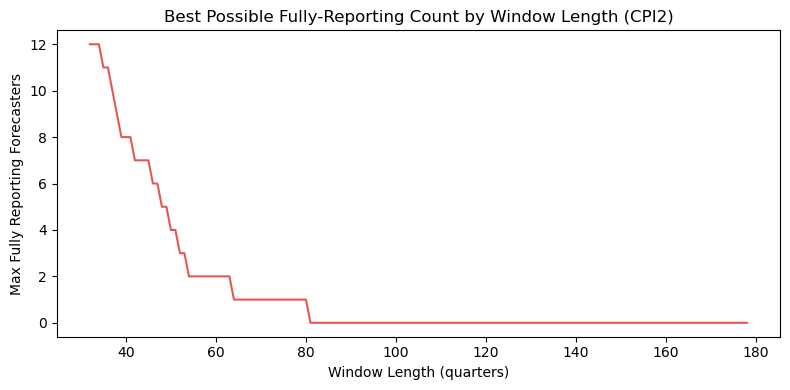


Horizon: CPI3
  Optimal window (max fully reporting forecasters):
    Window: 2014-06-30 00:00:00 to 2022-09-30 00:00:00 (len=34 quarters)
    Fully reporting forecasters: 12
    IDs (n=12): [433, 504, 510, 518, 546, 549, 555, 563, 568, 570, 572, 574]


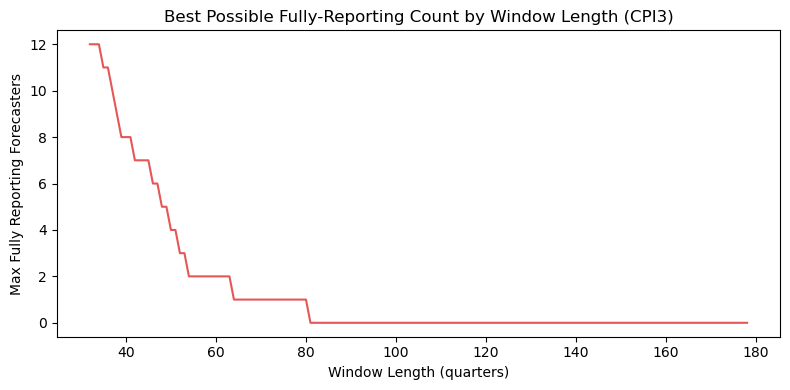


Horizon: CPI4
  Optimal window (max fully reporting forecasters):
    Window: 2014-06-30 00:00:00 to 2022-09-30 00:00:00 (len=34 quarters)
    Fully reporting forecasters: 12
    IDs (n=12): [433, 504, 510, 518, 546, 549, 555, 563, 568, 570, 572, 574]


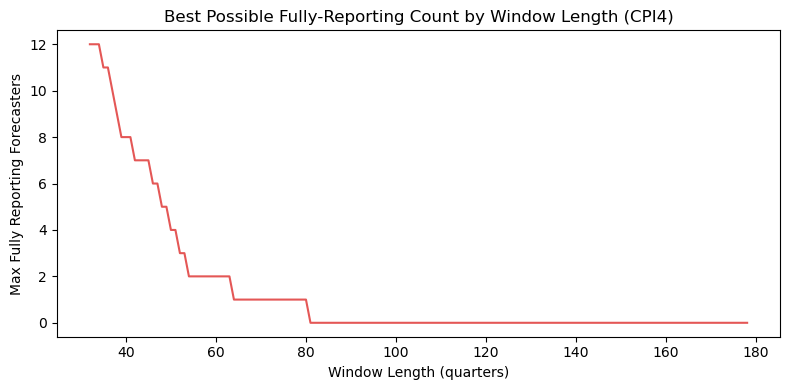


Horizon: CPI5
  Optimal window (max fully reporting forecasters):
    Window: 2014-06-30 00:00:00 to 2022-09-30 00:00:00 (len=34 quarters)
    Fully reporting forecasters: 11
    IDs (n=11): [433, 504, 510, 518, 546, 549, 563, 568, 570, 572, 574]


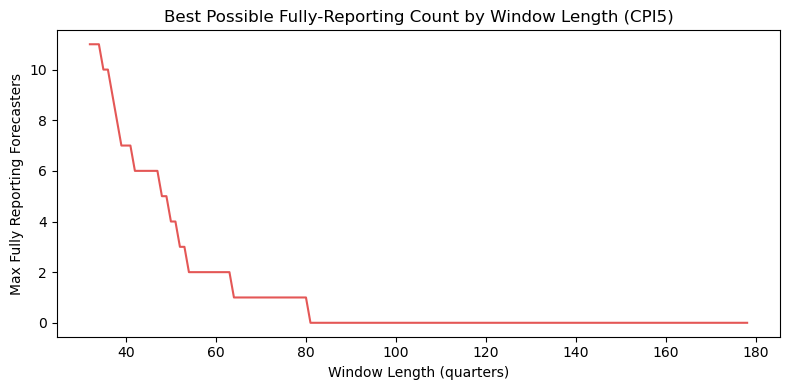


Horizon: CPI6
  Optimal window (max fully reporting forecasters):
    Window: 2014-06-30 00:00:00 to 2022-09-30 00:00:00 (len=34 quarters)
    Fully reporting forecasters: 11
    IDs (n=11): [433, 504, 510, 518, 546, 549, 555, 563, 568, 570, 572]


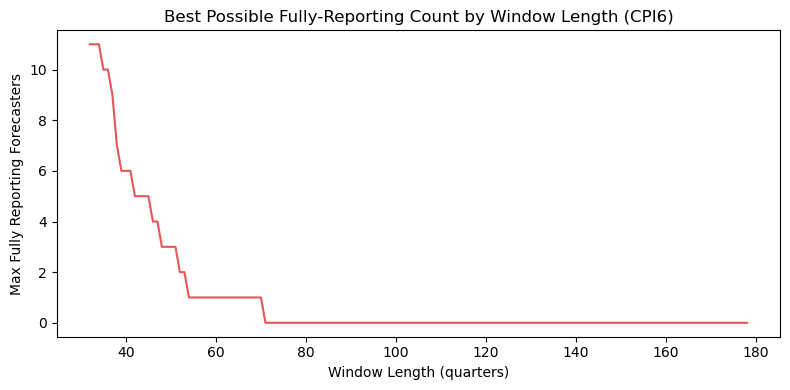


Horizon: CPIA
  Optimal window (max fully reporting forecasters):
    Window: 2014-06-30 00:00:00 to 2022-09-30 00:00:00 (len=34 quarters)
    Fully reporting forecasters: 12
    IDs (n=12): [433, 504, 510, 518, 546, 549, 555, 563, 568, 570, 572, 574]


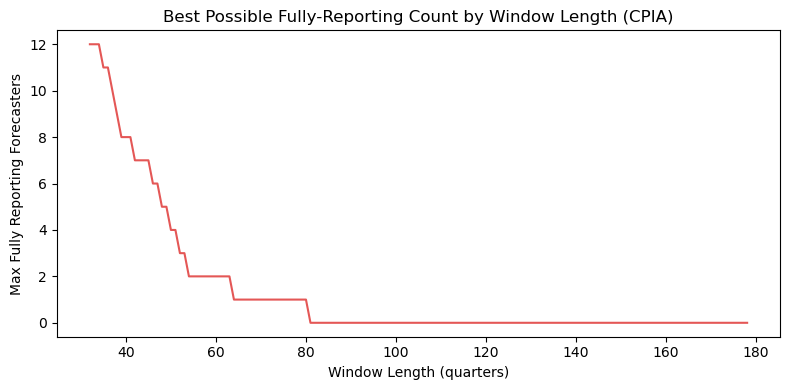


Horizon: CPIB
  Optimal window (max fully reporting forecasters):
    Window: 2013-12-31 00:00:00 to 2021-09-30 00:00:00 (len=32 quarters)
    Fully reporting forecasters: 11
    IDs (n=11): [433, 504, 510, 546, 549, 555, 557, 563, 570, 572, 574]


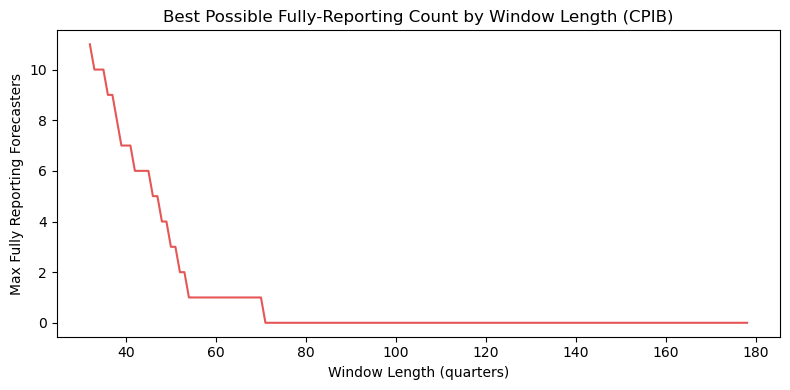


Horizon: CPIC
  Optimal window (max fully reporting forecasters):
    Window: 2014-06-30 00:00:00 to 2022-03-31 00:00:00 (len=32 quarters)
    Fully reporting forecasters: 9
    IDs (n=9): [433, 504, 510, 518, 549, 563, 570, 572, 574]


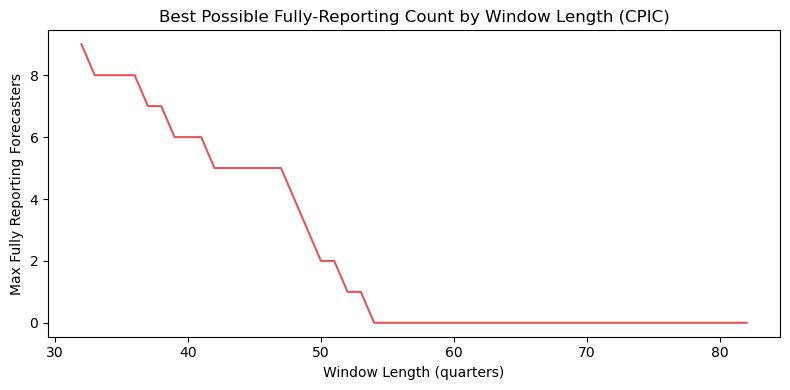

In [7]:
# Find the optimal contiguous period window maximizing fully-reporting forecasters, by horizon
# Definition: a forecaster is 'fully reporting' if they reported in every period within the window.
# Constraint: minimum window length of 15 years (60 quarters).
# Optional constraint: require the window to include a specific date (set REQUIRED_DATE).

MIN_YEARS = 8
REQUIRED_DATE = None  # e.g., '2008-09-30' to require the window include 2008Q3

analyze_optimal_reporting_windows(
    df,
    forecast_cols,
    min_years=MIN_YEARS,
    required_date=REQUIRED_DATE,
)


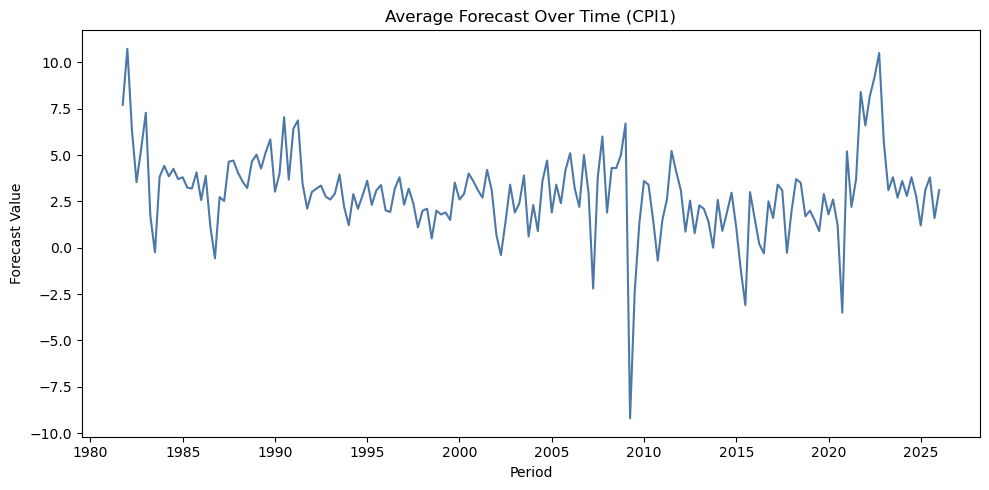

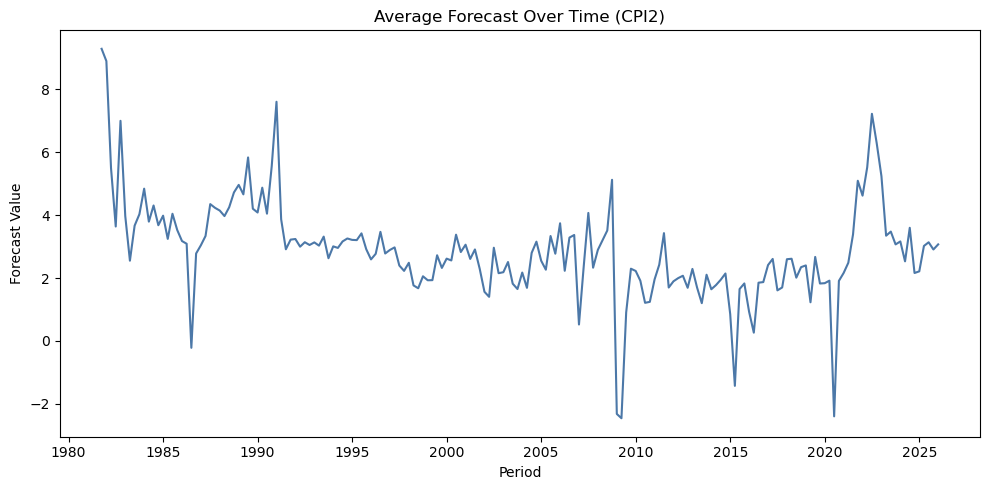

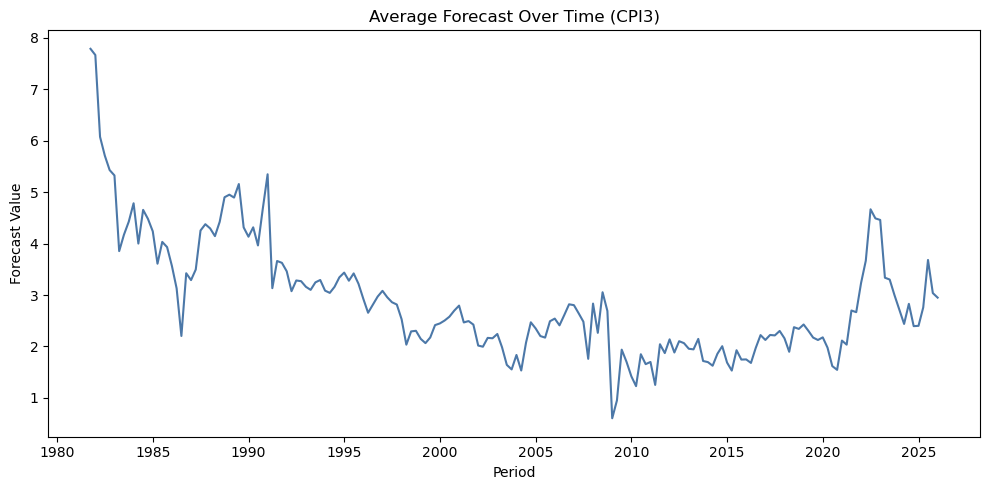

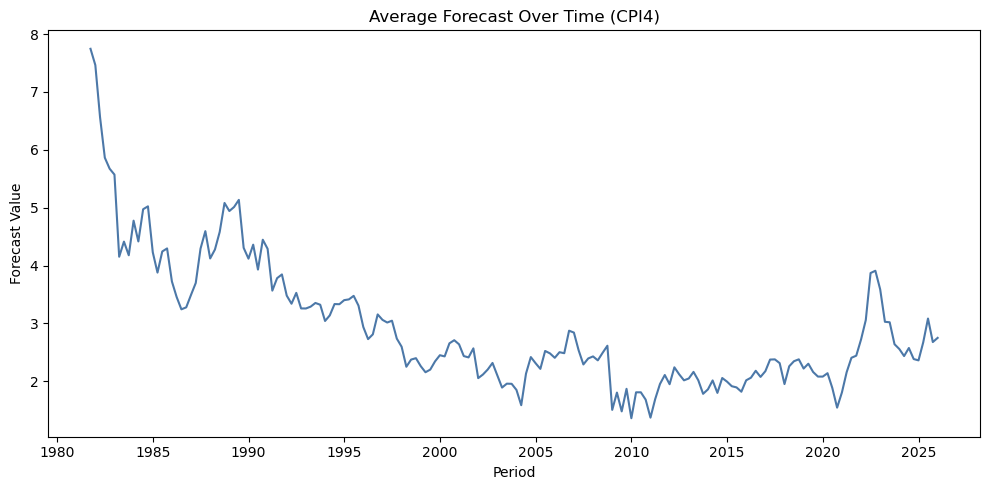

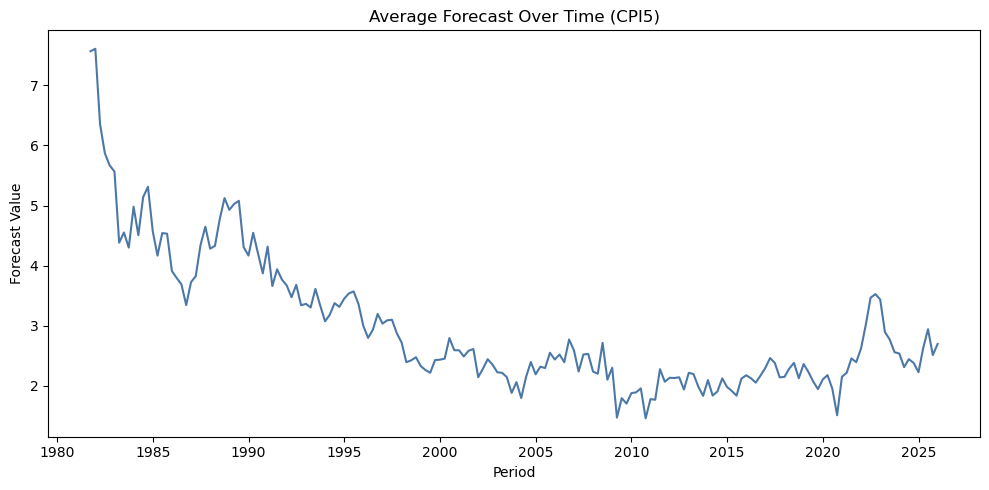

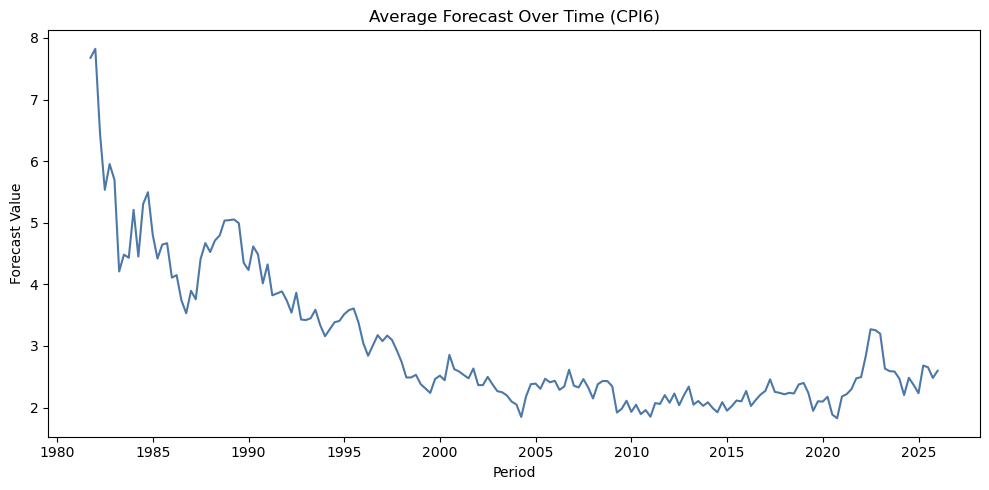

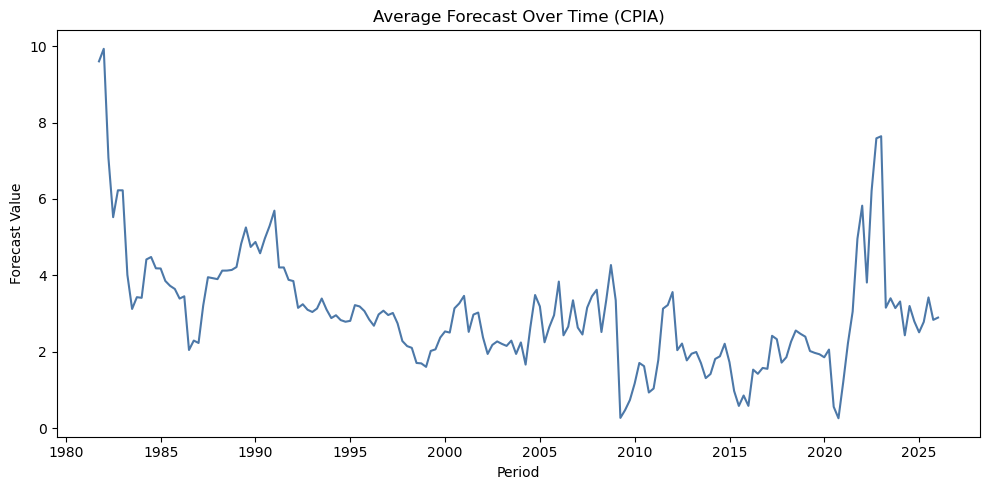

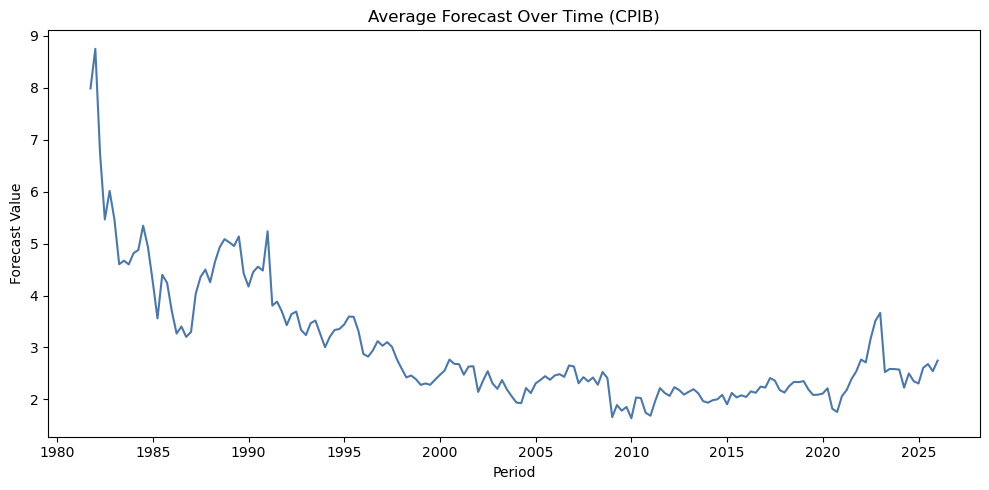

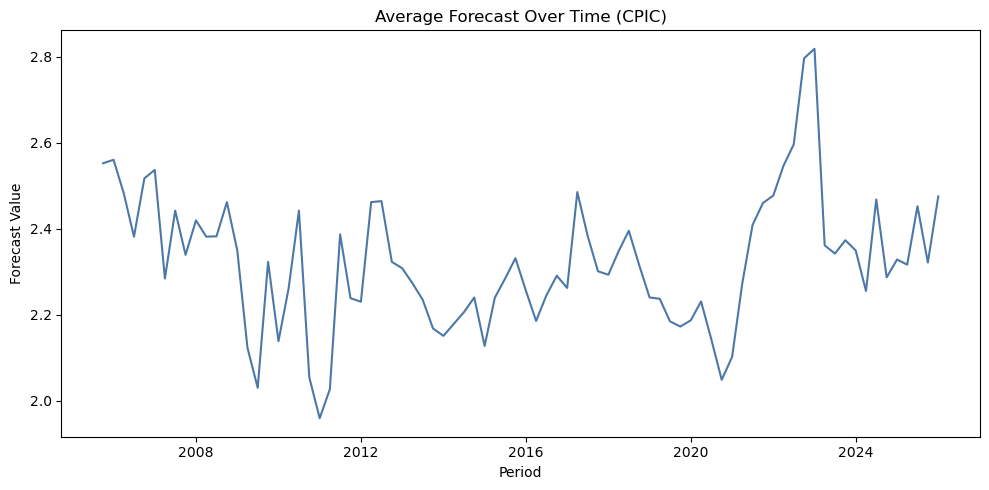

In [8]:
# Forecasts over time: average by horizon across forecasters (separate figures)
avg_by_period = average_forecasts_by_period(df, forecast_cols)
plot_average_forecasts_over_time(avg_by_period, forecast_cols)


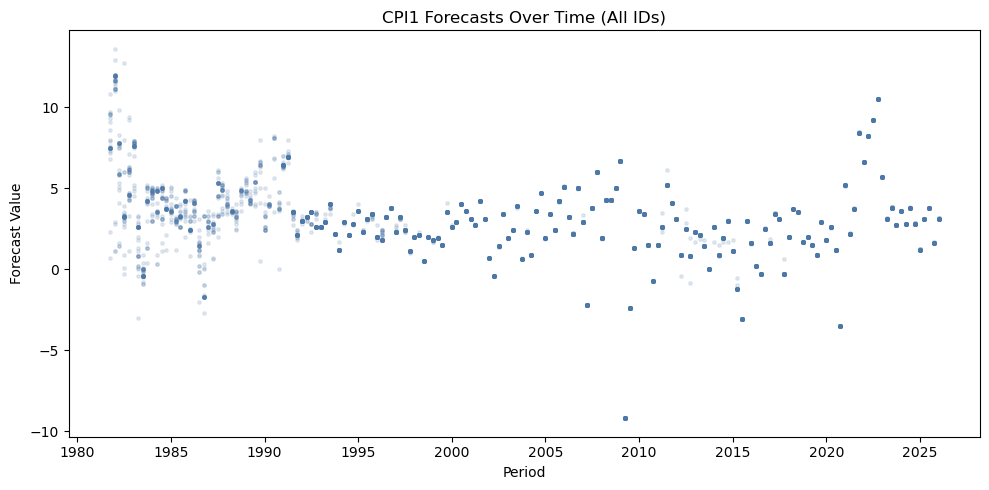

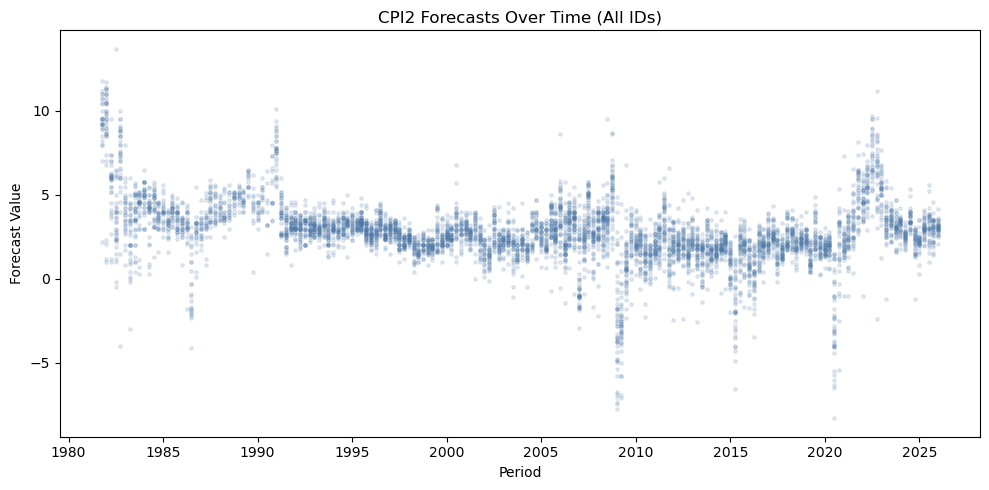

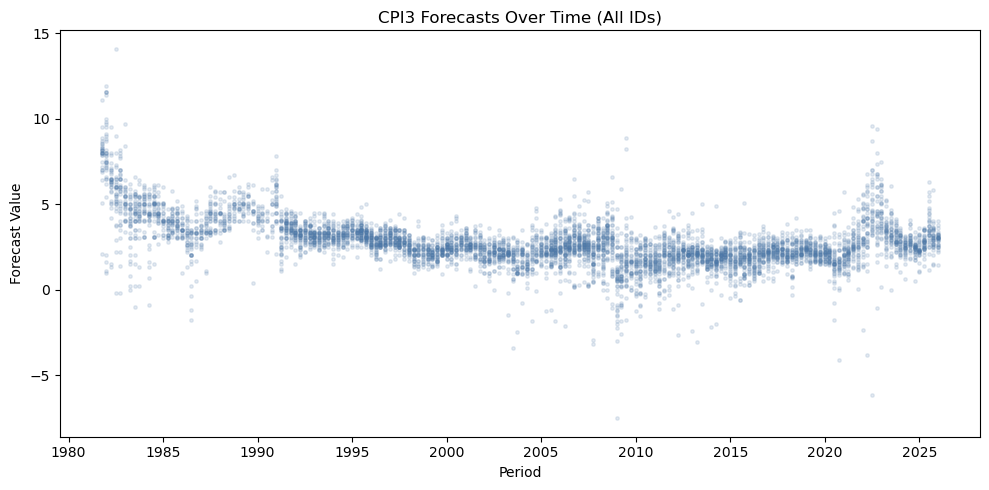

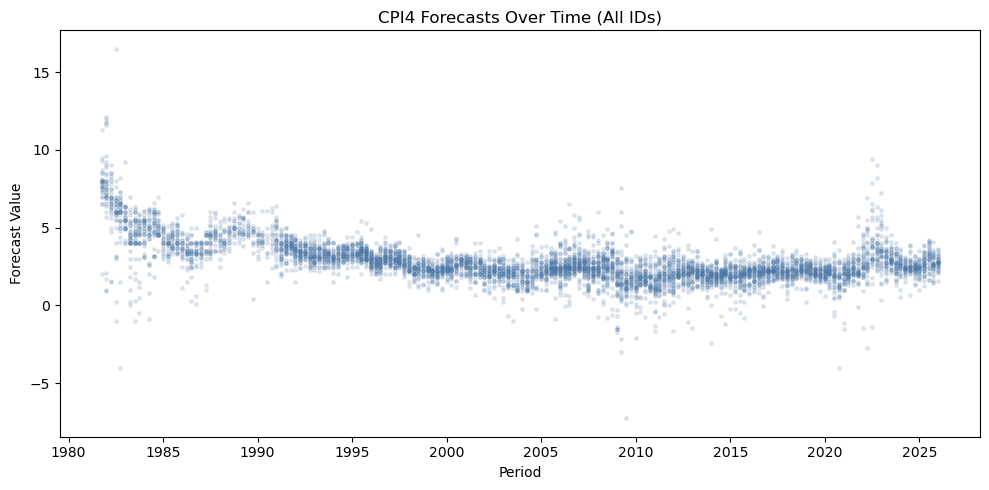

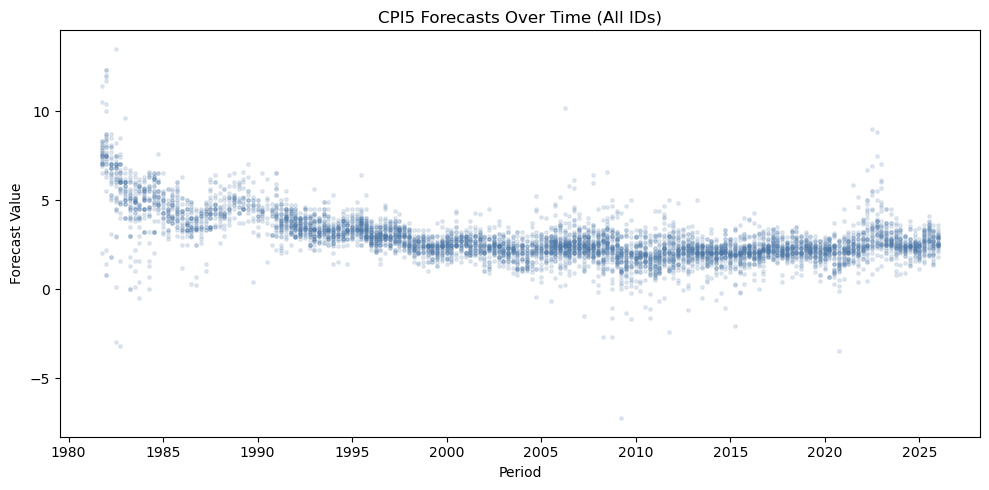

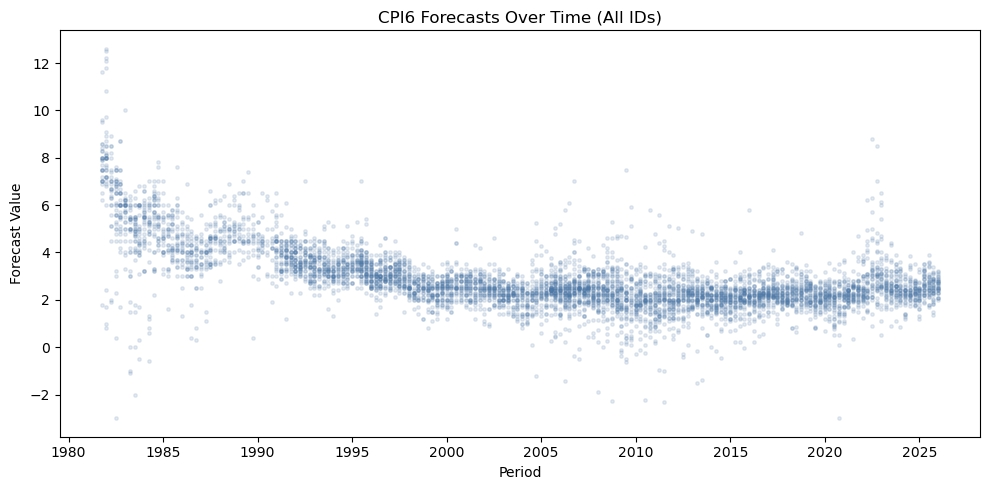

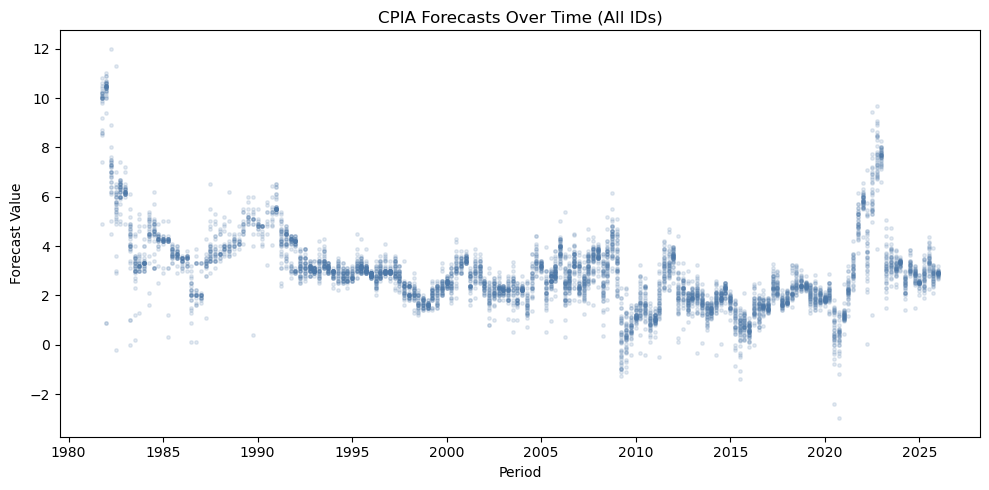

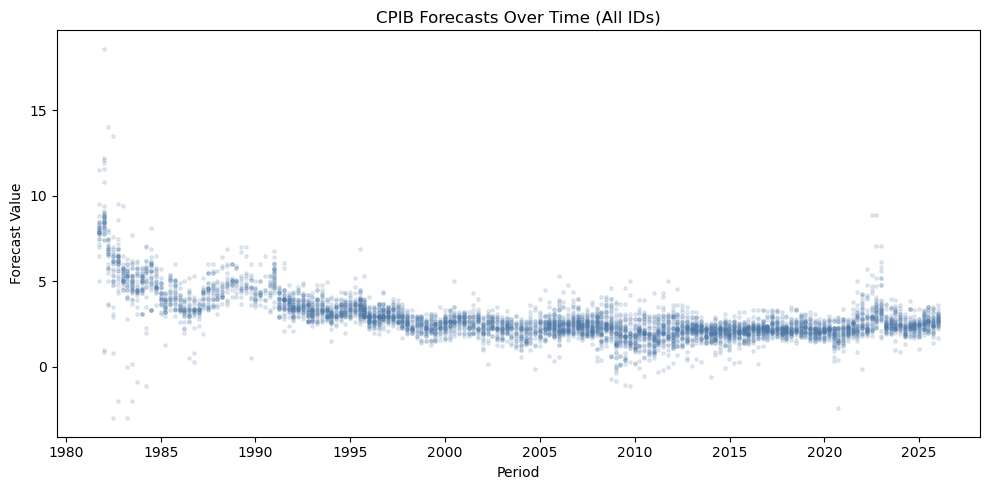

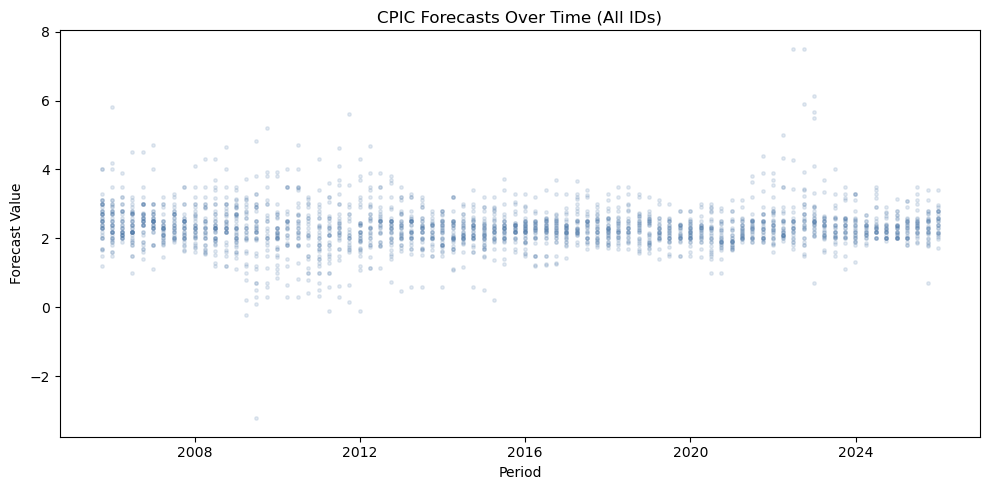

In [9]:
# Dispersion scatter: separate figures for each horizon
long = long_forecast_frame(df, forecast_cols)
plot_dispersion_scatter(long)


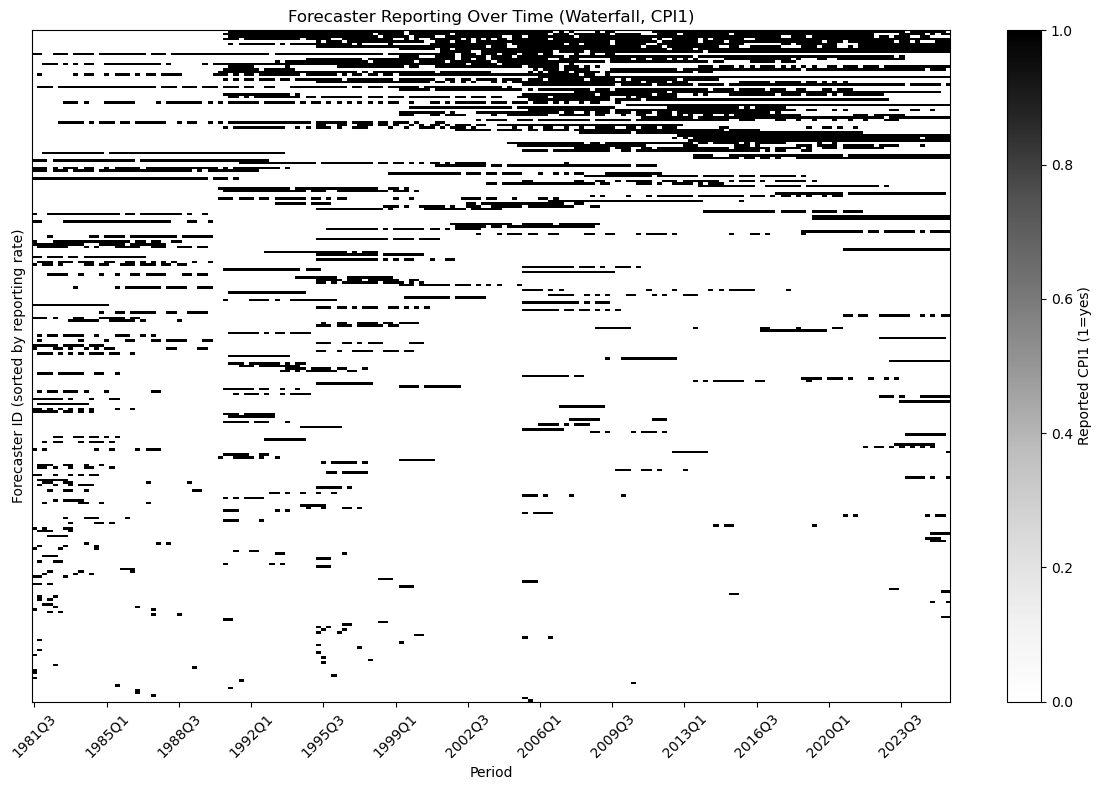

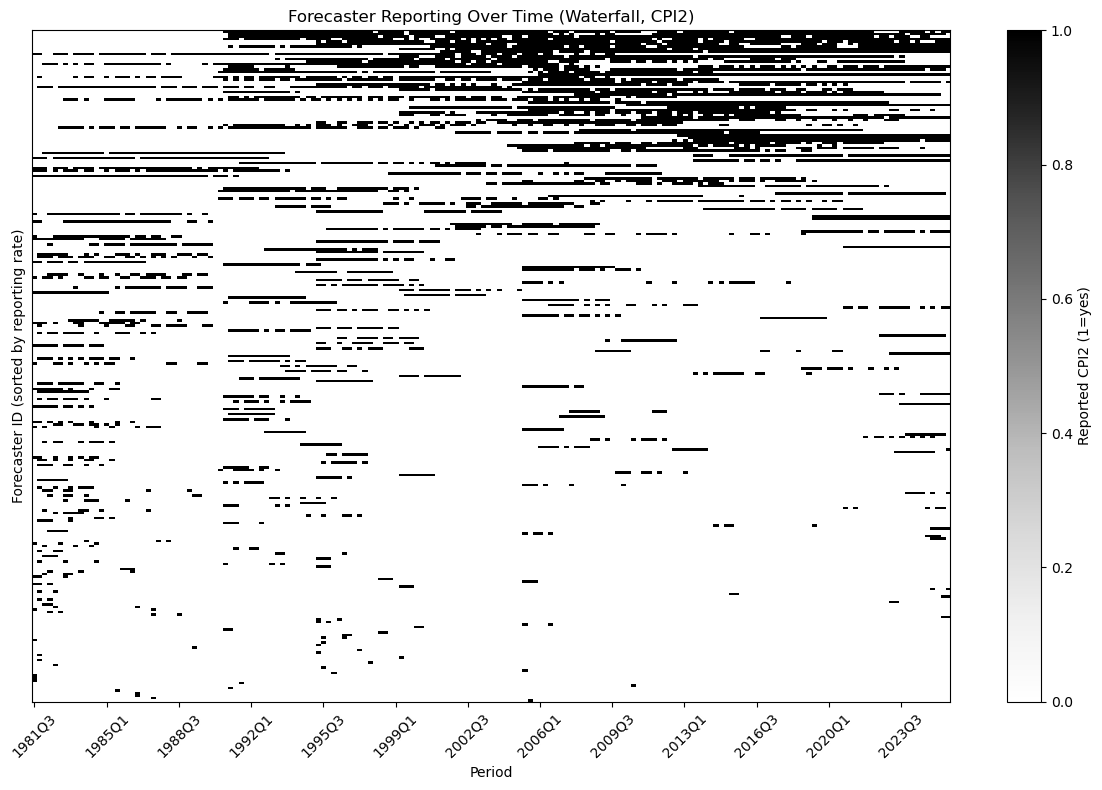

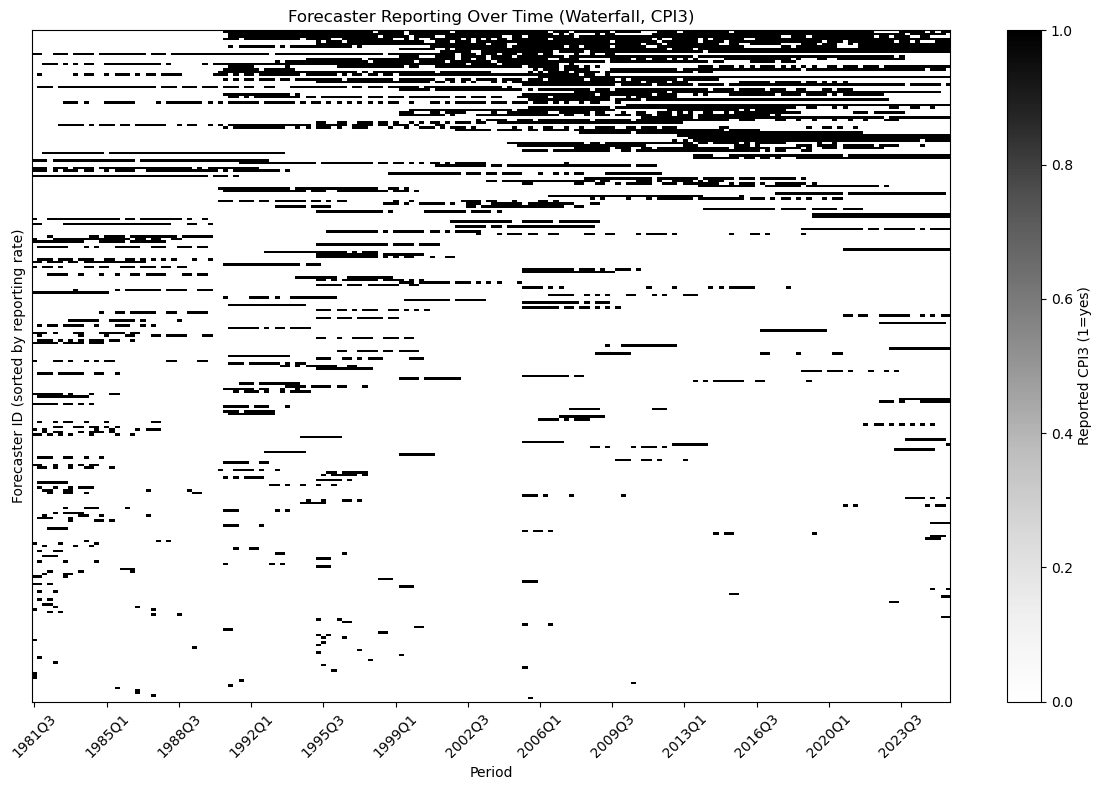

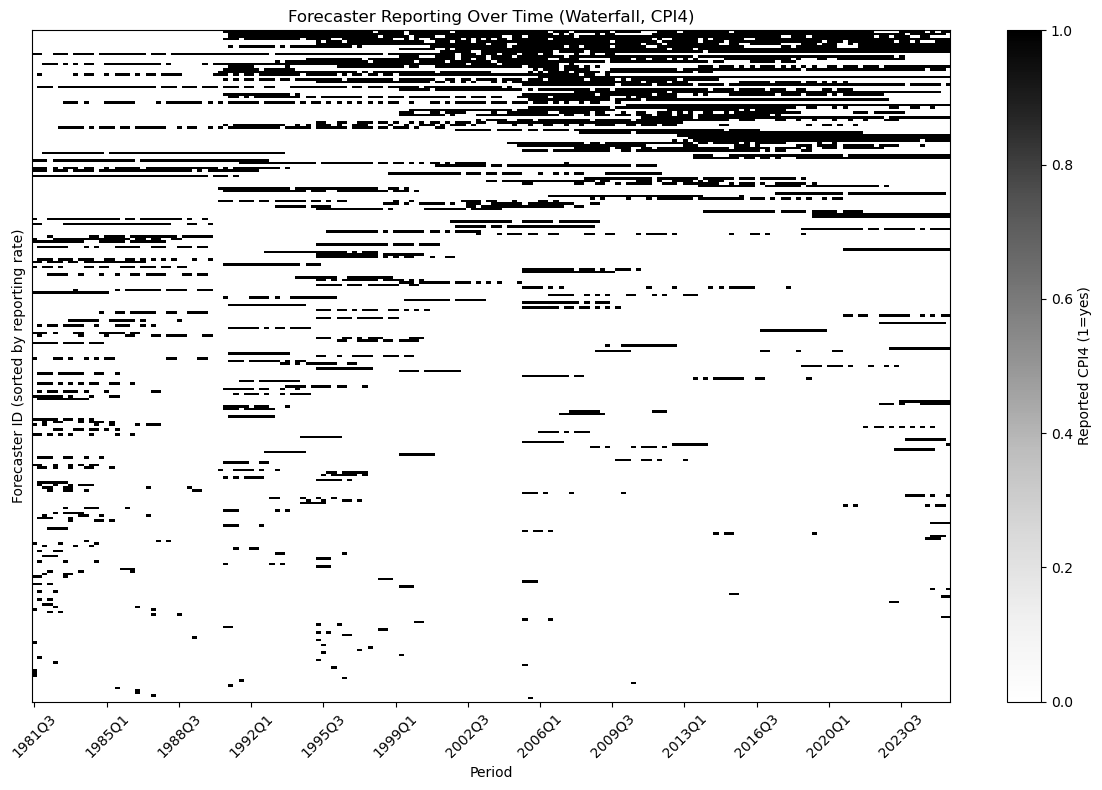

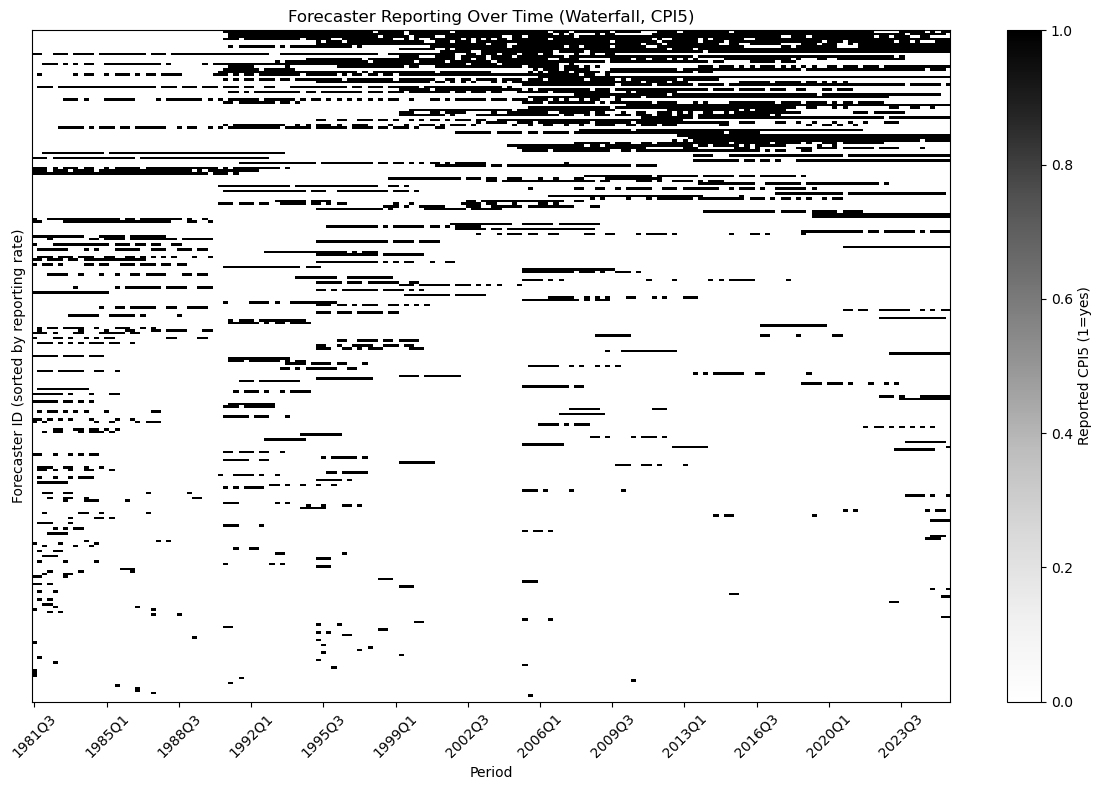

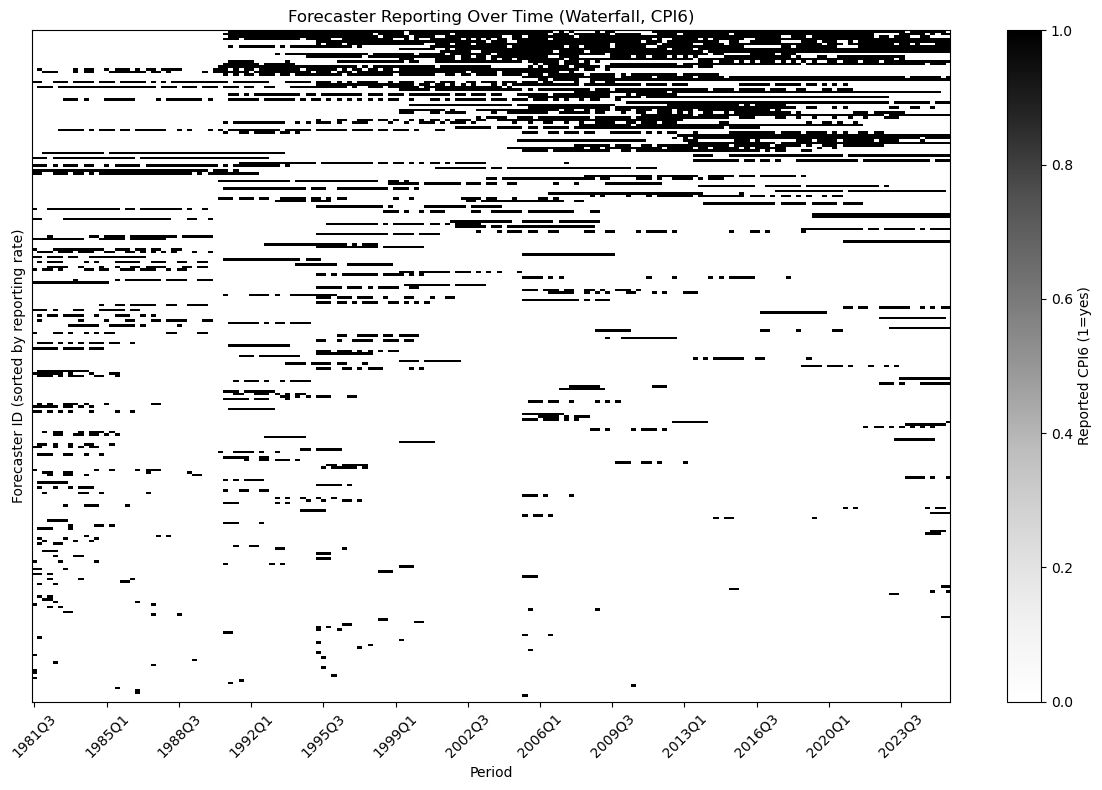

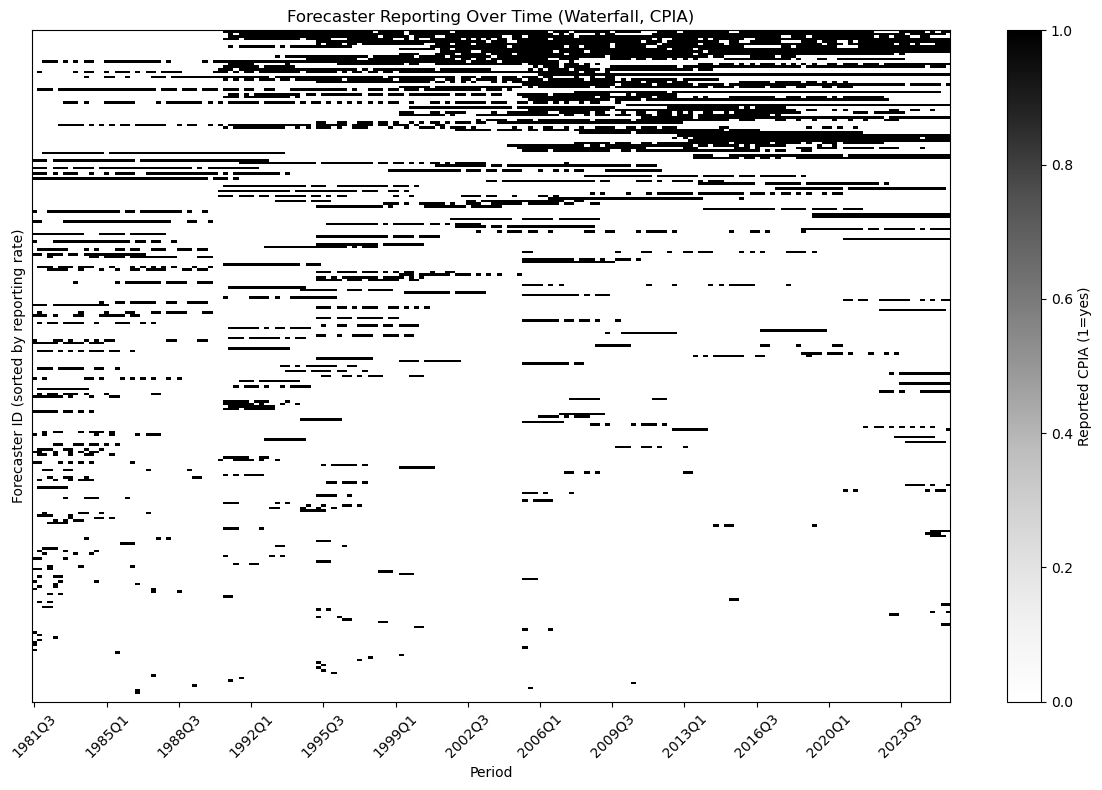

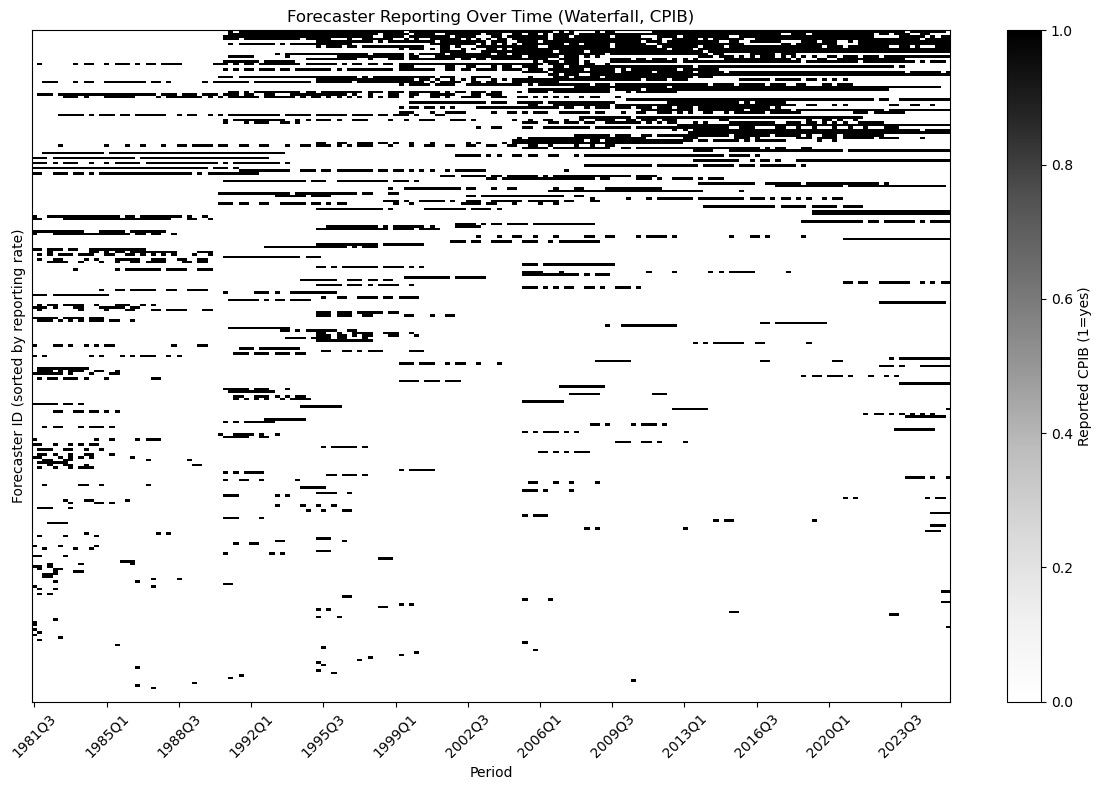

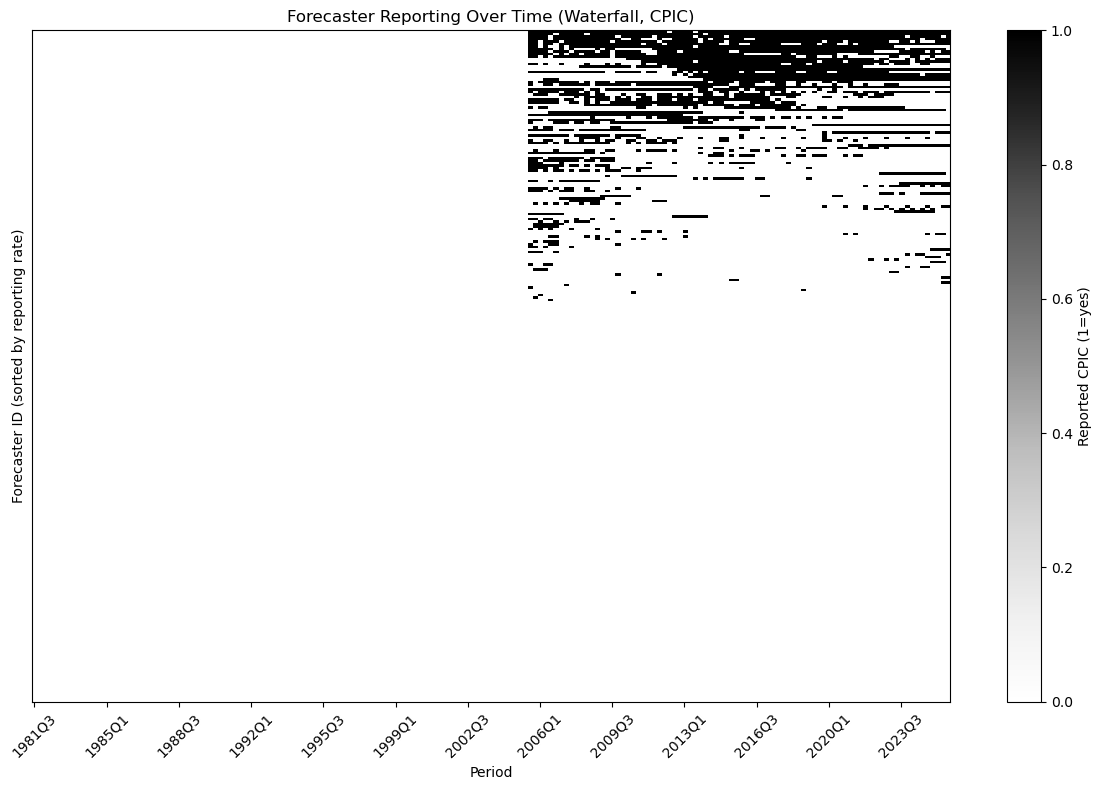

In [10]:
# Waterfall-style plot: forecaster reporting over time (ID x period), per horizon
plot_reporting_waterfall(df, forecast_cols)


In [11]:
# SPF + VIX experiment setup (Realiz5 actuals + uncertainty inputs)
from pathlib import Path
import sys
import importlib
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "analyses" else Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import src.data.loading as ld
import src.data.cleaning as cln

ld = importlib.reload(ld)
cln = importlib.reload(cln)

realiz_raw = ld.load_or_download_spf_realiz5_actuals(
    csv_path=ld.DEFAULT_SPF_CPI_REALIZ5_CSV_PATH,
    url=ld.SPF_CPI_REALIZ5_URL,
)
vix_raw = ld.load_or_download_vix_data(
    csv_path=ld.DEFAULT_VIX_CSV_PATH,
    url=ld.VIX_CSV_URL,
)

try:
    cpi_actuals_level = cln.clean_spf_realiz5_actuals(realiz_raw, realiz_col='Realiz5')
except Exception as e:
    print('Realiz5 parse failed:', type(e).__name__, str(e))
    print('Realiz5 columns:', list(realiz_raw.columns))
    display(realiz_raw.head())
    raise

actual_inflation = cln.realiz5_to_actual_inflation(
    cpi_actuals_level,
    assume_already_annualized=True,
)
actual_inflation = actual_inflation.rename(columns={'time': 'period'})
actual_inflation['period'] = pd.PeriodIndex(pd.to_datetime(actual_inflation['period']), freq='Q')

# Bind helpers used in downstream cells
build_spf_cpi_panel_with_actuals = cln.build_spf_cpi_panel_with_actuals
find_optimal_reporting_window = cln.find_optimal_reporting_window
prepare_vix_data = cln.prepare_vix_data

vix_daily, vix_quarterly = prepare_vix_data(vix_raw)

print('realiz_raw shape:', realiz_raw.shape)
print('realiz_raw columns:', list(realiz_raw.columns)[:10])
print('cpi_actuals_level shape:', cpi_actuals_level.shape)
print('actual_inflation shape:', actual_inflation.shape)
print('  date range:', actual_inflation['period'].min(), 'to', actual_inflation['period'].max())
print('vix_daily shape:', vix_daily.shape)
print('vix_quarterly shape:', vix_quarterly.shape)
print('  VIX date range:', vix_quarterly['period'].min(), 'to', vix_quarterly['period'].max())

display(actual_inflation.head())
display(vix_quarterly.head())


realiz_raw shape: (232, 31)
realiz_raw columns: ['Date', 'SPFfor_Step1', 'SPFfor_Step2', 'SPFfor_Step3', 'SPFfor_Step4', 'SPFfor_Step5', 'IARfor_Step1', 'IARfor_Step2', 'IARfor_Step3', 'IARfor_Step4']
cpi_actuals_level shape: (227, 2)
actual_inflation shape: (227, 2)
  date range: 1968Q4 to 2025Q2
vix_daily shape: (9127, 2)
vix_quarterly shape: (145, 2)
  VIX date range: 1990Q1 to 2026Q1


,period,actual_inflation_annualized
0,1968Q4,5.045115
1,1969Q1,4.982286
2,1969Q2,6.471056
3,1969Q3,5.603520
4,1969Q4,6.279878


,period,vix_q_mean
0,1990Q1,22.174603
1,1990Q2,18.722063
2,1990Q3,25.195556
3,1990Q4,26.113281
4,1991Q1,22.515833


In [12]:
# Build SPF panel with horizon-aligned Realiz5 actuals, with data-driven offset selection.
#
# Some SPF extracts differ by timing convention. We therefore search a small
# per-horizon offset grid and pick the offset that minimises consensus-forecast
# MSE against the matched actuals, then use those offsets for the experiment.
import pandas as pd
import numpy as np

HORIZONS = ['CPI1', 'CPI2', 'CPI3']
MIN_YEARS = 8
OFFSET_CANDIDATES = [-1, 0, 1, 2, 3]

def select_best_horizon_offsets(spf_clean, actual_inflation, horizons, candidates):
    best_offsets = {}
    diag_rows = []
    for h in horizons:
        best_mse = np.inf
        best_off = None
        for off in candidates:
            sub_panel = build_spf_cpi_panel_with_actuals(
                spf_clean=spf_clean,
                actual_inflation=actual_inflation,
                horizons=[h],
                horizon_offsets={h: int(off)},
            )
            if sub_panel.empty:
                continue
            # Consensus-by-origin score for offset selection
            g = sub_panel.groupby('origin_period', as_index=False).agg(
                consensus=('forecast', 'mean'),
                actual=('actual', 'last'),
            )
            if len(g) < 16:
                continue
            mse = float(np.mean((g['actual'].to_numpy() - g['consensus'].to_numpy()) ** 2))
            mae = float(np.mean(np.abs(g['actual'].to_numpy() - g['consensus'].to_numpy())))
            diag_rows.append({'horizon': h, 'offset': int(off), 'n_origin': int(len(g)), 'mse': mse, 'mae': mae})
            if mse < best_mse:
                best_mse = mse
                best_off = int(off)
        if best_off is None:
            raise RuntimeError(f'No feasible offset found for {h}.')
        best_offsets[h] = best_off
    return best_offsets, pd.DataFrame(diag_rows)

horizon_offsets, offset_diag_df = select_best_horizon_offsets(
    spf_clean=df,
    actual_inflation=actual_inflation,
    horizons=HORIZONS,
    candidates=OFFSET_CANDIDATES,
)

print('Selected horizon offsets (target_period = origin_period + offset):')
for h in HORIZONS:
    print(f'  {h}: offset={horizon_offsets[h]}')

print('\nOffset selection diagnostics (lower MSE is better):')
display(offset_diag_df.sort_values(['horizon', 'mse', 'offset']).reset_index(drop=True))

panel_long = build_spf_cpi_panel_with_actuals(
    spf_clean=df,
    actual_inflation=actual_inflation,
    horizons=HORIZONS,
    horizon_offsets=horizon_offsets,
)

# Show alignment diagnostics
print('panel_long shape:', panel_long.shape)
print('Columns:', list(panel_long.columns))
for h in HORIZONS:
    sub = panel_long[panel_long['horizon_name'] == h]
    print(f'\n{h}: {len(sub)} rows, origin {sub["origin_period"].min()} to '
          f'{sub["origin_period"].max()}, target {sub["target_period"].min()} to '
          f'{sub["target_period"].max()}')
    print(f'  Actual range: [{sub["actual"].min():.2f}, {sub["actual"].max():.2f}]')
display(panel_long.head())

windows = {}
for h in HORIZONS:
    windows[h] = find_optimal_reporting_window(
        spf_clean=df,
        forecast_col=h,
        min_years=MIN_YEARS,
        required_date=None,
    )

windows_df = pd.DataFrame([
    {
        'horizon': h,
        'offset': horizon_offsets[h],
        'start_period': str(windows[h]['start_period']),
        'end_period': str(windows[h]['end_period']),
        'n_periods': windows[h]['n_periods'],
        'n_forecasters': windows[h]['n_ids'],
    }
    for h in HORIZONS
])

print('\nOptimal reporting windows:')
display(windows_df)


Selected horizon offsets (target_period = origin_period + offset):
  CPI1: offset=-1
  CPI2: offset=0
  CPI3: offset=0

Offset selection diagnostics (lower MSE is better):


,horizon,offset,n_origin,mse,mae
0,CPI1,-1,177,0.272633,0.399001
1,CPI1,0,176,5.728933,1.636084
2,CPI1,2,174,7.517656,1.893109
3,CPI1,1,175,7.977388,1.904590
4,CPI1,3,173,8.467659,1.953217
5,CPI2,0,176,1.620762,0.895086
6,CPI2,-1,177,2.685362,1.069904
7,CPI2,1,175,4.934387,1.477118
8,CPI2,3,173,5.409783,1.596100
9,CPI2,2,174,5.571377,1.604247


panel_long shape: (18273, 7)
Columns: ['ID', 'origin_period', 'forecast', 'horizon_name', 'horizon', 'target_period', 'actual']

CPI1: 6123 rows, origin 1981Q3 to 2025Q3, target 1981Q2 to 2025Q2
  Actual range: [-8.85, 11.61]

CPI2: 6074 rows, origin 1981Q3 to 2025Q2, target 1981Q3 to 2025Q2
  Actual range: [-8.85, 11.61]

CPI3: 6076 rows, origin 1981Q3 to 2025Q2, target 1981Q3 to 2025Q2
  Actual range: [-8.85, 11.61]


,ID,origin_period,forecast,horizon_name,horizon,target_period,actual
0,4,1981Q3,9.1,CPI1,0,1981Q2,8.604107
1,5,1981Q3,7.5,CPI1,0,1981Q2,8.604107
2,16,1981Q3,7.5,CPI1,0,1981Q2,8.604107
3,18,1981Q3,7.2,CPI1,0,1981Q2,8.604107
4,19,1981Q3,7.5,CPI1,0,1981Q2,8.604107



Optimal reporting windows:


,horizon,offset,start_period,end_period,n_periods,n_forecasters
0,CPI1,-1,2014Q2,2022Q3,34,12
1,CPI2,0,2014Q2,2022Q3,34,12
2,CPI3,0,2014Q2,2022Q3,34,12


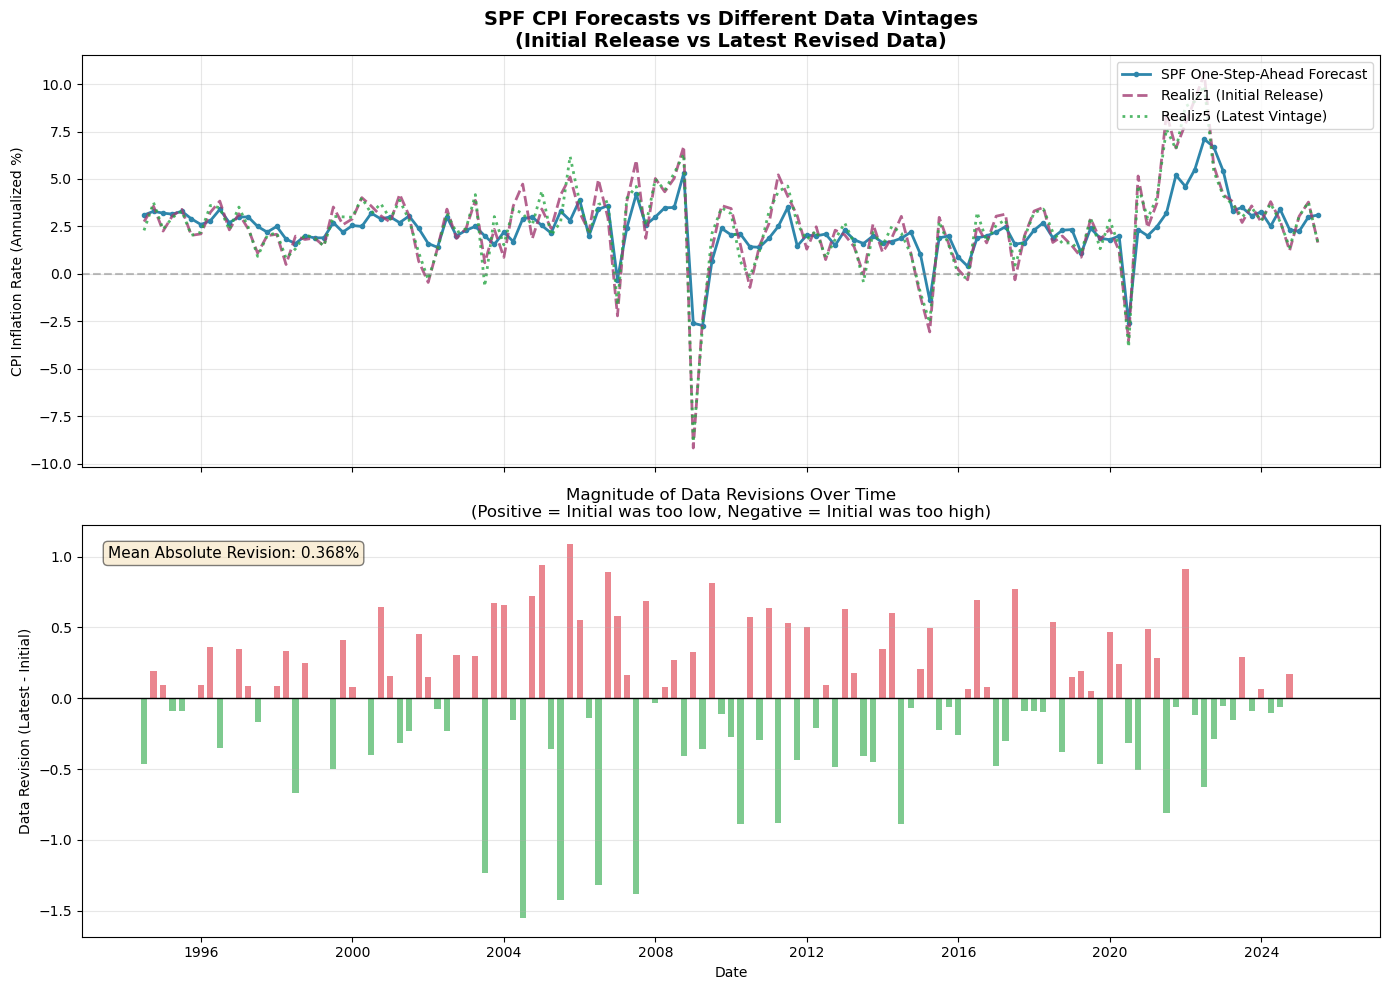

FORECAST ERROR COMPARISON: INITIAL RELEASE vs LATEST VINTAGE
Rows used: 125
Date range: 1994-06-30 to 2025-06-30

Using INITIAL RELEASE (Realiz1) as the benchmark:
  Mean Error: 0.159%
  Mean Absolute Error: 1.009%
  RMSE: 1.393%

Using LATEST VINTAGE (Realiz5) as the benchmark:
  Mean Error: 0.160%
  Mean Absolute Error: 0.943%
  RMSE: 1.337%

Data Revision Statistics:
  Mean Revision (Latest - Initial): 0.001%
  Mean Absolute Revision: 0.368%
  Std Dev of Revisions: 0.496%


,Date,SPFfor_Step1,Realiz1,Realiz5,DateTime,Revision,Error_Initial,Error_Latest
0,1994:02,3.10,2.754028,2.291645,1994-06-30,-0.462382,-0.345972,-0.808355
1,1994:03,3.30,3.566589,3.757183,1994-09-30,0.190594,0.266589,0.457183
2,1994:04,3.20,2.255974,2.348590,1994-12-31,0.092616,-0.944026,-0.851410
3,1995:01,3.15,3.060086,2.970429,1995-03-31,-0.089656,-0.089914,-0.179571
4,1995:02,3.30,3.398625,3.310313,1995-06-30,-0.088312,0.098625,0.010313


In [13]:
# Diagnostic plot from SPF error-stats table (already date-aligned; no realignment)
import numpy as np
import matplotlib.pyplot as plt
from src.data.cleaning import clean_spf_error_stats_revision_table

comparison_df_full = clean_spf_error_stats_revision_table(
    realiz_df=realiz_raw,
    date_col='Date',
    forecast_col='SPFfor_Step1',
    realiz_initial_col='Realiz1',
    realiz_latest_col='Realiz5',
)

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

ax1 = axes[0]
ax1.plot(
    comparison_df_full['DateTime'], comparison_df_full['SPFfor_Step1'],
    label='SPF One-Step-Ahead Forecast', color='#2E86AB', linewidth=2, marker='o', markersize=3,
)
ax1.plot(
    comparison_df_full['DateTime'], comparison_df_full['Realiz1'],
    label='Realiz1 (Initial Release)', color='#A23B72', linewidth=2, linestyle='--', alpha=0.8,
)
ax1.plot(
    comparison_df_full['DateTime'], comparison_df_full['Realiz5'],
    label='Realiz5 (Latest Vintage)', color='#28A745', linewidth=2, linestyle=':', alpha=0.8,
)
ax1.set_ylabel('CPI Inflation Rate (Annualized %)')
ax1.set_title('SPF CPI Forecasts vs Different Data Vintages\n(Initial Release vs Latest Revised Data)', fontsize=14, fontweight='bold')
ax1.legend(loc='upper right', fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.axhline(y=0, color='gray', linestyle='--', alpha=0.5)

ax2 = axes[1]
colors = ['#DC3545' if x > 0 else '#28A745' for x in comparison_df_full['Revision']]
ax2.bar(comparison_df_full['DateTime'], comparison_df_full['Revision'], color=colors, alpha=0.6, width=60)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax2.set_xlabel('Date')
ax2.set_ylabel('Data Revision (Latest - Initial)')
ax2.set_title('Magnitude of Data Revisions Over Time\n(Positive = Initial was too low, Negative = Initial was too high)', fontsize=12)
ax2.grid(True, alpha=0.3, axis='y')

mean_abs_revision = comparison_df_full['Revision'].abs().mean()
ax2.text(
    0.02,
    0.95,
    f'Mean Absolute Revision: {mean_abs_revision:.3f}%',
    transform=ax2.transAxes,
    fontsize=11,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
)

plt.tight_layout()
plt.show()

comparison_df_full['Error_Initial'] = comparison_df_full['Realiz1'] - comparison_df_full['SPFfor_Step1']
comparison_df_full['Error_Latest'] = comparison_df_full['Realiz5'] - comparison_df_full['SPFfor_Step1']

print('=' * 70)
print('FORECAST ERROR COMPARISON: INITIAL RELEASE vs LATEST VINTAGE')
print('=' * 70)
print(f"Rows used: {len(comparison_df_full)}")
print(f"Date range: {comparison_df_full['DateTime'].min().date()} to {comparison_df_full['DateTime'].max().date()}")

print('\nUsing INITIAL RELEASE (Realiz1) as the benchmark:')
print(f"  Mean Error: {comparison_df_full['Error_Initial'].mean():.3f}%")
print(f"  Mean Absolute Error: {comparison_df_full['Error_Initial'].abs().mean():.3f}%")
print(f"  RMSE: {np.sqrt((comparison_df_full['Error_Initial'] ** 2).mean()):.3f}%")

print('\nUsing LATEST VINTAGE (Realiz5) as the benchmark:')
print(f"  Mean Error: {comparison_df_full['Error_Latest'].mean():.3f}%")
print(f"  Mean Absolute Error: {comparison_df_full['Error_Latest'].abs().mean():.3f}%")
print(f"  RMSE: {np.sqrt((comparison_df_full['Error_Latest'] ** 2).mean()):.3f}%")

print('\nData Revision Statistics:')
print(f"  Mean Revision (Latest - Initial): {comparison_df_full['Revision'].mean():.3f}%")
print(f"  Mean Absolute Revision: {mean_abs_revision:.3f}%")
print(f"  Std Dev of Revisions: {comparison_df_full['Revision'].std():.3f}%")

comparison_df_full.head()



In [14]:
# ─── Ensemble experiment: build matrices, (optionally) tune, then evaluate ───
#
# STATE: PCA of (VIX, cross-sectional disagreement, rolling error-volatility).
# The expanding PCA is online-safe: at each t it only uses data up to t.
#
# HYPERPARAMETER TUNING: If USE_OPTUNA=True, Optuna searches η and κ on the
# CPI1 window under MSE objective; the same parameters are then applied to
# all horizons and both loss objectives for a clean robustness comparison.
import importlib
import numpy as np
import pandas as pd
from IPython.display import display

import src.evaluation.spf_experiment as spfexp
import src.evaluation.optuna_tuning as ot
import src.data.cleaning as cln

spfexp = importlib.reload(spfexp)
ot     = importlib.reload(ot)
cln    = importlib.reload(cln)

from src.data.cleaning import build_spf_horizon_matrix

build_spf_state_components    = spfexp.build_spf_state_components
evaluate_spf_horizon_matrix   = spfexp.evaluate_spf_horizon_matrix
pca_state_from_components     = spfexp.pca_state_from_components
aggregate_spf_results         = spfexp.aggregate_spf_results

# ── Configuration ────────────────────────────────────────────────────────────
LOSS_SECTIONS    = ['mse', 'linex']
LINEX_A          = 0.5       # LINEX asymmetry: 0→symmetric (MSE-like), larger→more asymmetric
INCLUDE_RL       = True      # include RL bandit ensemblers (RLRuleBandit, RLKappaBandit)
MIN_OBS          = 24        # min complete quarters per horizon matrix
MIN_FORECASTERS  = 3         # min forecasters required
ERROR_VOL_WINDOW = 8         # rolling window (quarters) for error-volatility state component
USE_OPTUNA       = True      # run Optuna search for η and κ
N_OPTUNA_TRIALS  = 40        # trials per method; ≥30 recommended
kappa_grid = np.array([0.01, 0.03, 0.1, 0.3, 1.0, 3.0, 8.0], dtype=float)

# ── Step 1: Build horizon matrices and PCA states ─────────────────────────────
print('─' * 60)
print('Step 1: Building horizon matrices and PCA states')
print('─' * 60)

mat_objects        = {}
state_frames       = {}
panel_clean_frames = {}

for h in HORIZONS:
    w = windows[h]
    print(f'\n{h}: window {w["start_period"]} → {w["end_period"]}'
          f', {w["n_ids"]} forecasters, {w["n_periods"]} periods')

    mat_obj = build_spf_horizon_matrix(
        panel_long=panel_long,
        horizon_name=h,
        start_period=w['start_period'],
        end_period=w['end_period'],
        forecaster_ids=w['ids'],
        min_obs=MIN_OBS,
        min_forecasters=MIN_FORECASTERS,
    )
    if mat_obj is None:
        print(f'  SKIP {h}: no feasible matrix after window/ID filtering')
        continue

    mat_objects[h]        = mat_obj
    panel_clean_frames[h] = mat_obj['mat_clean']
    T, N = mat_obj['F'].shape
    print(f'  Matrix: T={T} quarters, N={N} forecasters')
    print(f'  Actual range: [{mat_obj["y"].min():.2f}, {mat_obj["y"].max():.2f}] %')

    components = build_spf_state_components(
        mat=mat_obj['mat'],
        vix_quarterly=vix_quarterly,
        error_vol_window=ERROR_VOL_WINDOW,
    )
    state = pca_state_from_components(
        components=components,
        expanding=True,
        min_train=12,
    )
    components['state_pca'] = state
    state_frames[h] = components
    print(f'  State: [{state.min():.3f}, {state.max():.3f}], VIX gaps: {components["vix_q_mean"].isna().sum()}')

feasible = list(mat_objects.keys())
print(f'\nFeasible horizons: {feasible}')
if not feasible:
    raise RuntimeError('No feasible horizon matrices. Check data loading and window parameters.')

# ── Step 2: Optuna hyperparameter tuning (MSE objective on CPI1) ──────────────
print('\n' + '─' * 60)
print('Step 2: Hyperparameter tuning')
print('─' * 60)
params_map = {k: dict(v) for k, v in ot.DEFAULT_METHOD_PARAMS.items()}

if USE_OPTUNA and feasible:
    tune_h   = feasible[0]          # tune on first feasible horizon
    tune_obj = mat_objects[tune_h]
    tune_s   = state_frames[tune_h]['state_pca']
    data_slices = [(tune_obj['y'], tune_obj['F'], tune_s)]

    print(f'Tuning on {tune_h} ({len(tune_obj["y"])} obs, {tune_obj["F"].shape[1]} forecasters)')
    print('Using MSE objective for tuning (params then applied to LINEX evaluation too).')
    print('Tuning ... ', end='', flush=True)

    tune_results = ot.tune_all_methods_optuna(
        data_slices=data_slices,
        n_trials=N_OPTUNA_TRIALS,
        seed=42,
        loss='squared',
        linex_a=LINEX_A,
        objective_metric='mse',
    )
    for method, result in tune_results.items():
        for param, val in result.best_params.items():
            params_map[method][param] = val
    print('done')

    print('\nTuned parameters (MSE):')
    for method, p in params_map.items():
        if p:
            print(f'  {method}: { {k: round(v,4) for k,v in p.items()} }')
else:
    print('Using default parameters (USE_OPTUNA=False or no feasible data).')

# ── Step 3: Run all ensemblers for each horizon × loss section ────────────────
print('\n' + '─' * 60)
print('Step 3: Running ensemblers')
print('─' * 60)

detailed_rows_spf  = []
diag_rows_spf      = []
summary_rows_spf_h = []

for h in feasible:
    mat_obj = mat_objects[h]
    state   = state_frames[h]['state_pca']
    y, F    = mat_obj['y'], mat_obj['F']

    rows_h, diag_h, summary_h = evaluate_spf_horizon_matrix(
        horizon_name=h,
        mat=mat_obj['mat'],
        y=y,
        F=F,
        state=state,
        loss_sections=LOSS_SECTIONS,
        linex_a=float(LINEX_A),
        include_rl=bool(INCLUDE_RL),
        params_map=params_map,
        kappa_grid=kappa_grid,
    )
    detailed_rows_spf.extend(rows_h)
    diag_rows_spf.extend(diag_h)
    summary_rows_spf_h.extend(summary_h)
    n_methods = len({r['method'] for r in rows_h})
    print(f'  {h}: {n_methods} methods × {len(LOSS_SECTIONS)} loss sections = {len(rows_h)} rows')

summary_rows_spf_overall = aggregate_spf_results(detailed_rows_spf)

det_df = pd.DataFrame(detailed_rows_spf)
print(f'\nTotal result rows: {len(detailed_rows_spf)}, diagnostic rows: {len(diag_rows_spf)}')
print('\nSample results (CPI1, MSE objective, sorted by objective):')
sub = det_df[(det_df['horizon_name']=='CPI1') & (det_df['loss_section']=='mse')].sort_values('objective_value')
display(sub[['method','objective_value','mse','linex','avg_hhi','avg_lambda']].round(5))


────────────────────────────────────────────────────────────
Step 1: Building horizon matrices and PCA states
────────────────────────────────────────────────────────────

CPI1: window 2014Q2 → 2022Q3, 12 forecasters, 34 periods
  Matrix: T=34 quarters, N=12 forecasters
  Actual range: [-3.85, 9.91] %
  State: [0.144, 2.966], VIX gaps: 0

CPI2: window 2014Q2 → 2022Q3, 12 forecasters, 34 periods
  Matrix: T=34 quarters, N=12 forecasters
  Actual range: [-3.85, 9.91] %
  State: [0.183, 3.381], VIX gaps: 0

CPI3: window 2014Q2 → 2022Q3, 12 forecasters, 34 periods
  Matrix: T=34 quarters, N=12 forecasters
  Actual range: [-3.85, 9.91] %
  State: [0.070, 3.536], VIX gaps: 0

Feasible horizons: ['CPI1', 'CPI2', 'CPI3']

────────────────────────────────────────────────────────────
Step 2: Hyperparameter tuning
────────────────────────────────────────────────────────────
Tuning on CPI1 (34 obs, 12 forecasters)
Using MSE objective for tuning (params then applied to LINEX evaluation too).
Tuning

/home/clayt/miniconda3/envs/ensemble/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-02-25 23:24:20,668] A new study created in memory with name: no-name-3cbaf9ce-7c96-4336-9097-e7223694c5e4
[I 2026-02-25 23:24:20,670] A new study created in memory with name: no-name-208f15c6-0ab6-419a-a2b7-2ace7b7fb544
[I 2026-02-25 23:24:20,676] A new study created in memory with name: no-name-38a568eb-9c98-48b5-8fc8-bf4688a0881e
[I 2026-02-25 23:24:20,684] Trial 0 finished with value: 0.20297482033630915 and parameters: {'eta': 0.006176922619231805}. Best is trial 0 with value: 0.20297482033630915.
[I 2026-02-25 23:24:20,689] Trial 1 finished with value: 0.20299571520544935 and parameters: {'eta': 0.12121579577832271}. Best is trial 0 with value: 0.20297482033630915.
[I 2026-02-25 23:24:20,697] Trial 2 finish

done

Tuned parameters (MSE):
  OGDVanilla: {'eta': 0.001}
  MWUMVanilla: {'eta': 0.001}
  OGDBoth: {'eta': 0.001, 'kappa': 0.0288, 'state_smoothing': 0.9, 'lambda_min': 0.0}
  OGDConcOnly: {'eta': 0.0131, 'kappa': 7.9893, 'state_smoothing': 0.9, 'lambda_min': 0.0}
  MWUMBothKL: {'eta': 0.001, 'kappa': 0.2715, 'state_smoothing': 0.9, 'lambda_min': 0.0}
  MWUMConcOnlyKL: {'eta': 0.0066, 'kappa': 0.015, 'state_smoothing': 0.9, 'lambda_min': 0.0}

────────────────────────────────────────────────────────────
Step 3: Running ensemblers
────────────────────────────────────────────────────────────
  CPI1: 10 methods × 2 loss sections = 20 rows
  CPI2: 10 methods × 2 loss sections = 20 rows
  CPI3: 10 methods × 2 loss sections = 20 rows

Total result rows: 60, diagnostic rows: 408

Sample results (CPI1, MSE objective, sorted by objective):


/home/clayt/Ensemble-Forecasting/src/evaluation/spf_experiment.py:240: RuntimeWarning: Mean of empty slice
  "avg_lambda_mean": float(np.nanmean(lambdas)),
/home/clayt/Ensemble-Forecasting/src/evaluation/spf_experiment.py:239: RuntimeWarning: Mean of empty slice
  "avg_hhi_mean": float(np.nanmean(hhis)),


,method,objective_value,mse,linex,avg_hhi,avg_lambda
0,Mean,0.20297,0.20297,0.02538,0.08333,NaN
5,OGDConcOnly,0.20297,0.20297,0.02538,0.08333,5.44317
6,MWUMBothKL,0.20297,0.20297,0.02538,0.08333,0.18495
3,MWUMVanilla,0.20297,0.20297,0.02538,0.08333,NaN
7,MWUMConcOnlyKL,0.20297,0.20297,0.02538,0.08333,0.01025
2,OGDVanilla,0.20297,0.20297,0.02538,0.08333,NaN
4,OGDBoth,0.20297,0.20297,0.02538,0.08333,0.01962
8,RLRuleBandit,0.20297,0.20297,0.02538,0.08333,NaN
9,RLKappaBandit,0.20305,0.20305,0.02539,0.13862,1.06760
1,Median,0.20315,0.20315,0.02541,NaN,NaN


In [15]:
## ── Evaluation Tables ────────────────────────────────────────────────────────
#
# Table 1: Per-horizon, per-loss ranking of all methods by objective metric.
# Table 2: Flat summary across horizons for robustness comparison.
# Table 3: Pivot of MSE vs LINEX to show whether rankings are stable.

import pandas as pd
import numpy as np

METHOD_ORDER = [
    'Mean', 'Median',
    'OGDVanilla', 'MWUMVanilla',
    'OGDBoth', 'OGDConcOnly',
    'MWUMBothKL', 'MWUMConcOnlyKL',
    'RLRuleBandit', 'RLKappaBandit',
]

det_df = pd.DataFrame(detailed_rows_spf)

def fmt_table(df: pd.DataFrame, value_col: str, lower_is_better: bool = True) -> pd.DataFrame:
    """Pivot method × horizon, highlight best per horizon."""
    pvt = df.pivot_table(index='method', columns='horizon_name', values=value_col, aggfunc='mean')
    # Reorder methods
    keep = [m for m in METHOD_ORDER if m in pvt.index]
    pvt = pvt.reindex(keep)
    return pvt.round(4)

# ── Table 1: MSE by method × horizon ─────────────────────────────────────────
print('=' * 70)
print('TABLE 1: Mean Squared Error (MSE) — lower is better')
print('=' * 70)
for loss in LOSS_SECTIONS:
    sub = det_df[det_df['loss_section'] == loss]
    if sub.empty:
        continue
    pvt = fmt_table(sub, 'mse')
    print(f'\n  (evaluated under {loss.upper()} loss objective)\n')
    display(pvt)

# ── Table 2: LINEX loss by method × horizon ───────────────────────────────────
print('\n' + '=' * 70)
print('TABLE 2: LINEX Loss (a={}) — lower is better'.format(LINEX_A))
print('=' * 70)
for loss in LOSS_SECTIONS:
    sub = det_df[det_df['loss_section'] == loss]
    if sub.empty:
        continue
    pvt = fmt_table(sub, 'linex')
    print(f'\n  (evaluated under {loss.upper()} loss objective)\n')
    display(pvt)

# ── Table 3: Objective metric (= optimisation target) ────────────────────────
print('\n' + '=' * 70)
print('TABLE 3: Primary objective (MSE when trained on MSE, LINEX when trained on LINEX)')
print('=' * 70)
for loss in LOSS_SECTIONS:
    sub = det_df[det_df['loss_section'] == loss]
    if sub.empty:
        continue
    pvt = fmt_table(sub, 'objective_value')
    print(f'\n  Loss objective: {loss.upper()}\n')
    display(pvt)

# ── Table 4: % improvement vs best individual forecaster ─────────────────────
print('\n' + '=' * 70)
print('TABLE 4: % Improvement vs Best Individual Forecaster (positive = ensemble wins)')
print('=' * 70)
for loss in LOSS_SECTIONS:
    sub = det_df[det_df['loss_section'] == loss].copy()
    if sub.empty:
        continue
    sub['improvement_pct'] = 100 * (sub['best_individual_objective'] - sub['objective_value']) / sub['best_individual_objective'].abs()
    pvt = fmt_table(sub, 'improvement_pct', lower_is_better=False)
    print(f'\n  Loss objective: {loss.upper()}\n')
    display(pvt)

# ── Table 5: Average HHI (concentration) ─────────────────────────────────────
print('\n' + '=' * 70)
print('TABLE 5: Average HHI (weight concentration; 1/N=uniform, 1.0=all mass on one)')
print('=' * 70)
for loss in LOSS_SECTIONS:
    sub = det_df[det_df['loss_section'] == loss]
    if sub.empty:
        continue
    pvt = fmt_table(sub, 'avg_hhi', lower_is_better=False)
    print(f'\n  Loss objective: {loss.upper()}\n')
    display(pvt)


TABLE 1: Mean Squared Error (MSE) — lower is better

  (evaluated under MSE loss objective)



horizon_name,CPI1,CPI2,CPI3
method,,,
Mean,0.2030,2.4518,6.8479
Median,0.2032,2.3377,6.5369
OGDVanilla,0.2030,2.3530,6.1717
MWUMVanilla,0.2030,2.4388,6.6983
OGDBoth,0.2030,2.3521,6.1701
OGDConcOnly,0.2030,2.4160,6.3135
MWUMBothKL,0.2030,2.4390,6.6995
MWUMConcOnlyKL,0.2030,2.2417,4.4293
RLRuleBandit,0.2030,2.3682,8.5066



  (evaluated under LINEX loss objective)



horizon_name,CPI1,CPI2,CPI3
method,,,
Mean,0.2030,2.4518,6.8479
Median,0.2032,2.3377,6.5369
OGDVanilla,0.2030,2.4343,6.2589
MWUMVanilla,0.2030,2.4511,6.6091
OGDBoth,0.2030,2.4341,6.2562
OGDConcOnly,0.2030,2.4482,6.4769
MWUMBothKL,0.2030,2.4511,6.6105
MWUMConcOnlyKL,0.2030,2.3795,5.0391
RLRuleBandit,0.2030,2.4584,6.9217



TABLE 2: LINEX Loss (a=0.5) — lower is better

  (evaluated under MSE loss objective)



...

horizon_name,CPI1,CPI2,CPI3
method,,,
Mean,-0.6472,-86.3546,-130.9136
Median,-0.7819,-77.3974,-108.5315
OGDVanilla,-0.6472,-84.7236,-86.7543
MWUMVanilla,-0.6472,-86.1253,-112.0905
OGDBoth,-0.6472,-84.7068,-86.5637
OGDConcOnly,-0.6472,-85.9185,-101.9149
MWUMBothKL,-0.6472,-86.1277,-112.1987
MWUMConcOnlyKL,-0.6472,-73.4505,-15.8367
RLRuleBandit,-0.6472,-86.8019,-132.2541



TABLE 5: Average HHI (weight concentration; 1/N=uniform, 1.0=all mass on one)

  Loss objective: MSE



horizon_name,CPI1,CPI2,CPI3
method,,,
Mean,0.0833,0.0833,0.0833
OGDVanilla,0.0833,0.0873,0.0859
MWUMVanilla,0.0833,0.0834,0.0834
OGDBoth,0.0833,0.0874,0.0860
OGDConcOnly,0.0833,0.0836,0.0844
MWUMBothKL,0.0833,0.0834,0.0834
MWUMConcOnlyKL,0.0833,0.1723,0.2942
RLRuleBandit,0.0833,0.0869,0.0977
RLKappaBandit,0.1386,0.3984,0.7255



  Loss objective: LINEX



horizon_name,CPI1,CPI2,CPI3
method,,,
Mean,0.0833,0.0833,0.0833
OGDVanilla,0.0833,0.0835,0.0842
MWUMVanilla,0.0833,0.0834,0.0836
OGDBoth,0.0833,0.0835,0.0842
OGDConcOnly,0.0833,0.0834,0.0836
MWUMBothKL,0.0833,0.0834,0.0836
MWUMConcOnlyKL,0.0833,0.0977,0.1206
RLRuleBandit,0.0833,0.0835,0.0864
RLKappaBandit,0.0834,0.3055,0.3752


In [16]:
## ── Robustness Summary: Rank Across Horizons and Loss Functions ───────────────
#
# For each method compute average rank across all (horizon, loss) combinations.
# Lower rank = better.  A method that is consistently top-ranked across all
# horizons and loss functions is a robust ensemble choice.

import pandas as pd
import numpy as np

det_df = pd.DataFrame(detailed_rows_spf)

rows_summary = []
for loss in LOSS_SECTIONS:
    for h in feasible:
        sub = det_df[(det_df['loss_section'] == loss) & (det_df['horizon_name'] == h)].copy()
        if sub.empty:
            continue
        sub_sorted = sub.sort_values('objective_value')
        sub_sorted['rank'] = range(1, len(sub_sorted) + 1)
        for _, r in sub_sorted.iterrows():
            rows_summary.append({
                'loss': loss,
                'horizon': h,
                'method': r['method'],
                'objective': round(r['objective_value'], 5),
                'mse': round(r['mse'], 5),
                'linex': round(r['linex'], 5),
                'improvement_pct': round(
                    100 * (r['best_individual_objective'] - r['objective_value'])
                    / max(abs(r['best_individual_objective']), 1e-12), 2
                ),
                'avg_hhi': round(r['avg_hhi'], 4),
                'rank': r['rank'],
            })

rank_df = pd.DataFrame(rows_summary)

# Average rank across all (horizon, loss) combinations
avg_rank = (
    rank_df.groupby('method')['rank']
    .mean()
    .sort_values()
    .rename('avg_rank')
    .reset_index()
)
avg_rank['avg_rank'] = avg_rank['avg_rank'].round(2)

# Average improvement pct
avg_improv = (
    rank_df.groupby('method')['improvement_pct']
    .mean()
    .rename('avg_improvement_pct')
    .reset_index()
)

# Average HHI
avg_hhi_m = (
    rank_df.groupby('method')['avg_hhi']
    .mean()
    .rename('avg_hhi')
    .reset_index()
)

summary_robust = avg_rank.merge(avg_improv, on='method').merge(avg_hhi_m, on='method')
summary_robust['avg_improvement_pct'] = summary_robust['avg_improvement_pct'].round(2)
summary_robust['avg_hhi'] = summary_robust['avg_hhi'].round(4)

print('=' * 70)
print('ROBUSTNESS SUMMARY: Average rank across all (horizon × loss) combinations')
print(f'({len(feasible)} horizons × {len(LOSS_SECTIONS)} losses; lower avg_rank = better)')
print('=' * 70)
display(summary_robust)

# Per-horizon average rank
print('\n' + '─' * 60)
print('Average rank by horizon (lower = better):')
for h in feasible:
    hr = rank_df[rank_df['horizon'] == h].groupby('method')['rank'].mean().sort_values().round(2)
    print(f'\n  {h}:')
    print(hr.to_string())

# Per-loss average rank
print('\n' + '─' * 60)
print('Average rank by loss function (lower = better):')
for loss in LOSS_SECTIONS:
    lr = rank_df[rank_df['loss'] == loss].groupby('method')['rank'].mean().sort_values().round(2)
    print(f'\n  {loss.upper()}:')
    print(lr.to_string())


ROBUSTNESS SUMMARY: Average rank across all (horizon × loss) combinations
(3 horizons × 2 losses; lower avg_rank = better)


,method,avg_rank,avg_improvement_pct,avg_hhi
0,MWUMConcOnlyKL,2.67,-20.50,0.1419
1,OGDConcOnly,4.33,-45.21,0.0836
2,OGDBoth,4.50,-41.29,0.0846
3,OGDVanilla,4.83,-41.34,0.0846
4,RLKappaBandit,5.50,-28.12,0.3378
5,MWUMVanilla,6.00,-48.50,0.0834
6,Median,6.00,-44.87,NaN
7,Mean,6.33,-52.32,0.0833
8,MWUMBothKL,6.33,-48.52,0.0834
9,RLRuleBandit,8.50,-57.42,0.0868



────────────────────────────────────────────────────────────
Average rank by horizon (lower = better):

  CPI1:
method
Mean               1.5
OGDConcOnly        2.5
MWUMBothKL         3.5
MWUMVanilla        4.5
RLKappaBandit      5.0
MWUMConcOnlyKL     5.5
OGDVanilla         6.5
OGDBoth            7.5
RLRuleBandit       8.5
Median            10.0

  CPI2:
method
MWUMConcOnlyKL     1.0
Median             2.0
OGDBoth            3.0
OGDVanilla         4.0
OGDConcOnly        5.5
MWUMVanilla        6.5
RLRuleBandit       7.0
MWUMBothKL         7.5
Mean               8.5
RLKappaBandit     10.0

  CPI3:
method
MWUMConcOnlyKL     1.5
RLKappaBandit      1.5
OGDBoth            3.0
OGDVanilla         4.0
OGDConcOnly        5.0
Median             6.0
MWUMVanilla        7.0
MWUMBothKL         8.0
Mean               9.0
RLRuleBandit      10.0

────────────────────────────────────────────────────────────
Average rank by loss function (lower = better):

  MSE:
method
MWUMConcOnlyKL    2.33
OGDBoth   

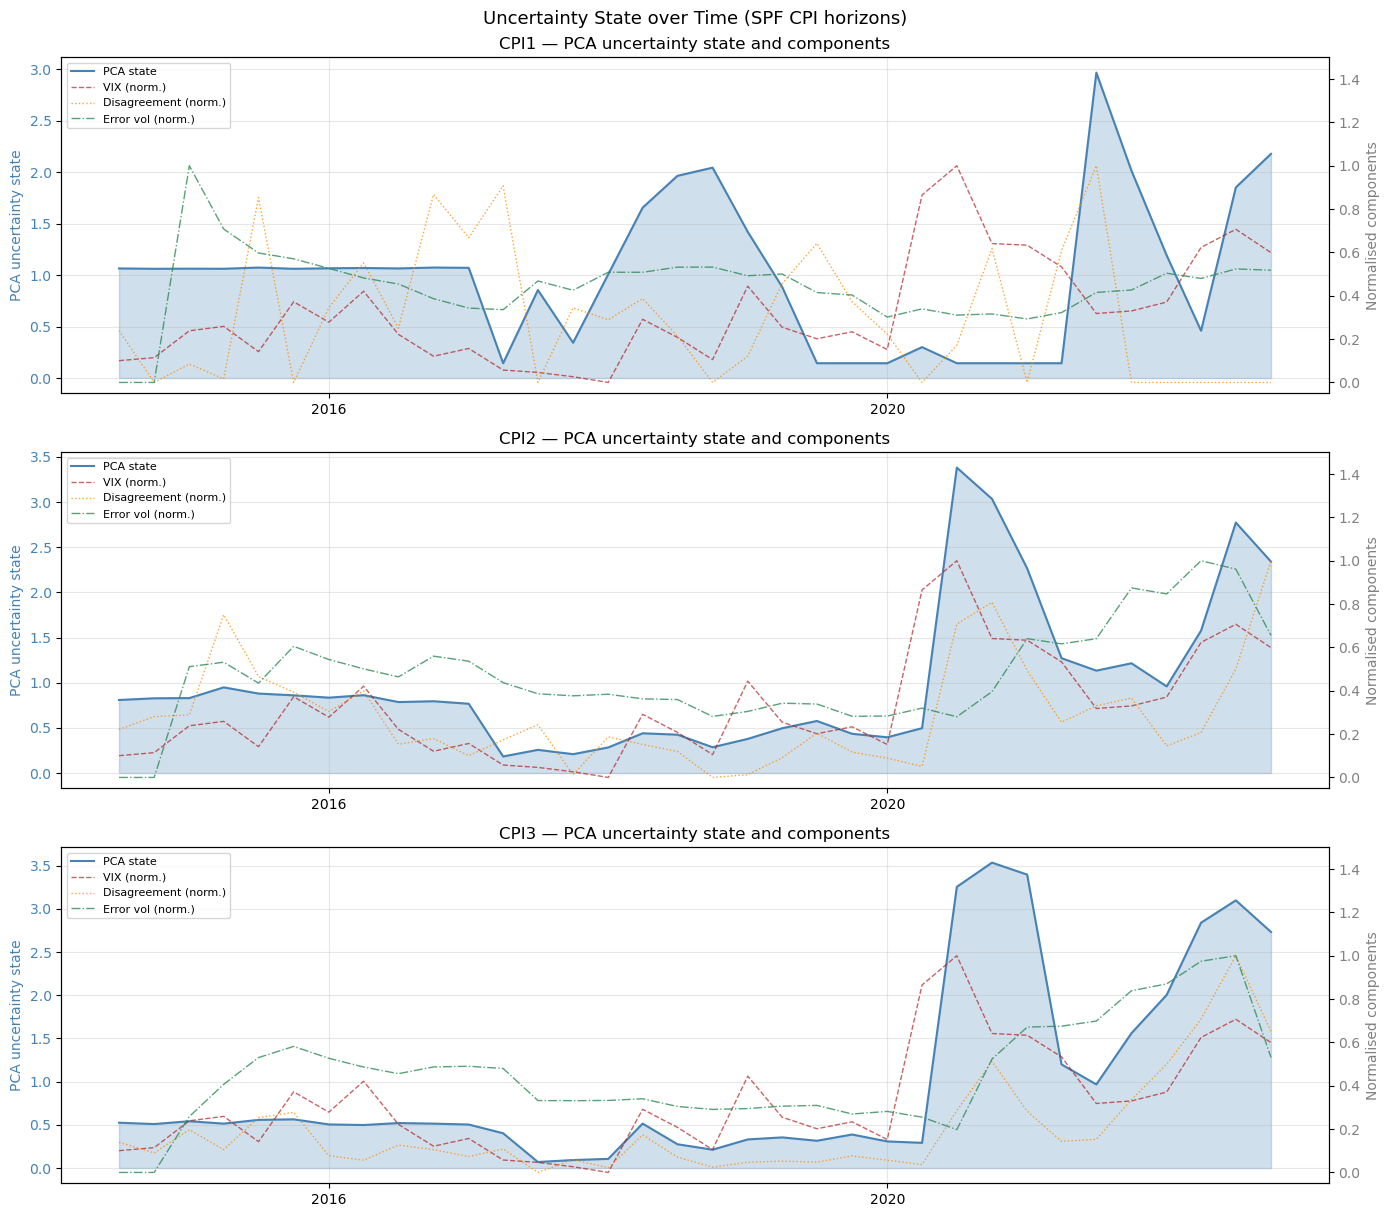

In [17]:
## ── Plot 1: State (uncertainty) over time ────────────────────────────────────
#
# Shows the PCA-derived uncertainty state alongside its components: VIX,
# cross-sectional disagreement, and rolling error volatility.
# High state ≈ high uncertainty → concentration methods apply more pull toward
# the equal-weight baseline.

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd

def _period_to_timestamp(periods):
    """Convert Period array/Series to Timestamps for matplotlib."""
    return pd.PeriodIndex(periods).to_timestamp(how='end')

def _norm01(s):
    """Normalise a series to [0, 1] for visual comparison."""
    lo, hi = s.min(), s.max()
    return (s - lo) / (hi - lo + 1e-12)

n_h = len(feasible)
fig, axes = plt.subplots(n_h, 1, figsize=(14, 4 * n_h), sharex=False)
if n_h == 1:
    axes = [axes]

for ax, h in zip(axes, feasible):
    sf = state_frames[h].copy()
    t  = _period_to_timestamp(sf['origin_period'])

    ax2 = ax.twinx()

    vix_n  = _norm01(sf['vix_q_mean'].ffill().fillna(0))
    dis_n  = _norm01(sf['disagreement'])
    vol_n  = _norm01(sf['error_vol_recent'].fillna(0))
    state  = sf['state_pca']

    ax.fill_between(t, 0, state, alpha=0.25, color='steelblue')
    ax.plot(t, state, color='steelblue', linewidth=1.5, label='PCA state')
    ax.set_ylabel('PCA uncertainty state', color='steelblue')
    ax.tick_params(axis='y', labelcolor='steelblue')

    ax2.plot(t, vix_n, color='firebrick', linewidth=1, linestyle='--', alpha=0.7, label='VIX (norm.)')
    ax2.plot(t, dis_n, color='darkorange', linewidth=1, linestyle=':', alpha=0.8, label='Disagreement (norm.)')
    ax2.plot(t, vol_n, color='seagreen',  linewidth=1, linestyle='-.', alpha=0.8, label='Error vol (norm.)')
    ax2.set_ylabel('Normalised components', color='grey')
    ax2.tick_params(axis='y', labelcolor='grey')
    ax2.set_ylim(-0.05, 1.5)

    ax.set_title(f'{h} — PCA uncertainty state and components', fontsize=12)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator(4))
    ax.grid(True, alpha=0.3)

    lines1, labs1 = ax.get_legend_handles_labels()
    lines2, labs2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labs1 + labs2, loc='upper left', fontsize=8)

plt.tight_layout()
plt.suptitle('Uncertainty State over Time (SPF CPI horizons)', y=1.01, fontsize=13)
plt.show()


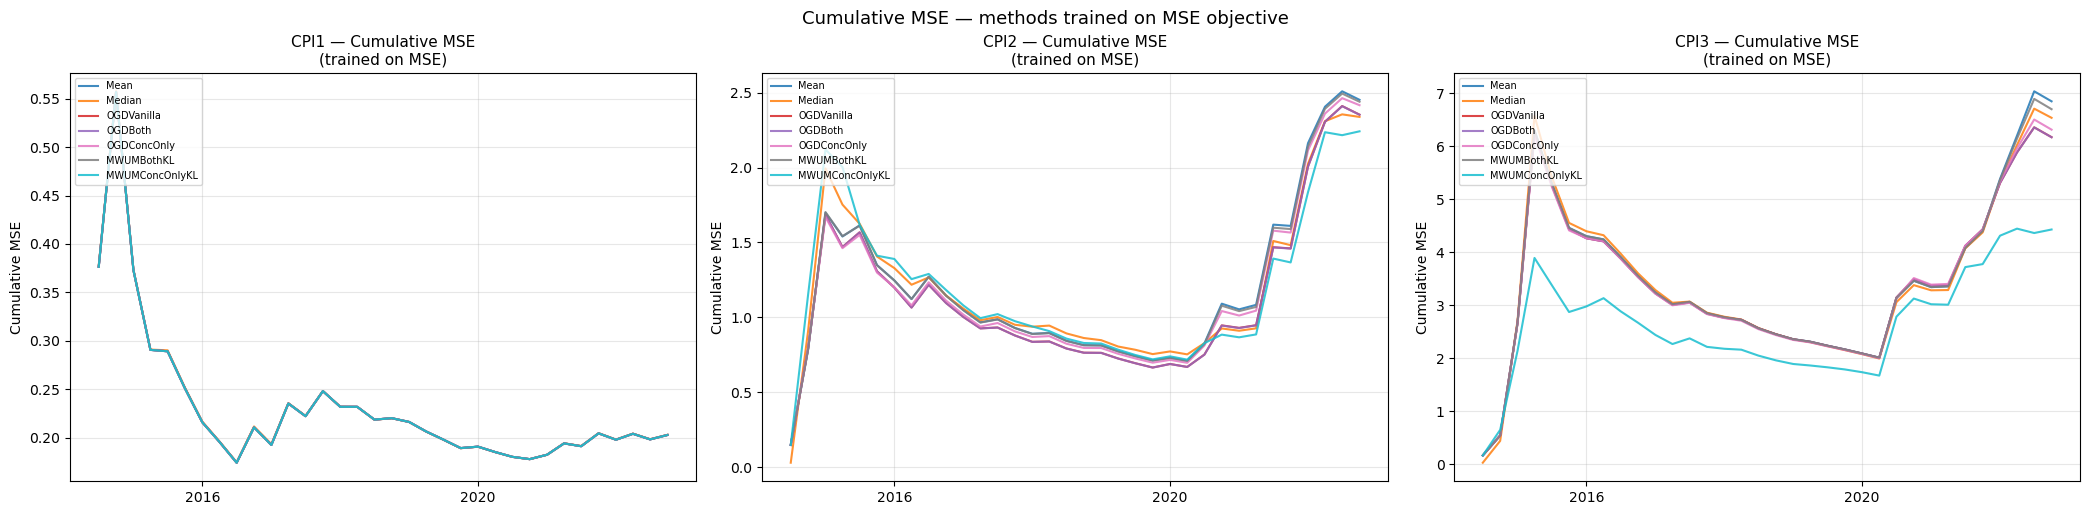

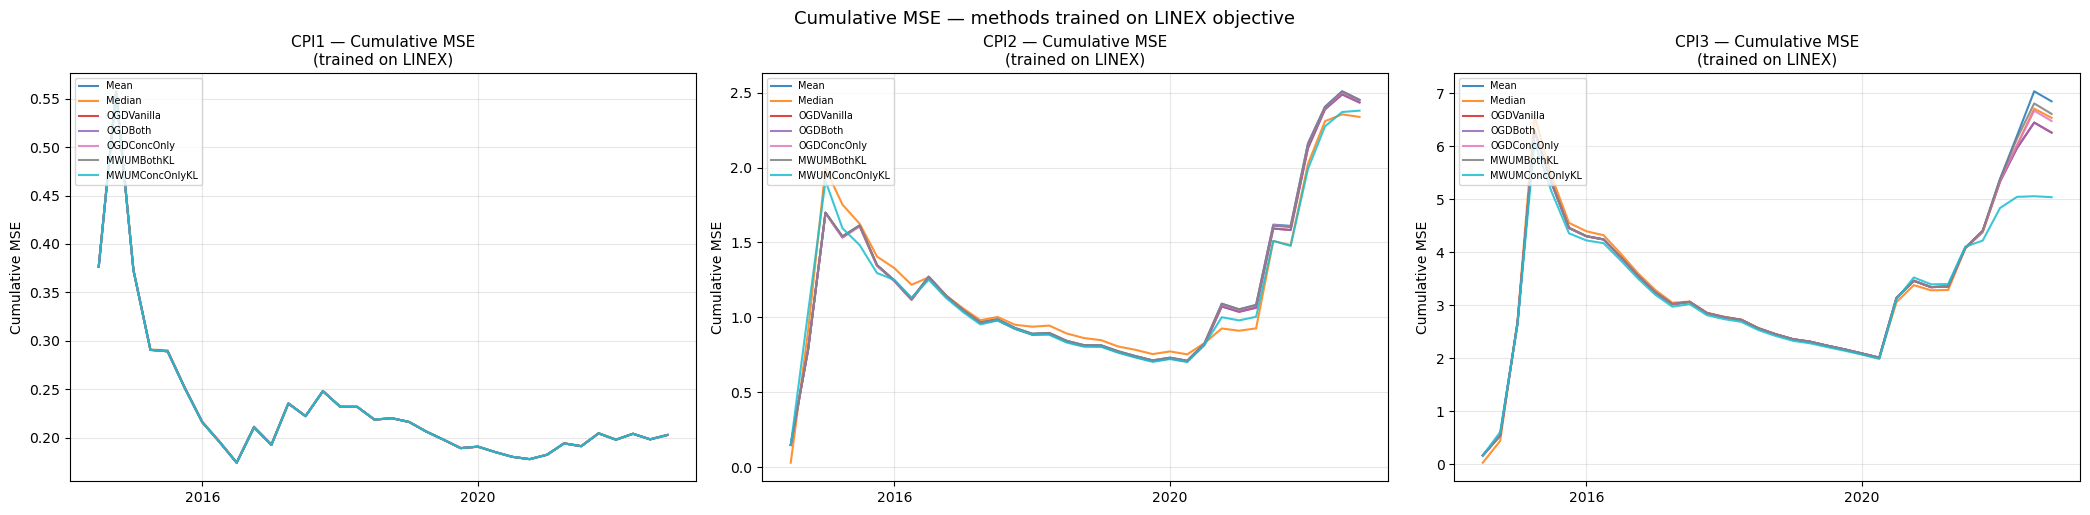

In [18]:
## ── Plot 2: Cumulative squared error over time ────────────────────────────────
#
# For each horizon, plot cumulative MSE of each method vs time.
# A method that gains ground during recessions / high-VIX periods shows
# that concentration control is valuable precisely when needed.
# Runs for both MSE and LINEX loss objectives.

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
from src.evaluation.m3_macro_experiment import build_models
import src.evaluation.optuna_tuning as ot_mod

def _period_to_timestamp(periods):
    return pd.PeriodIndex(periods).to_timestamp(how='end')

PLOT_METHODS = [
    'Mean', 'Median', 'OGDVanilla',
    'OGDBoth', 'OGDConcOnly',
    'MWUMBothKL', 'MWUMConcOnlyKL',
]
COLORS = plt.cm.tab10(np.linspace(0, 0.9, len(PLOT_METHODS)))
METHOD_COLOR = dict(zip(PLOT_METHODS, COLORS))

for loss_key in LOSS_SECTIONS:
    n_h = len(feasible)
    fig, axes = plt.subplots(1, n_h, figsize=(7 * n_h, 5), sharey=False)
    if n_h == 1:
        axes = [axes]

    for ax, h in zip(axes, feasible):
        mat_obj = mat_objects[h]
        y_h     = mat_obj['y']
        F_h     = mat_obj['F']
        state_h = state_frames[h]['state_pca']
        t_h     = _period_to_timestamp(mat_objects[h]['mat']['origin_period'])

        models = build_models(params_map=params_map, loss_name=loss_key, linex_a=LINEX_A)

        for mname, model in models.items():
            if mname not in PLOT_METHODS:
                continue
            needs_state = mname in ot_mod.STATE_METHODS
            result = model.run(F_h, y_h, s=state_h if needs_state else None)
            yhat   = np.asarray(result.yhat, dtype=float)
            sq_err = (y_h - yhat) ** 2
            cum_mse = np.cumsum(sq_err) / (np.arange(len(sq_err)) + 1)
            ax.plot(t_h, cum_mse, color=METHOD_COLOR[mname],
                    label=mname, linewidth=1.5, alpha=0.85)

        ax.set_title(f'{h} — Cumulative MSE\n(trained on {loss_key.upper()})', fontsize=11)
        ax.set_ylabel('Cumulative MSE')
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        ax.xaxis.set_major_locator(mdates.YearLocator(4))
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=7, loc='upper left')

    plt.tight_layout()
    plt.suptitle(f'Cumulative MSE — methods trained on {loss_key.upper()} objective',
                 y=1.02, fontsize=13)
    plt.show()


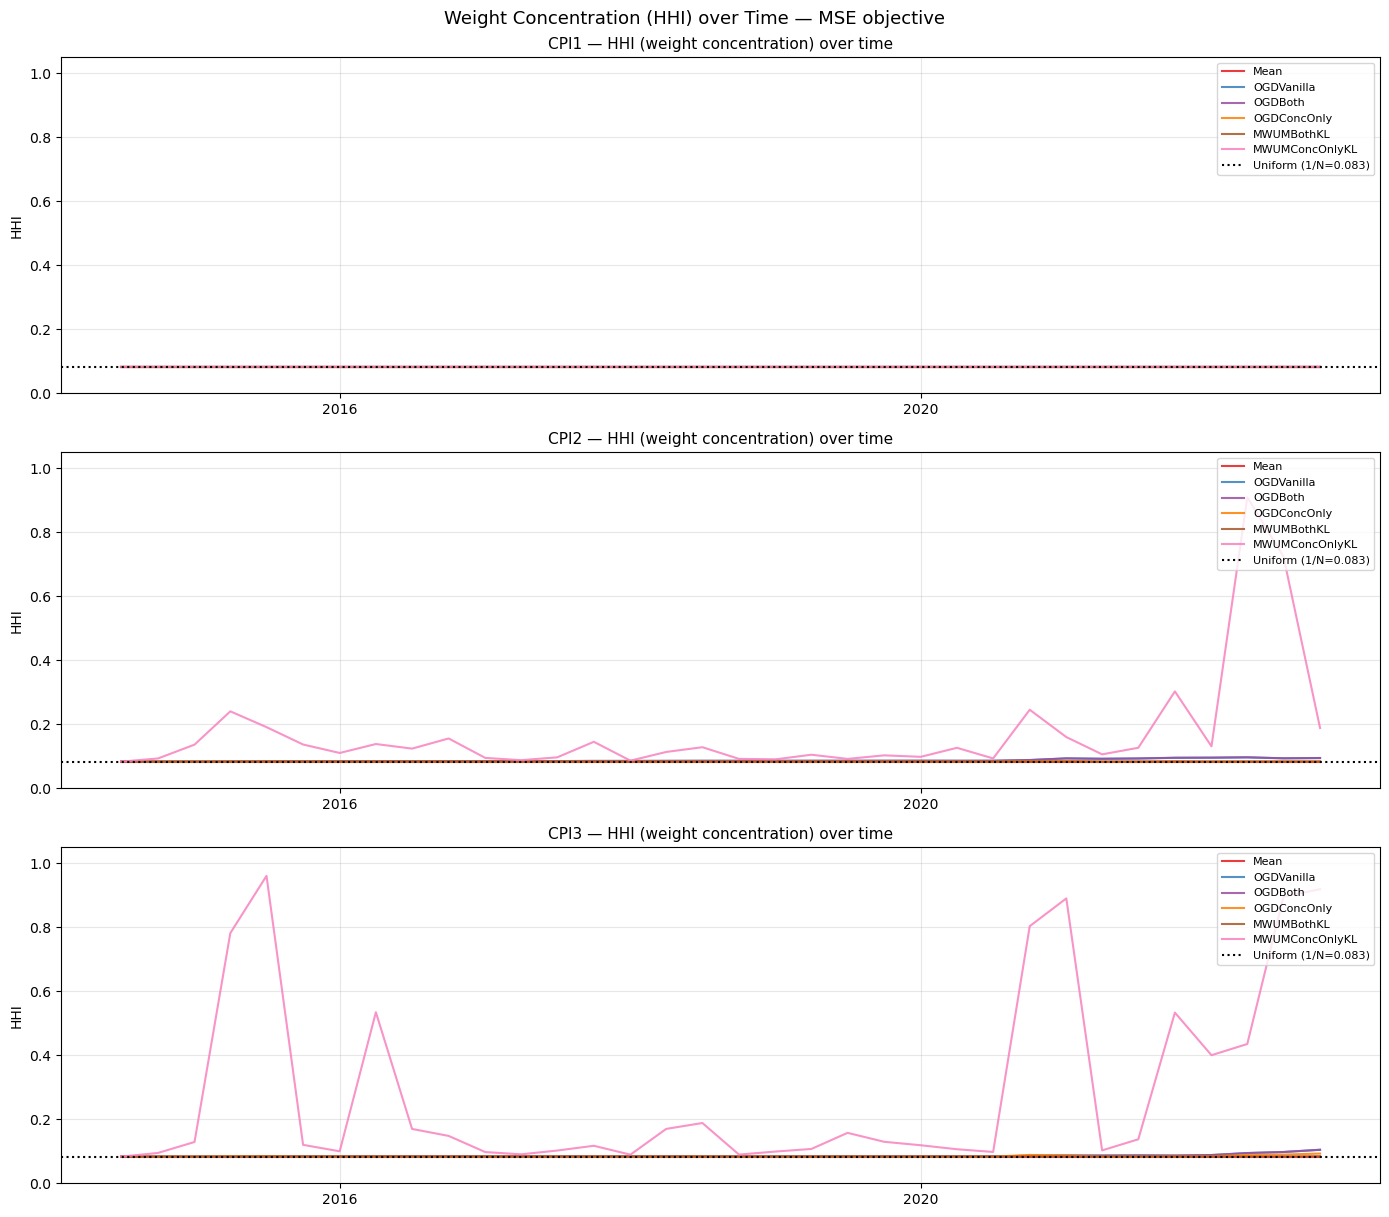

In [19]:
## ── Plot 3: HHI (weight concentration) over time ─────────────────────────────
#
# HHI = Σ w_i² ∈ [1/N, 1].  1/N = perfectly uniform; 1 = all mass on one expert.
# Concentration-penalised methods should stay near 1/N, especially during
# high-uncertainty periods.

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
from src.evaluation.evaluation_helpers import hhi_from_weights
from src.evaluation.m3_macro_experiment import build_models
import src.evaluation.optuna_tuning as ot_mod

def _period_to_timestamp(periods):
    return pd.PeriodIndex(periods).to_timestamp(how='end')

HHI_METHODS = ['Mean', 'OGDVanilla', 'OGDBoth', 'OGDConcOnly', 'MWUMBothKL', 'MWUMConcOnlyKL']
HHI_COLORS  = plt.cm.Set1(np.linspace(0, 0.85, len(HHI_METHODS)))
HHI_COLOR   = dict(zip(HHI_METHODS, HHI_COLORS))

loss_key = 'mse'
n_h = len(feasible)
fig, axes = plt.subplots(n_h, 1, figsize=(14, 4 * n_h), sharex=False)
if n_h == 1:
    axes = [axes]

for ax, h in zip(axes, feasible):
    mat_obj = mat_objects[h]
    y_h     = mat_obj['y']
    F_h     = mat_obj['F']
    state_h = state_frames[h]['state_pca']
    t_h     = _period_to_timestamp(mat_objects[h]['mat']['origin_period'])
    N       = F_h.shape[1]
    hhi_uniform = 1.0 / N

    models = build_models(params_map=params_map, loss_name=loss_key, linex_a=LINEX_A)

    for mname, model in models.items():
        if mname not in HHI_METHODS:
            continue
        needs_state = mname in ot_mod.STATE_METHODS
        result = model.run(F_h, y_h, s=state_h if needs_state else None)
        hhi_t  = np.asarray(hhi_from_weights(result.weights), dtype=float)
        ax.plot(t_h, hhi_t, color=HHI_COLOR[mname], label=mname,
                linewidth=1.5, alpha=0.85)

    ax.axhline(hhi_uniform, color='black', linestyle=':', linewidth=1.5,
               label=f'Uniform (1/N={hhi_uniform:.3f})')
    ax.set_title(f'{h} — HHI (weight concentration) over time', fontsize=11)
    ax.set_ylabel('HHI')
    ax.set_ylim(0, 1.05)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator(4))
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.suptitle('Weight Concentration (HHI) over Time — MSE objective', y=1.01, fontsize=13)
plt.show()


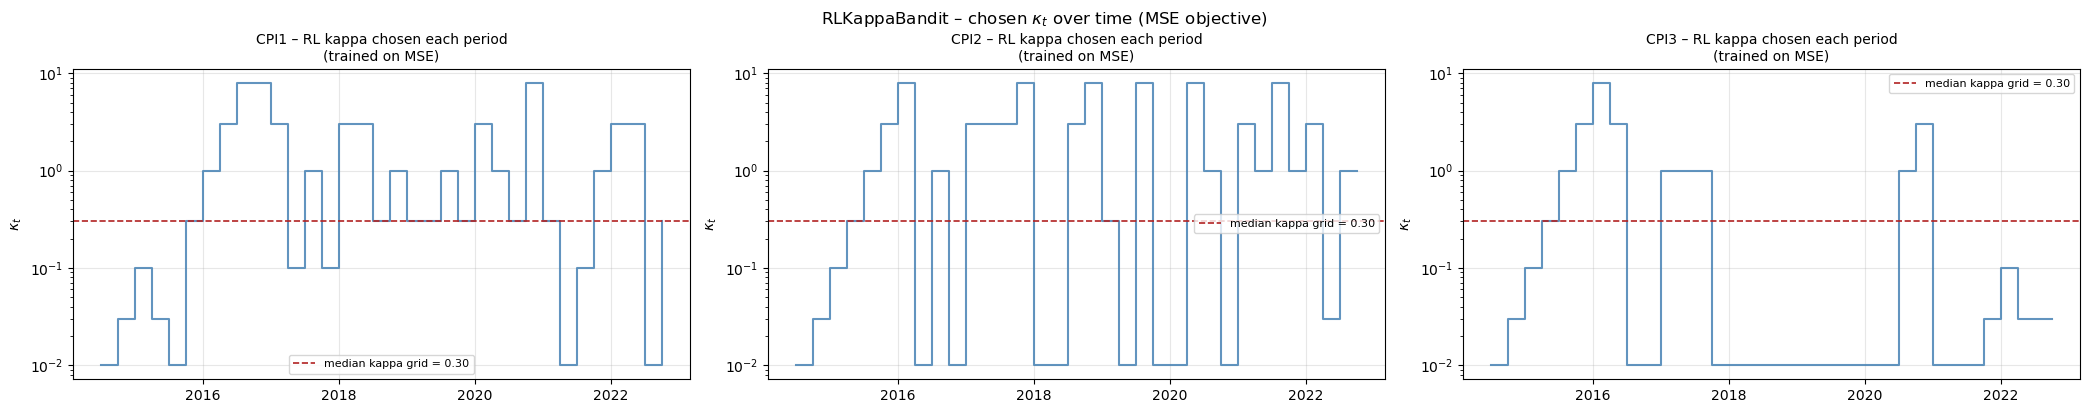

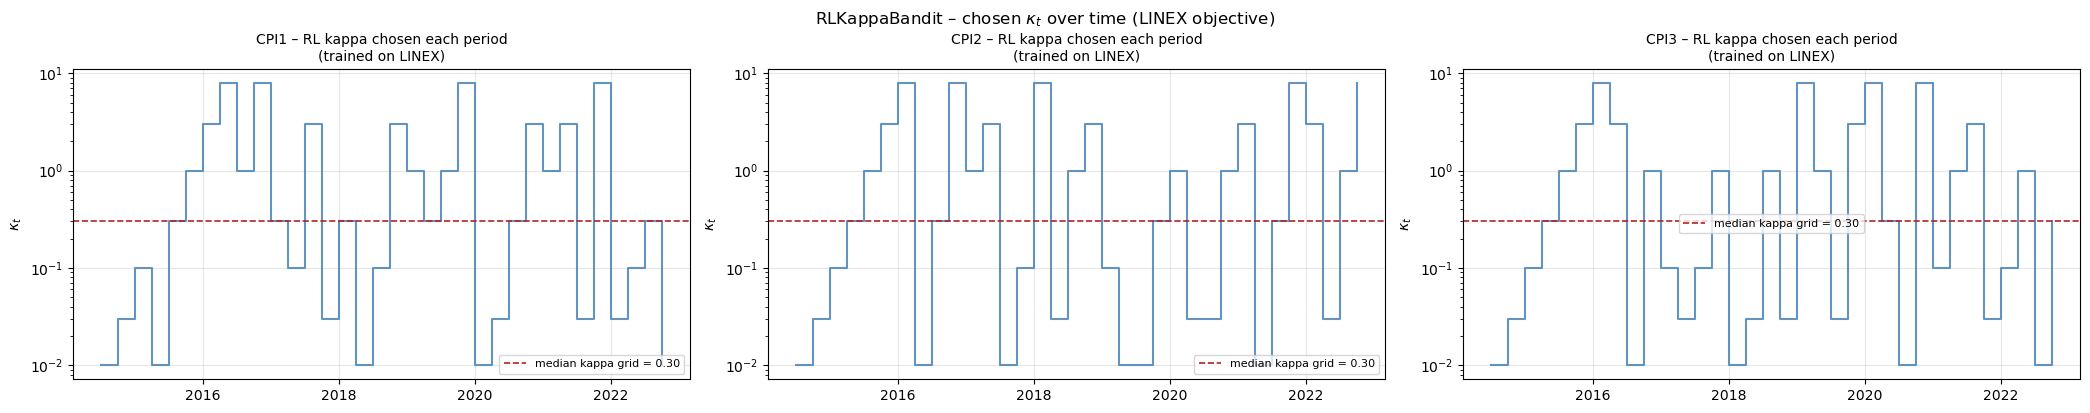

In [20]:
## ── Plot 6: RL kappa selection over time ─────────────────────────────────────
#
# Shows which kappa value the RLKappaBandit chose each period.
# If the agent learns that concentration is not valuable, kappa_t should trend
# toward the low end of the grid over time (i.e., near-zero kappa = ignore
# concentration penalty).  Conversely, a trend toward high kappa implies the
# agent is learning to concentrate.

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd

def _period_to_timestamp(periods):
    return pd.PeriodIndex(periods).to_timestamp(how='end')

diag_df = pd.DataFrame(diag_rows_spf)
kappa_rows = diag_df[diag_df["method"] == "RLKappaBandit"].copy()

if kappa_rows.empty:
    print("No RLKappaBandit diagnostic rows – skipping kappa plot.")
else:
    n_h = len(feasible)
    for loss_key in LOSS_SECTIONS:
        fig, axes = plt.subplots(1, n_h, figsize=(7 * n_h, 4), sharey=False)
        if n_h == 1:
            axes = [axes]
        for ax, h in zip(axes, feasible):
            sub = kappa_rows[
                (kappa_rows["horizon_name"] == h) & (kappa_rows["loss_section"] == loss_key)
            ].copy()
            if sub.empty:
                ax.set_title(f"{h} – no data")
                continue

            t_idx = sub["t"].astype(int).values
            kappa_t = sub["kappa"].values
            # Map t index back to timestamps via mat_objects
            origin_periods = mat_objects[h]["mat"]["origin_period"].values
            timestamps = _period_to_timestamp(origin_periods)

            ax.step(timestamps[t_idx], kappa_t, where="post",
                    color="steelblue", linewidth=1.5, alpha=0.85)
            ax.axhline(float(np.median(kappa_grid)), color="firebrick",
                       linestyle="--", linewidth=1.2, label=f"median kappa grid = {np.median(kappa_grid):.2f}")
            ax.set_title(f"{h} – RL kappa chosen each period\n(trained on {loss_key.upper()})", fontsize=10)
            ax.set_ylabel(r"$\kappa_t$")
            ax.set_yscale("log")
            ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
            ax.xaxis.set_major_locator(mdates.YearLocator(2))
            ax.grid(True, alpha=0.3)
            ax.legend(fontsize=8)

        plt.tight_layout()
        plt.suptitle(f"RLKappaBandit – chosen $\kappa_t$ over time ({loss_key.upper()} objective)",
                     y=1.02, fontsize=12)
        plt.show()


/tmp/ipykernel_8713/818114252.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap("tab10", n_actions)


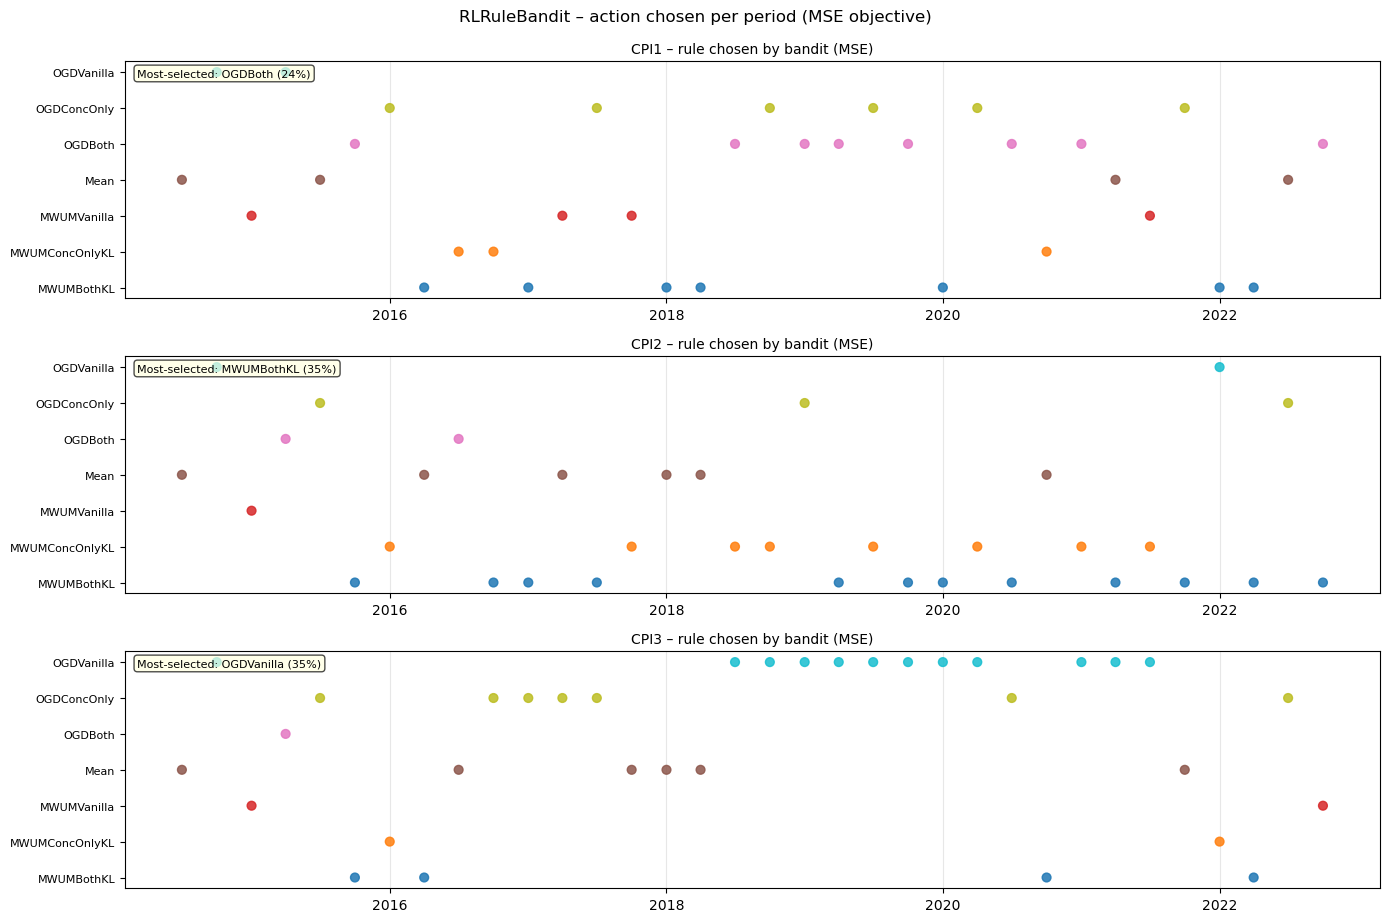

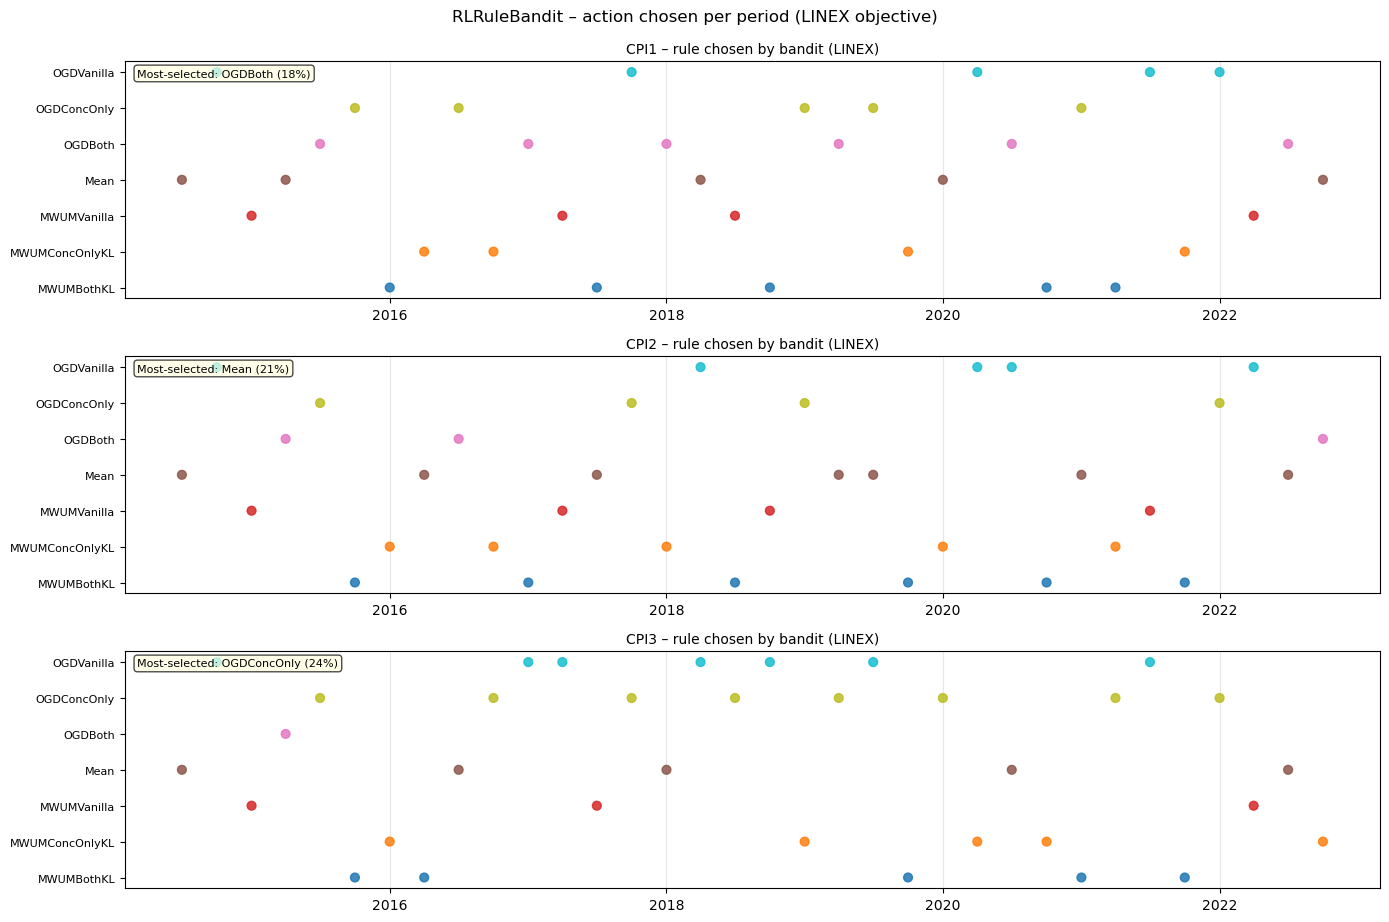

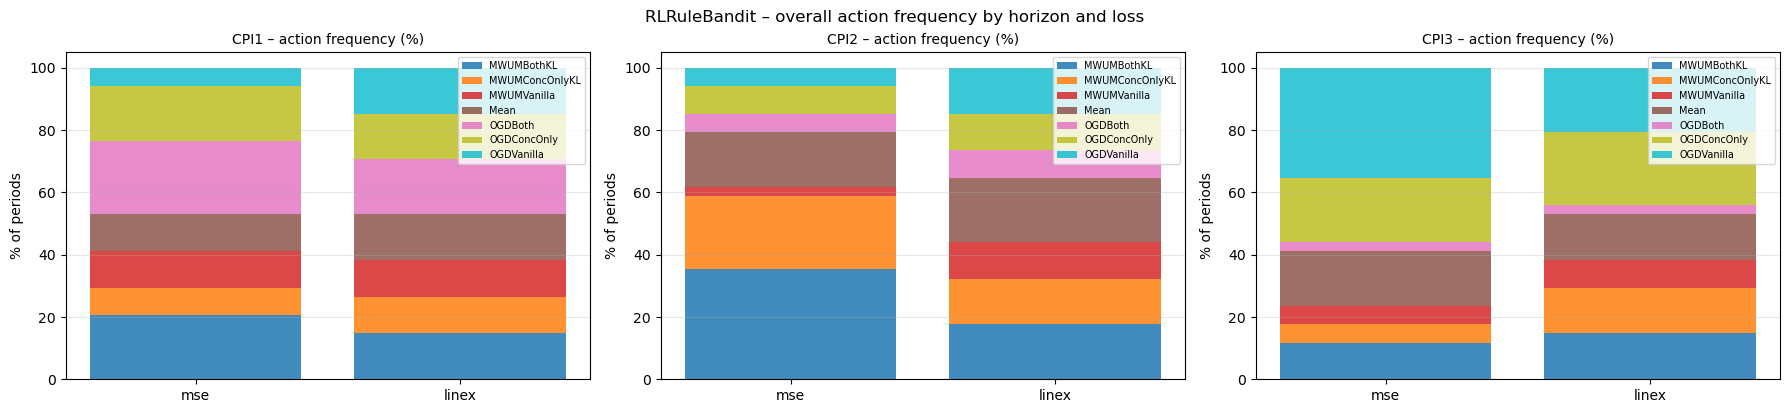

In [21]:
## ── Plot 7: RL rule-bandit action selection over time ────────────────────────
#
# Shows which ensemble rule the RuleSelectionBandit chose each period.
# If the agent learns over time, we expect it to increasingly select the
# rules that perform best on this dataset (e.g., Mean or MWUM if disagreement
# is low, or concentration methods when uncertainty is high).

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
from matplotlib.colors import BoundaryNorm
from matplotlib.cm import get_cmap

def _period_to_timestamp(periods):
    return pd.PeriodIndex(periods).to_timestamp(how='end')

diag_df = pd.DataFrame(diag_rows_spf)
rb_rows = diag_df[diag_df["method"] == "RLRuleBandit"].copy()

if rb_rows.empty:
    print("No RLRuleBandit diagnostic rows – skipping action plot.")
else:
    action_names_list = sorted(rb_rows["action_name"].unique().tolist())
    n_actions = len(action_names_list)
    name_to_idx = {n: i for i, n in enumerate(action_names_list)}
    cmap = get_cmap("tab10", n_actions)

    n_h = len(feasible)
    for loss_key in LOSS_SECTIONS:
        fig, axes = plt.subplots(n_h, 1, figsize=(14, 3 * n_h), sharex=False)
        if n_h == 1:
            axes = [axes]
        for ax, h in zip(axes, feasible):
            sub = rb_rows[
                (rb_rows["horizon_name"] == h) & (rb_rows["loss_section"] == loss_key)
            ].copy()
            if sub.empty:
                ax.set_title(f"{h} – no data")
                continue

            t_idx = sub["t"].astype(int).values
            act_idx = sub["action_name"].map(name_to_idx).values
            origin_periods = mat_objects[h]["mat"]["origin_period"].values
            timestamps = _period_to_timestamp(origin_periods)

            sc = ax.scatter(timestamps[t_idx], act_idx, c=act_idx,
                            cmap=cmap, vmin=-0.5, vmax=n_actions - 0.5,
                            s=40, alpha=0.85, zorder=3)
            ax.set_yticks(range(n_actions))
            ax.set_yticklabels(action_names_list, fontsize=8)
            ax.set_title(f"{h} – rule chosen by bandit ({loss_key.upper()})", fontsize=10)
            ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
            ax.xaxis.set_major_locator(mdates.YearLocator(2))
            ax.grid(True, alpha=0.3, axis="x")

            # Cumulative action frequency bar
            counts = np.bincount(act_idx, minlength=n_actions)
            top = action_names_list[np.argmax(counts)]
            ax.text(0.01, 0.97, f"Most-selected: {top} ({100*counts.max()/counts.sum():.0f}%)",
                    transform=ax.transAxes, fontsize=8, va="top",
                    bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.7))

        plt.tight_layout()
        plt.suptitle(f"RLRuleBandit – action chosen per period ({loss_key.upper()} objective)",
                     y=1.02, fontsize=12)
        plt.show()

    # Stacked bar: overall action frequency per horizon × loss
    fig, axes = plt.subplots(1, n_h, figsize=(6 * n_h, 4))
    if n_h == 1:
        axes = [axes]
    for ax, h in zip(axes, feasible):
        bottoms = np.zeros(len(LOSS_SECTIONS))
        for ai, aname in enumerate(action_names_list):
            heights = []
            for loss_key in LOSS_SECTIONS:
                sub = rb_rows[
                    (rb_rows["horizon_name"] == h) &
                    (rb_rows["loss_section"] == loss_key) &
                    (rb_rows["action_name"] == aname)
                ]
                total = rb_rows[
                    (rb_rows["horizon_name"] == h) & (rb_rows["loss_section"] == loss_key)
                ]
                pct = 100 * len(sub) / max(len(total), 1)
                heights.append(pct)
            ax.bar(LOSS_SECTIONS, heights, bottom=bottoms,
                   color=cmap(ai), label=aname, alpha=0.85)
            bottoms += np.array(heights)
        ax.set_title(f"{h} – action frequency (%)", fontsize=10)
        ax.set_ylabel("% of periods")
        ax.set_ylim(0, 105)
        ax.legend(fontsize=7, loc="upper right")
        ax.grid(True, alpha=0.3, axis="y")
    plt.tight_layout()
    plt.suptitle("RLRuleBandit – overall action frequency by horizon and loss", y=1.02, fontsize=12)
    plt.show()


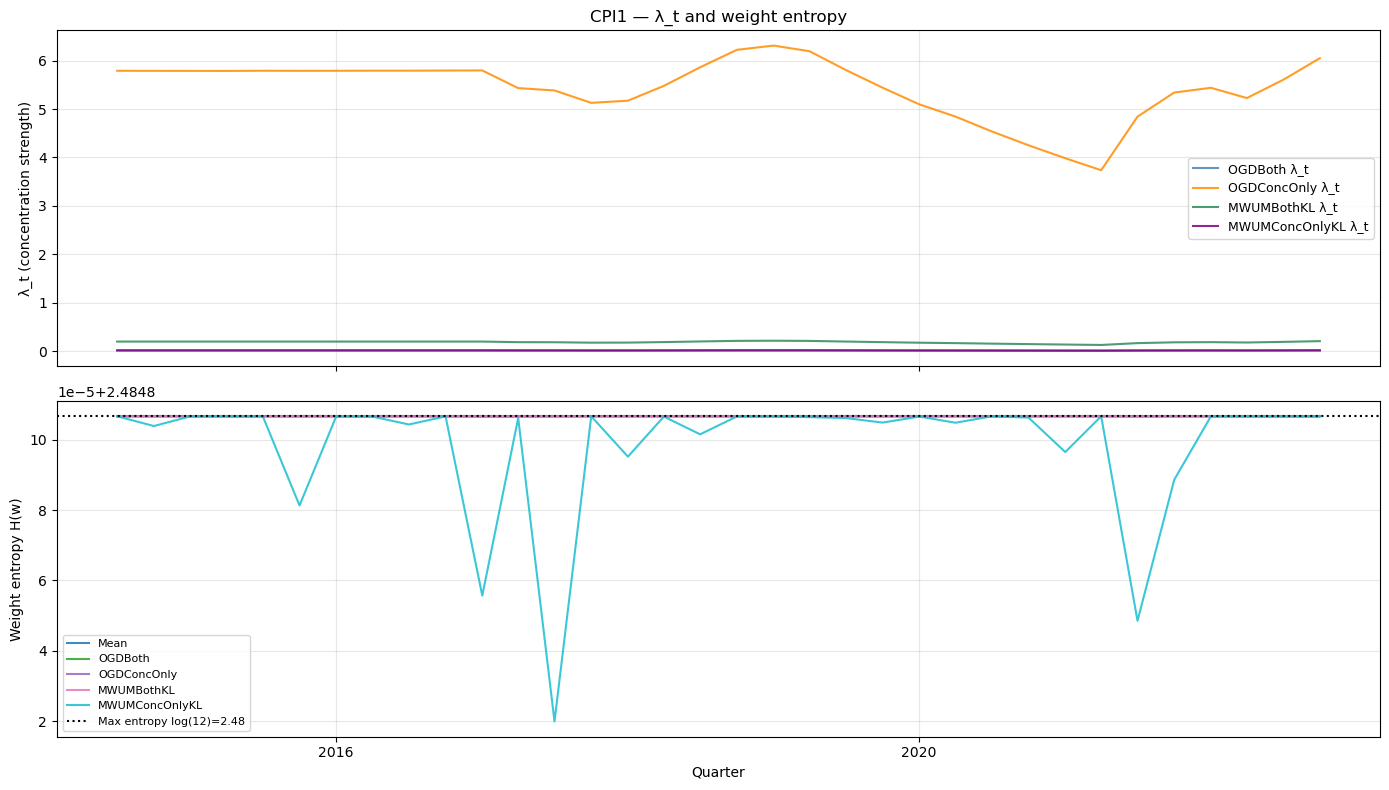

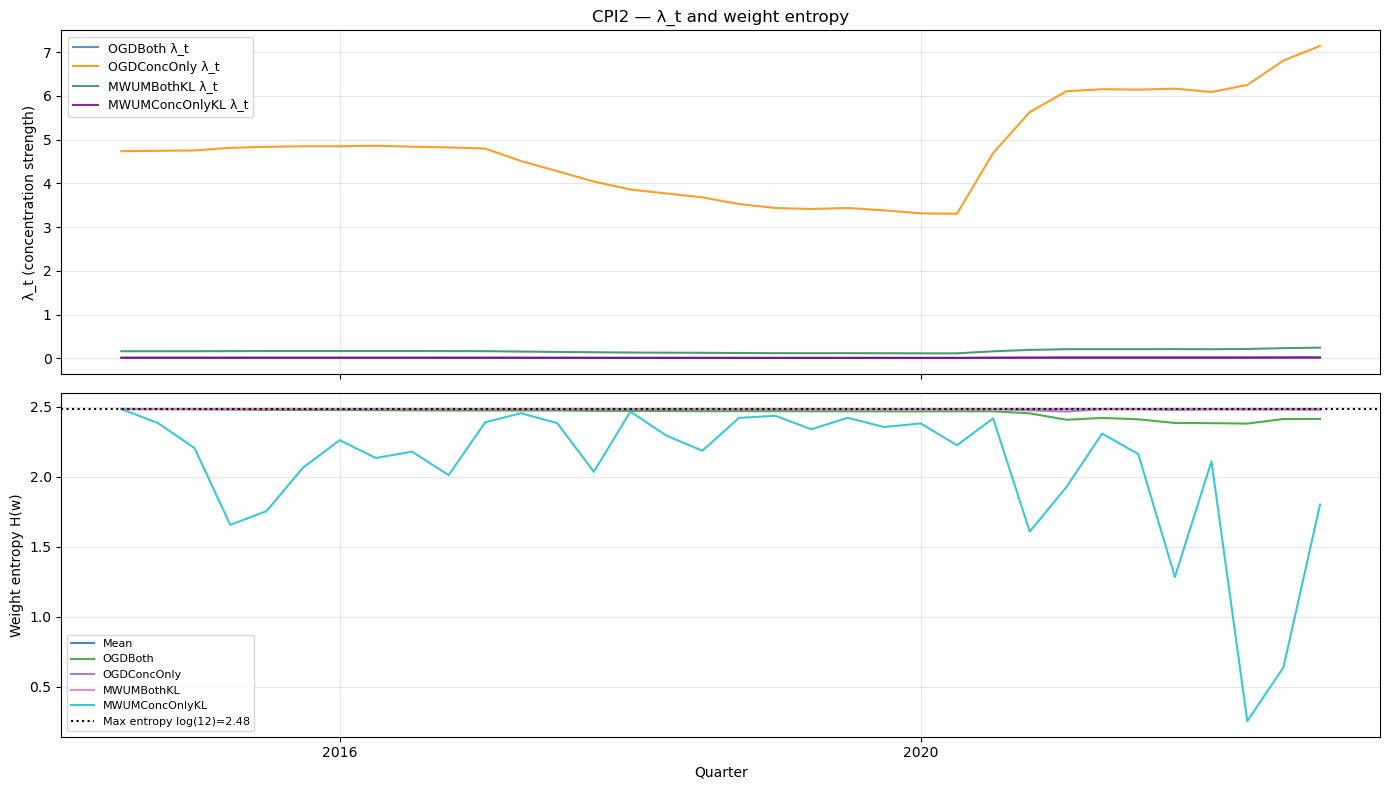

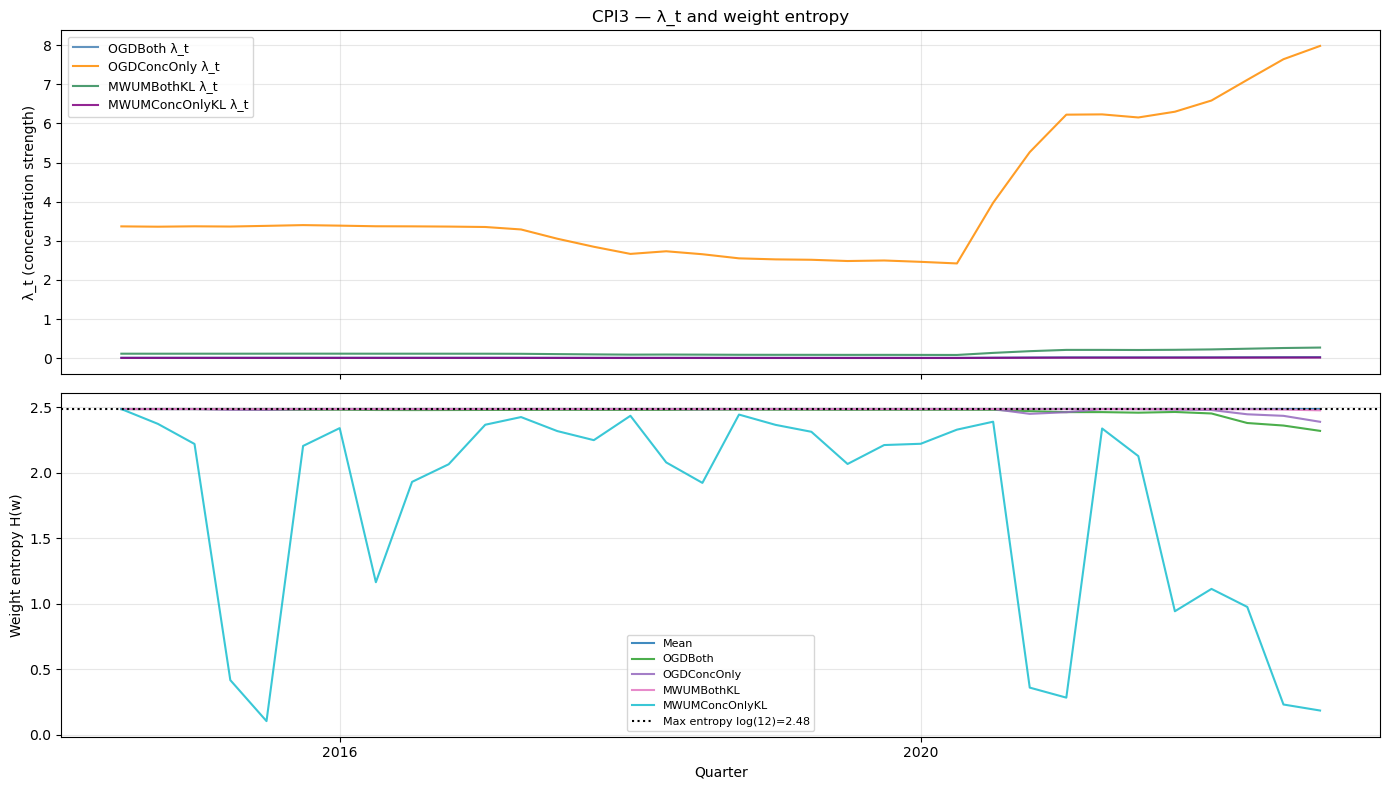

In [22]:
## ── Plot 4: λ_t and weight entropy ────────────────────────────────────────────
#
# Shows how λ_t = λ_min + κ·log(1 + s̃_t) evolves with the uncertainty state,
# and how weight entropy H(w) = -Σ w_i log(w_i) changes over time.
# Entropy = log(N) → uniform weights; Entropy → 0 → concentrated on one expert.
# Concentration penalty should push entropy upward during high-uncertainty periods.

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
from src.ensemblers.ensemblers import concentration_lambda, update_state_ema
from src.evaluation.m3_macro_experiment import build_models
import src.evaluation.optuna_tuning as ot_mod

def _period_to_timestamp(periods):
    return pd.PeriodIndex(periods).to_timestamp(how='end')

CONC_METHODS = ['OGDBoth', 'OGDConcOnly', 'MWUMBothKL', 'MWUMConcOnlyKL']
LCOLORS = dict(zip(CONC_METHODS, ['steelblue', 'darkorange', 'seagreen', 'purple']))

for h in feasible:
    mat_obj = mat_objects[h]
    y_h     = mat_obj['y']
    F_h     = mat_obj['F']
    state_h = state_frames[h]['state_pca']
    t_h     = _period_to_timestamp(mat_objects[h]['mat']['origin_period'])
    N       = F_h.shape[1]

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

    # Panel A: λ_t for each concentration method
    for mname in CONC_METHODS:
        if mname not in params_map:
            continue
        kappa     = float(params_map[mname].get('kappa', 0.8))
        rho       = float(params_map[mname].get('state_smoothing', 0.9))
        lam_floor = float(params_map[mname].get('lambda_min', 1e-6))
        state_ema = None
        lam_series = []
        for t_idx in range(len(state_h)):
            state_ema = update_state_ema(state_ema, float(state_h[t_idx]), rho)
            lam_series.append(concentration_lambda(kappa, state_ema, lam_floor))
        ax1.plot(t_h, lam_series, color=LCOLORS[mname], label=f'{mname} λ_t',
                 linewidth=1.5, alpha=0.85)

    ax1.set_ylabel('λ_t (concentration strength)')
    ax1.set_title(f'{h} — λ_t and weight entropy', fontsize=12)
    ax1.grid(True, alpha=0.3)
    ax1.legend(fontsize=9)

    # Panel B: weight entropy H(w) = -Σ w_i log(w_i)
    models = build_models(params_map=params_map, loss_name='mse', linex_a=LINEX_A)
    ent_methods = ['Mean', 'OGDBoth', 'OGDConcOnly', 'MWUMBothKL', 'MWUMConcOnlyKL']
    ecols = dict(zip(ent_methods, plt.cm.tab10(np.linspace(0, 0.9, len(ent_methods)))))

    for mname, model in models.items():
        if mname not in ent_methods:
            continue
        needs_state = mname in ot_mod.STATE_METHODS
        result = model.run(F_h, y_h, s=state_h if needs_state else None)
        W = result.weights
        W_safe = np.clip(W, 1e-300, None)
        H = -np.sum(W_safe * np.log(W_safe), axis=1)
        ax2.plot(t_h, H, color=ecols[mname], label=mname, linewidth=1.5, alpha=0.85)

    ax2.axhline(np.log(N), color='black', linestyle=':', linewidth=1.5,
                label=f'Max entropy log({N})={np.log(N):.2f}')
    ax2.set_ylabel('Weight entropy H(w)')
    ax2.set_xlabel('Quarter')
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax2.xaxis.set_major_locator(mdates.YearLocator(4))
    ax2.grid(True, alpha=0.3)
    ax2.legend(fontsize=8)

    plt.tight_layout()
    plt.show()


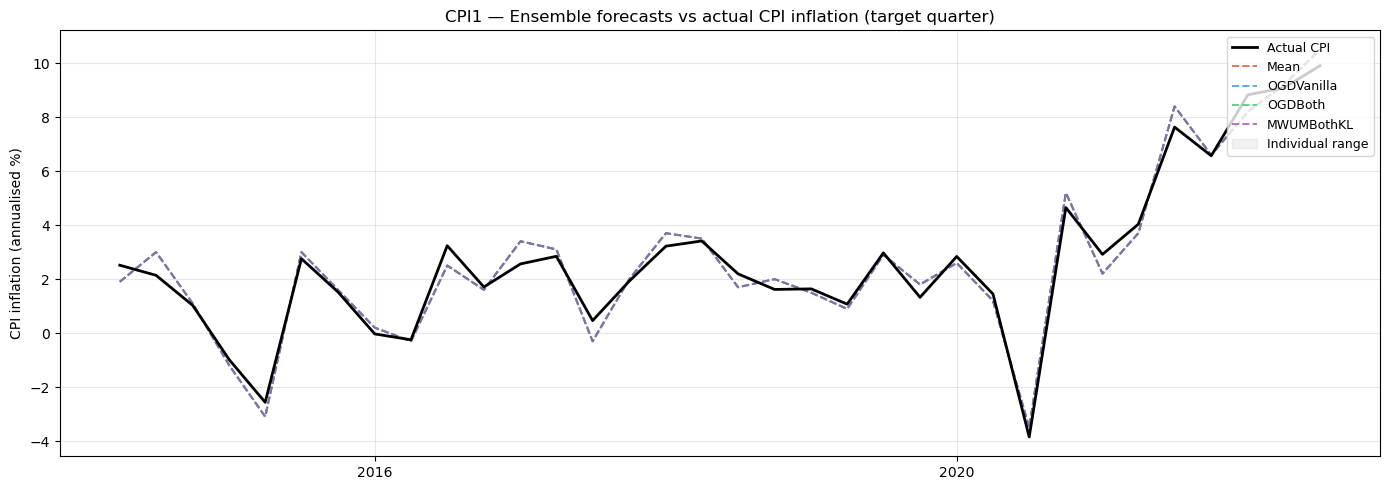

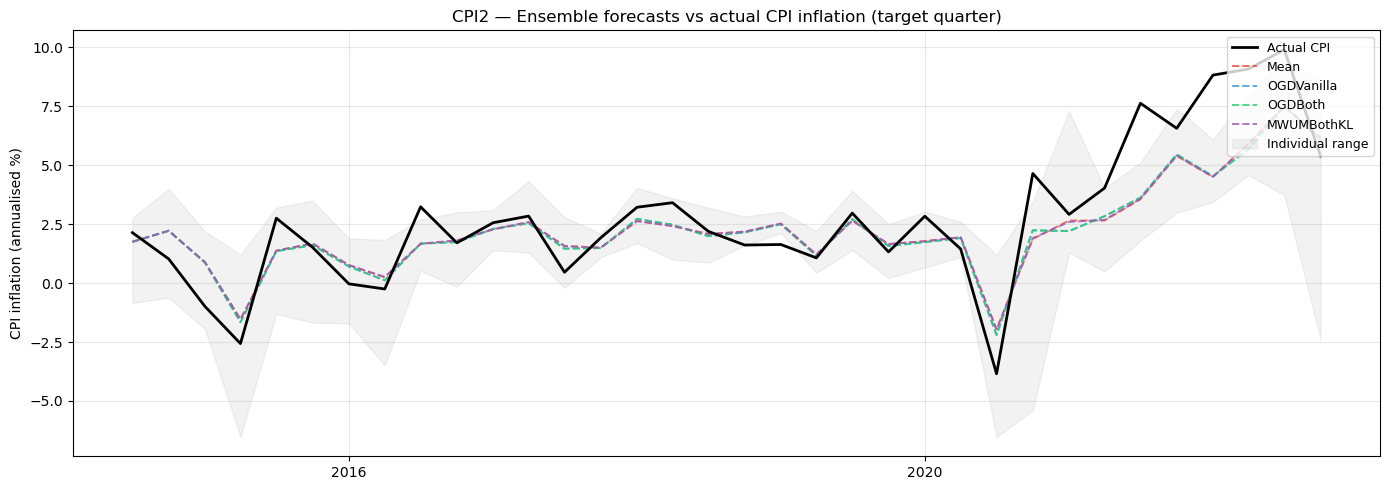

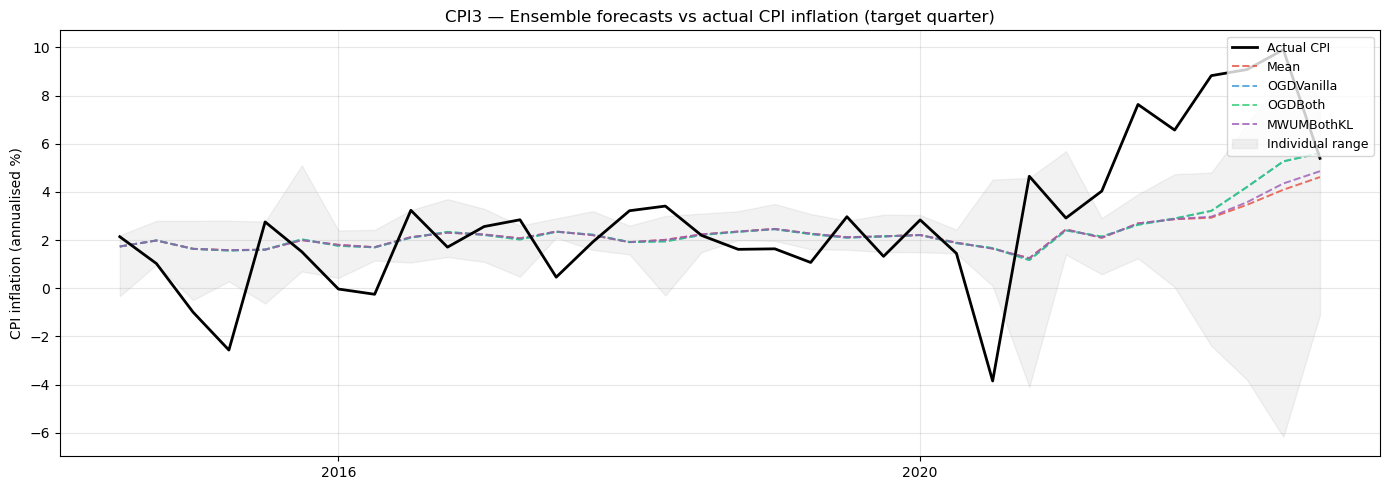

In [23]:
## ── Plot 5: Ensemble forecasts vs actual CPI ─────────────────────────────────
#
# For each horizon, plot actual CPI alongside forecasts from selected methods.
# The grey band shows the min-max spread of individual forecasters.

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
from src.evaluation.m3_macro_experiment import build_models
import src.evaluation.optuna_tuning as ot_mod

def _period_to_timestamp(periods):
    return pd.PeriodIndex(periods).to_timestamp(how='end')

SHOW_METHODS = ['Mean', 'OGDVanilla', 'OGDBoth', 'MWUMBothKL']
FC_COLORS    = dict(zip(SHOW_METHODS, ['#E74C3C', '#3498DB', '#2ECC71', '#9B59B6']))

for h in feasible:
    mat_obj = mat_objects[h]
    y_h     = mat_obj['y']
    F_h     = mat_obj['F']
    state_h = state_frames[h]['state_pca']
    t_h     = _period_to_timestamp(mat_objects[h]['mat']['target_period'])

    fig, ax = plt.subplots(figsize=(14, 5))

    ax.plot(t_h, y_h, color='black', linewidth=2.0, label='Actual CPI', zorder=5)

    models = build_models(params_map=params_map, loss_name='mse', linex_a=LINEX_A)
    for mname, model in models.items():
        if mname not in SHOW_METHODS:
            continue
        needs_state = mname in ot_mod.STATE_METHODS
        result = model.run(F_h, y_h, s=state_h if needs_state else None)
        ax.plot(t_h, result.yhat, color=FC_COLORS[mname], linewidth=1.4,
                linestyle='--', alpha=0.8, label=mname)

    F_min = F_h.min(axis=1)
    F_max = F_h.max(axis=1)
    ax.fill_between(t_h, F_min, F_max, alpha=0.1, color='grey', label='Individual range')

    ax.set_title(f'{h} — Ensemble forecasts vs actual CPI inflation (target quarter)', fontsize=12)
    ax.set_ylabel('CPI inflation (annualised %)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator(4))
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9, loc='upper right')
    plt.tight_layout()
    plt.show()


## ── Interpretation Deep-Dive: Ensemble Power, Diversity, and State Value ──

This section adds three diagnostics with interpretation inline:
1. **Forecaster diversity / ensemble headroom** (if forecasters are nearly identical, equal-weight-like outcomes are expected).
2. **State informativeness** (does the uncertainty state predict when forecasting is hard?).
3. **Concentration penalty value** (does using the state improve concentration methods vs flat-state and vanilla baselines?).


In [ ]:
import numpy as np
import pandas as pd

from src.evaluation.m3_macro_experiment import build_models
from src.evaluation.evaluation_helpers import mse, linex_loss
import src.evaluation.optuna_tuning as ot_mod

def _obj(y, yhat, loss_key, linex_a):
    if loss_key == 'mse':
        return float(mse(y, yhat))
    return float(linex_loss(y, yhat, a=linex_a))

# ------------------------------------------------------------------
# 1) Forecaster diversity and theoretical ensemble headroom
# ------------------------------------------------------------------
div_rows = []
for h in feasible:
    mat_obj = mat_objects[h]
    y = np.asarray(mat_obj['y'], dtype=float)
    F = np.asarray(mat_obj['F'], dtype=float)

    corr = np.corrcoef(F, rowvar=False)
    iu = np.triu_indices_from(corr, k=1)
    pair_corr = corr[iu] if len(iu[0]) else np.array([np.nan])

    consensus = F.mean(axis=1)
    indiv_mse = np.array([mse(y, F[:, i]) for i in range(F.shape[1])], dtype=float)
    mean_mse = float(mse(y, consensus))
    best_mse = float(np.min(indiv_mse))
    headroom_pct = float(100.0 * (mean_mse - best_mse) / max(abs(best_mse), 1e-12))

    div_rows.append({
        'horizon': h,
        'n_obs': int(len(y)),
        'n_forecasters': int(F.shape[1]),
        'pair_corr_mean': float(np.nanmean(pair_corr)),
        'pair_corr_min': float(np.nanmin(pair_corr)),
        'pair_corr_max': float(np.nanmax(pair_corr)),
        'cross_sectional_std_mean': float(np.mean(np.std(F, axis=1))),
        'mean_mse': mean_mse,
        'best_individual_mse': best_mse,
        'headroom_best_vs_mean_pct': headroom_pct,
    })

div_df = pd.DataFrame(div_rows).sort_values('horizon').reset_index(drop=True)
print('=' * 80)
print('DIAGNOSTIC 1 — FORECASTER DIVERSITY / ENSEMBLE HEADROOM')
print('=' * 80)
display(div_df.round(6))

for _, r in div_df.iterrows():
    if r['pair_corr_mean'] > 0.995:
        msg = 'very low diversity (near-collinear forecasters): equal-weight-like behavior is expected.'
    elif r['pair_corr_mean'] > 0.98:
        msg = 'high similarity among forecasters: moderate headroom for adaptive weighting.'
    else:
        msg = 'meaningful diversity present: adaptive ensembling should have room to differentiate.'
    print(f"[{r['horizon']}] {msg} Headroom(best vs mean) = {r['headroom_best_vs_mean_pct']:.3f}%")

# ------------------------------------------------------------------
# 2) Is the uncertainty state informative about forecast difficulty?
# ------------------------------------------------------------------
state_rows = []
for h in feasible:
    mat_obj = mat_objects[h]
    y = np.asarray(mat_obj['y'], dtype=float)
    F = np.asarray(mat_obj['F'], dtype=float)
    sf = state_frames[h].copy().reset_index(drop=True)

    t = min(len(y), len(sf))
    y_t = y[:t]
    F_t = F[:t, :]
    sf = sf.iloc[:t].copy()

    consensus = F_t.mean(axis=1)
    abs_err = np.abs(y_t - consensus)

    # Use available components, robust to missing VIX periods
    features = {
        'state_pca': sf['state_pca'],
        'disagreement': sf['disagreement'],
        'error_vol_recent': sf['error_vol_recent'],
        'vix_q_mean': sf['vix_q_mean'],
    }

    for name, s in features.items():
        ser = pd.Series(s, dtype=float)
        ae = pd.Series(abs_err, dtype=float)
        mask = ser.notna() & ae.notna()
        if mask.sum() < 8:
            continue
        p_corr = float(ae[mask].corr(ser[mask], method='pearson'))
        s_corr = float(ae[mask].corr(ser[mask], method='spearman'))
        state_rows.append({
            'horizon': h,
            'feature': name,
            'n': int(mask.sum()),
            'corr_abs_err_pearson': p_corr,
            'corr_abs_err_spearman': s_corr,
        })

    # Regime split using state median
    state = np.asarray(sf['state_pca'], dtype=float)
    med = float(np.nanmedian(state))
    hi = state >= med
    lo = state < med
    if np.any(hi) and np.any(lo):
        hi_err = float(np.nanmean(abs_err[hi]))
        lo_err = float(np.nanmean(abs_err[lo]))
        print(f"[{h}] Mean |consensus error| in HIGH-state vs LOW-state: {hi_err:.5f} vs {lo_err:.5f} (ratio={hi_err/max(lo_err,1e-12):.3f})")

state_df = pd.DataFrame(state_rows).sort_values(['horizon', 'feature']).reset_index(drop=True)
print('\n' + '=' * 80)
print('DIAGNOSTIC 2 — STATE INFORMATIVENESS')
print('=' * 80)
display(state_df.round(5))

# ------------------------------------------------------------------
# 3) Value of concentration penalties and state adaptation
# ------------------------------------------------------------------
concentration_methods = ['OGDBoth', 'OGDConcOnly', 'MWUMBothKL', 'MWUMConcOnlyKL']
baseline_map = {
    'OGDBoth': 'OGDVanilla',
    'OGDConcOnly': 'OGDVanilla',
    'MWUMBothKL': 'MWUMVanilla',
    'MWUMConcOnlyKL': 'MWUMVanilla',
}

conc_rows = []
for h in feasible:
    mat_obj = mat_objects[h]
    y = np.asarray(mat_obj['y'], dtype=float)
    F = np.asarray(mat_obj['F'], dtype=float)
    s = np.asarray(state_frames[h]['state_pca'], dtype=float)[:len(y)]

    for loss_key in LOSS_SECTIONS:
        models = build_models(params_map=params_map, loss_name=loss_key, linex_a=LINEX_A)

        for m in concentration_methods:
            if m not in models:
                continue

            res_state = models[m].run(F, y, s=s)
            res_flat  = models[m].run(F, y, s=np.ones_like(s))

            bname = baseline_map[m]
            res_base = models[bname].run(F, y, s=None)

            obj_state = _obj(y, res_state.yhat, loss_key, LINEX_A)
            obj_flat  = _obj(y, res_flat.yhat,  loss_key, LINEX_A)
            obj_base  = _obj(y, res_base.yhat,  loss_key, LINEX_A)

            hhi_t = np.sum(np.asarray(res_state.weights, dtype=float) ** 2, axis=1)
            eff_n_t = 1.0 / np.maximum(hhi_t, 1e-12)

            med = float(np.nanmedian(s))
            hi = s >= med
            lo = s < med

            lam = np.asarray(res_state.meta.get('lambda', np.full_like(s, np.nan)), dtype=float).reshape(-1)
            corr_state_lambda = float(pd.Series(s).corr(pd.Series(lam), method='spearman')) if np.isfinite(lam).any() else np.nan

            conc_rows.append({
                'horizon': h,
                'loss': loss_key,
                'method': m,
                'baseline_method': bname,
                'objective_state': obj_state,
                'objective_flat_state': obj_flat,
                'objective_baseline': obj_base,
                'gain_state_vs_flat': obj_flat - obj_state,
                'gain_state_vs_baseline': obj_base - obj_state,
                'avg_hhi': float(np.mean(hhi_t)),
                'avg_effective_n': float(np.mean(eff_n_t)),
                'effective_n_low_state': float(np.mean(eff_n_t[lo])) if np.any(lo) else np.nan,
                'effective_n_high_state': float(np.mean(eff_n_t[hi])) if np.any(hi) else np.nan,
                'state_lambda_spearman': corr_state_lambda,
            })

conc_df = pd.DataFrame(conc_rows).sort_values(['loss', 'horizon', 'method']).reset_index(drop=True)
print('\n' + '=' * 80)
print('DIAGNOSTIC 3 — CONCENTRATION + STATE VALUE')
print('=' * 80)
display(conc_df.round(6))

summary = conc_df.groupby(['loss', 'method'], as_index=False).agg(
    mean_gain_state_vs_flat=('gain_state_vs_flat', 'mean'),
    mean_gain_state_vs_baseline=('gain_state_vs_baseline', 'mean'),
    mean_hhi=('avg_hhi', 'mean'),
    mean_effective_n=('avg_effective_n', 'mean'),
    mean_state_lambda_spearman=('state_lambda_spearman', 'mean'),
)

print('\nInterpretation summary (positive gain = better):')
display(summary.round(6))

for _, r in summary.iterrows():
    ls = r['loss']
    m = r['method']
    g1 = r['mean_gain_state_vs_flat']
    g2 = r['mean_gain_state_vs_baseline']
    if g1 > 0 and g2 > 0:
        txt = 'state-aware concentration appears useful and beats vanilla on average.'
    elif g1 > 0 and g2 <= 0:
        txt = 'state helps this concentration method, but it still does not beat vanilla overall.'
    else:
        txt = 'little evidence this concentration setup adds value for this loss setting.'
    print(f"[{ls.upper()}][{m}] {txt} (gain vs flat={g1:.6f}, gain vs baseline={g2:.6f}, effN={r['mean_effective_n']:.3f})")


In [24]:
## ── Persist outputs ───────────────────────────────────────────────────────────
from pathlib import Path
from src.evaluation.m3_macro_experiment import write_csv
import pandas as pd

OUT_DIR = PROJECT_ROOT / 'analyses' / 'results' / 'spf'
OUT_DIR.mkdir(parents=True, exist_ok=True)

write_csv(OUT_DIR / 'spf_cpi123_detailed.csv',              detailed_rows_spf)
write_csv(OUT_DIR / 'spf_cpi123_policy_diagnostics.csv',    diag_rows_spf)
write_csv(OUT_DIR / 'spf_cpi123_summary_by_horizon.csv',    summary_rows_spf_h)
write_csv(OUT_DIR / 'spf_cpi123_summary_overall.csv',       summary_rows_spf_overall)

for h, sdf in state_frames.items():
    sdf.to_csv(OUT_DIR / f'spf_state_components_{h}.csv', index=False)

# Save tuned params
if params_map:
    rows_p = [{'method': m, **p} for m, p in params_map.items()]
    pd.DataFrame(rows_p).to_csv(OUT_DIR / 'spf_tuned_params.csv', index=False)

print(f'Outputs written to: {OUT_DIR}')
for f in sorted(OUT_DIR.glob('spf_*.csv')):
    print(f'  {f.name}')


Outputs written to: /home/clayt/Ensemble-Forecasting/analyses/results/spf
  spf_cpi123_detailed.csv
  spf_cpi123_policy_diagnostics.csv
  spf_cpi123_summary_by_horizon.csv
  spf_cpi123_summary_overall.csv
  spf_state_components_CPI1.csv
  spf_state_components_CPI2.csv
  spf_state_components_CPI3.csv
  spf_tuned_params.csv
